### 스트리밍 부스팅 프로모션 대상자 분석
- 분석 목적 및 내용: 장기 고객 중 스트리밍 감소 대상 스트리밍 부스팅 프로모션 세부 검토 
- 요청사항
1) 기존 분석 'VIP 등급별 해지율 by 스트리밍 일수 비중 그룹'의 세부 정보 요청: 최근 1년 각 비중 그룹의 월 평균 고객수 및 고객 비중
2) 스트리밍 부스트 가설 검증 : 스트리밍 이용빈도 그룹 변화(스트리밍이 떨어지거나 오르거나)와 해지율 상관 관계가 명확한가?  
    - 사용자 타겟 정보 구분 : 팬덤/비리스트/그 외 일반
    - 10개 구간 가정시 각 구간별 사용자 분포 
    - 구간 상승/하락 사용자의 해지율 변화 확인

- 전체 사용자 해지율 변화
- 정상가 사용자 해지율 변화(offer_cnt = 0 & normal price = Y)
- 프로모션 종료 예정자 해지율 변화(offer_cnt = 0 & normal price = N)
- 프로모션 기간 사용자 해지율 변화(offer_cnt > 0 & normal price = N)
- 해지 미신청 사용자 (AUTO_BILL_STAUS_CODE != '1Q0300'). 해지신청 사용자의 경우 해지를 해서 사용량이 준건지 사용량이 줄어서 해지신청을 한건지 인과관계가 불확실함.
- 해지율 설명력: 다른 지표 비교 모델 적용
    - 스트리밍일수 비중 증감, 잔여오퍼건수, 스트리밍 건수, 스트리밍 일수, 스트리밍 곡수, 탐색률, 자결회차(사용자 그룹 나누어서 볼수도 있음)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/requests/__init__.py:89: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (3.0.4) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "


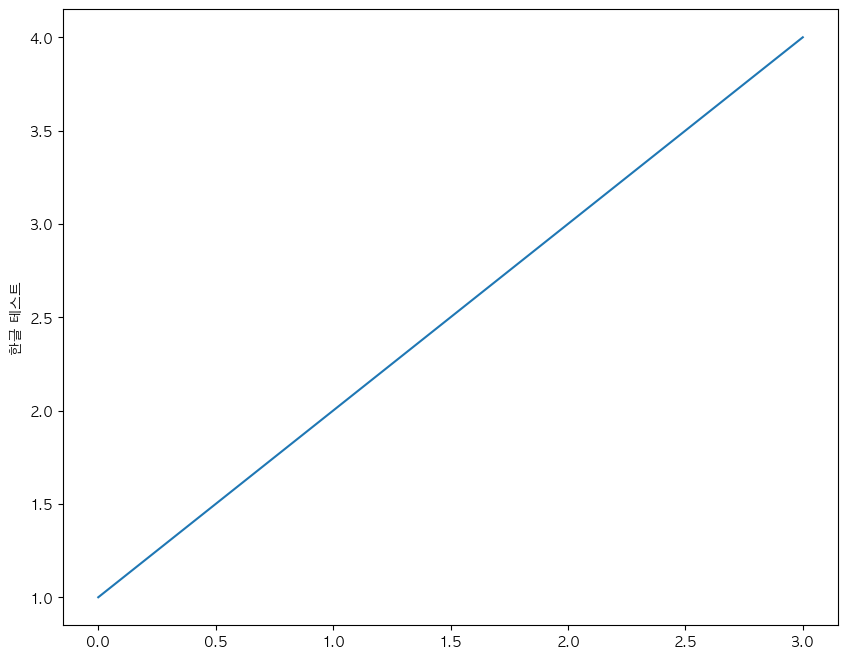

In [2]:
## import library
import trino
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


plt.rcParams['figure.figsize'] = [10, 8]

conn = trino.dbapi.connect(
    host='kakaoent-presto-adhoc.kakaoent.io',
    port=8443,
    user='samuel-ch',
    catalog='hadoop_kent',
    schema='default',                          # 사용할 Database 지정
    http_scheme='https',
    auth=trino.auth.BasicAuthentication("samuel-ch", "melon!Q2w3e"),  # 카카오 LDAP이 아닌 하둡 LDAP 입력
    http_headers={
        'X-Presto-User': 'samuel-ch',
        'X-Presto-Time-Zone': 'Asia/Seoul'
    },
)
cur = conn.cursor()

# Set CSS properties for th elements in dataframe
th_props = [
  ('font-size', '11px'),
  ('text-align', 'center'),
  ('font-weight', 'bold'),
  ('color', '#6d6d6d'),
  ('background-color', '#f7f7f9')
  ]

# Set CSS properties for td elements in dataframe
td_props = [
  ('font-size', '11px')
  ]

# Set table styles
styles = [
  dict(selector="th", props=th_props),
  dict(selector="td", props=td_props)
  ]

cm = sns.light_palette("green", as_cmap=True)

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# AppleGothic 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'

# 테스트 플롯
plt.plot([1, 2, 3, 4])
plt.ylabel('한글 테스트')
plt.show()

In [4]:
(851400*0.1025) + 10267

97535.5

### 1) 정상가 상품 해지율 분포
- 스트리밍 일수 비중 변화에 따른 해지율
- 각 VIP 등급,스트리밍일수비중,이전스트리밍일수비중에 따른 해지율
- 정상가 상품 + 프로모션 기간 아닌 상품들만 집계

In [22]:
st_day_ratio_query = '''
select t1.buy_no_partition as ym
     , t1.vip_grade_nm	
     , t1.st_day_ratio_group
     , case
            when pre_st_day_ratio = 0 or pre_st_day_ratio is null then '0%'
            when pre_st_day_ratio < 11 then '1-10%'
            when pre_st_day_ratio < 21 then '11-20%'
            when pre_st_day_ratio < 31 then '21-30%'
            when pre_st_day_ratio < 41 then '31-40%'
            when pre_st_day_ratio < 51 then '41-50%'
            when pre_st_day_ratio < 61 then '51-60%'
            when pre_st_day_ratio < 71 then '61-70%'
            when pre_st_day_ratio < 81 then '71-80%'
            when pre_st_day_ratio < 91 then '81-90%'
            else '91-100%'
          end as pre_st_day_ratio     
    , count(distinct member_key) as user_cnt
    , round(cast(count(distinct member_key) as double)/cast(tot_user_cnt as double)*100,2) as user_ratio_by_pre_st_day_ratio
	 , count(distinct if(out_yn = 'N',member_key)) as keep_user_cnt        
    , count(distinct if(out_yn = 'Y',member_key)) as out_user_cnt    
	 , round(cast(count(distinct if(out_yn = 'N',member_key)) as double)/cast(count(distinct member_key) as double)*100,2) as keep_user_ratio     
    , round(cast(count(distinct if(out_yn = 'Y',member_key)) as double)/cast(count(distinct member_key) as double)*100,2) as out_user_ratio     
from(
   select buy_no_partition
        , user_mkey as member_key
        , first_buy_no
        , buy_no
        , vip_grade_nm
        , st_day_ratio
        , case
            when st_day_ratio = 0 or st_day_ratio is null then '0%'
            when st_day_ratio < 11 then '1-10%'
            when st_day_ratio < 21 then '11-20%'
            when st_day_ratio < 31 then '21-30%'
            when st_day_ratio < 41 then '31-40%'
            when st_day_ratio < 51 then '41-50%'
            when st_day_ratio < 61 then '51-60%'
            when st_day_ratio < 71 then '61-70%'
            when st_day_ratio < 81 then '71-80%'
            when st_day_ratio < 91 then '81-90%'
            else '91-100%'
          end as st_day_ratio_group
        , out_yn
        , lag(st_day_ratio) over(partition by first_buy_no order by buy_date) as pre_st_day_ratio
        , st_day_ratio - lag(st_day_ratio) over(partition by first_buy_no order by buy_date) as diff_st_day_ratio
   from hadoop_kent.melon_sys_temp_production.samuel_prod_use_stat_dtl_tb
   where remain_offer_cnt = 0
   and normal_price_yn = 1
   and user_trgt_nm = '일반' --체리피커,B리스트 제외
) t1
left join(
   select buy_no_partition        
        , vip_grade_nm
        , case
            when st_day_ratio = 0 or st_day_ratio is null then '0%'
            when st_day_ratio < 11 then '1-10%'
            when st_day_ratio < 21 then '11-20%'
            when st_day_ratio < 31 then '21-30%'
            when st_day_ratio < 41 then '31-40%'
            when st_day_ratio < 51 then '41-50%'
            when st_day_ratio < 61 then '51-60%'
            when st_day_ratio < 71 then '61-70%'
            when st_day_ratio < 81 then '71-80%'
            when st_day_ratio < 91 then '81-90%'
            else '91-100%'
          end as st_day_ratio_group
        , count(distinct user_mkey) as tot_user_cnt
   from hadoop_kent.melon_sys_temp_production.samuel_prod_use_stat_dtl_tb
   where remain_offer_cnt = 0
   and normal_price_yn = 1
   and user_trgt_nm = '일반' --체리피커,B리스트 제외
   group by 1,2,3
) t2 on t1.buy_no_partition = t2.buy_no_partition and t1.vip_grade_nm = t2.vip_grade_nm and t1.st_day_ratio_group = t2.st_day_ratio_group
group by 1,2,3,4,tot_user_cnt
order by 1,2,3,4
'''

cur.execute(st_day_ratio_query)

results = cur.fetchall()
colnames = [part[0] for part in cur.description]

st_day_ratio_df = pd.DataFrame(results, columns=colnames)

cur.cancel()
conn.close()
st_day_ratio_df.head()

,ym,vip_grade_nm,st_day_ratio_group,pre_st_day_ratio,user_cnt,user_ratio_by_pre_st_day_ratio,keep_user_cnt,out_user_cnt,keep_user_ratio,out_user_ratio
0,202301,A_일반,0%,0%,23775,100.0,15704,8126,66.05,34.18
1,202301,A_일반,1-10%,0%,9160,100.0,6850,2311,74.78,25.23
2,202301,A_일반,11-20%,0%,7028,100.0,5442,1586,77.43,22.57
3,202301,A_일반,21-30%,0%,6953,100.0,5486,1468,78.90,21.11
4,202301,A_일반,31-40%,0%,7585,100.0,5942,1643,78.34,21.66


In [29]:
st_day_ratio_df['vip_grade_nm'].unique()

array(['A_일반', 'B_GREEN', 'C_SILVER', 'D_GOLD', 'E_VIP', 'F_MVIP'],
      dtype=object)

vip_grade_nm,A_일반,B_GREEN,C_SILVER,D_GOLD,E_VIP,F_MVIP
st_day_ratio_group,,,,,,
0%,0.923191,0.969108,0.966518,0.969278,0.954424,0.930424
1-10%,0.789717,0.892779,0.916684,0.921502,0.890953,0.882601
11-20%,0.740135,0.828921,0.848640,0.859692,0.837061,0.811803
21-30%,0.681668,0.750998,0.772254,0.787586,0.768660,0.746459
31-40%,0.572231,0.686239,0.693255,0.689638,0.704428,0.690151
41-50%,0.477420,0.574196,0.580659,0.588599,0.636606,0.597242
51-60%,0.268501,0.441827,0.448670,0.441202,0.459869,0.458488
61-70%,-0.070203,0.178485,0.144168,0.047069,0.101294,0.094332
71-80%,-0.286516,-0.208054,-0.289228,-0.329763,-0.264361,-0.349057


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


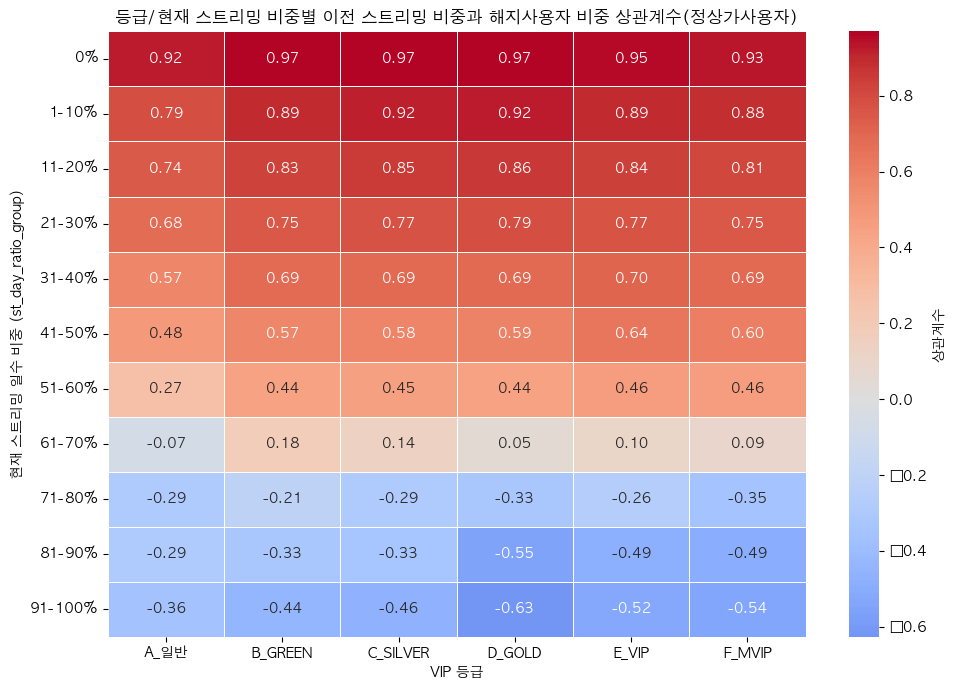

In [27]:
pre_map = {'0%':0, '1-10%':5, '11-20%':15, '21-30%':25, '31-40%':35, '41-50%':45, '51-60%':55, '61-70%':65, '71-80%':75, '81-90%':85, '91-100%':95}
df = st_day_ratio_df.copy()
df = df[df['pre_st_day_ratio'].notnull() & df['out_user_ratio'].notnull()]
df['pre_st_day_ratio_num'] = df['pre_st_day_ratio'].map(pre_map)

result = []
for grade in df['vip_grade_nm'].unique():
    for group in df['st_day_ratio_group'].unique():
        sub = df[(df['vip_grade_nm']==grade) & (df['st_day_ratio_group']==group)]
        if len(sub) > 1:  # 상관계수 계산 최소 2개
            corr = sub[['pre_st_day_ratio_num', 'out_user_ratio']].corr().iloc[0,1]
            result.append({'vip_grade_nm': grade, 'st_day_ratio_group': group, 'corr': corr})

corr_df = pd.DataFrame(result)

# corr_df를 pivot 형태로 변환 (x축: vip_grade_nm, y축: st_day_ratio_group)
pivot_corr = corr_df.pivot(index='st_day_ratio_group', columns='vip_grade_nm', values='corr')
display(pivot_corr)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.heatmap(
    pivot_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={'label': '상관계수'}
)
plt.title("등급/현재 스트리밍 비중별 이전 스트리밍 비중과 해지사용자 비중 상관계수(정상가사용자)")
plt.xlabel("VIP 등급")
plt.ylabel("현재 스트리밍 일수 비중 (st_day_ratio_group)")
plt.tight_layout()
plt.show()


In [128]:
st_day_ratio_df['st_day_ratio_group'].unique()

array(['0%', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '51-60%',
       '61-70%', '71-80%', '81-90%', '91-100%'], dtype=object)

In [129]:
# 등급, 현재 스트리밍 활성도, 이전 스트리밍 활성도별 해지사용자 비율 평균 pivot table 생성 (소수 둘째자리 반올림)
df = st_day_ratio_df.copy()
df['ym'] = df['ym'].astype(str)
df = df[(df['ym'] >= '202401') & (df['ym'] <= '202504')].copy()

pivot = pd.pivot_table(
    df,
    values='out_user_ratio',
    index=['vip_grade_nm', 'st_day_ratio_group'],
    columns='pre_st_day_ratio',
    aggfunc='mean'
)

pivot = pivot[['0%', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '51-60%','61-70%', '71-80%', '81-90%', '91-100%']]  # 보기 좋게 정렬
pivot = pivot.round(2)  # 소수 둘째자리 반올림
pivot

pre_st_day_ratio                    0%  1-10%  11-20%  21-30%  31-40%  41-50%  \
vip_grade_nm st_day_ratio_group                                                 
A_일반         0%                  36.52  23.81   29.79   34.95   42.10   47.53   
             1-10%               27.63  16.92   17.86   19.84   22.06   24.09   
             11-20%              26.33  15.46   14.87   15.50   17.03   19.97   
             21-30%              24.74  13.56   13.22   14.13   14.80   15.07   
             31-40%              24.24  12.57   13.45   14.30   14.44   14.24   
...                                ...    ...     ...     ...     ...     ...   
F_MVIP       51-60%               3.81   2.57    2.50    2.23    2.36    2.25   
             61-70%               4.18   2.81    2.66    2.44    2.29    2.16   
             71-80%               4.52   3.10    2.88    2.63    2.39    2.33   
             81-90%               4.59   3.12    2.90    2.41    2.58    2.53   
             91-100%              3.92   4.54    3.28    3.57    3.13    2.84   

pre_st_day_ratio                 51-60%  61-70%  71-80%  81-90%  91-100%  
vip_grade_nm st_day_ratio_group                                           
A_일반         0%                   52.64   57.61   66.81   72.40    83.97  
             1-10%                31.15   35.39   42.88   48.47    56.26  
             11-20%               21.56   27.39   33.14   42.37    57.61  
             21-30%               17.48   19.93   27.35   34.94    52.12  
             31-40%               15.05   17.64   22.12   29.33    43.90  
...                                 ...     ...     ...     ...      ...  
F_MVIP       51-60%                2.26    2.45    2.94    4.09     8.76  
             61-70%                2.23    2.18    2.36    2.88     4.99  
             71-80%                2.25    2.16    2.11    2.34     3.09  
             81-90%                2.39    2.22    2.09    2.21     2.44  
             91-100%               2.49    2.31    2.20    2.16     2.14  

[66 rows x 11 columns]

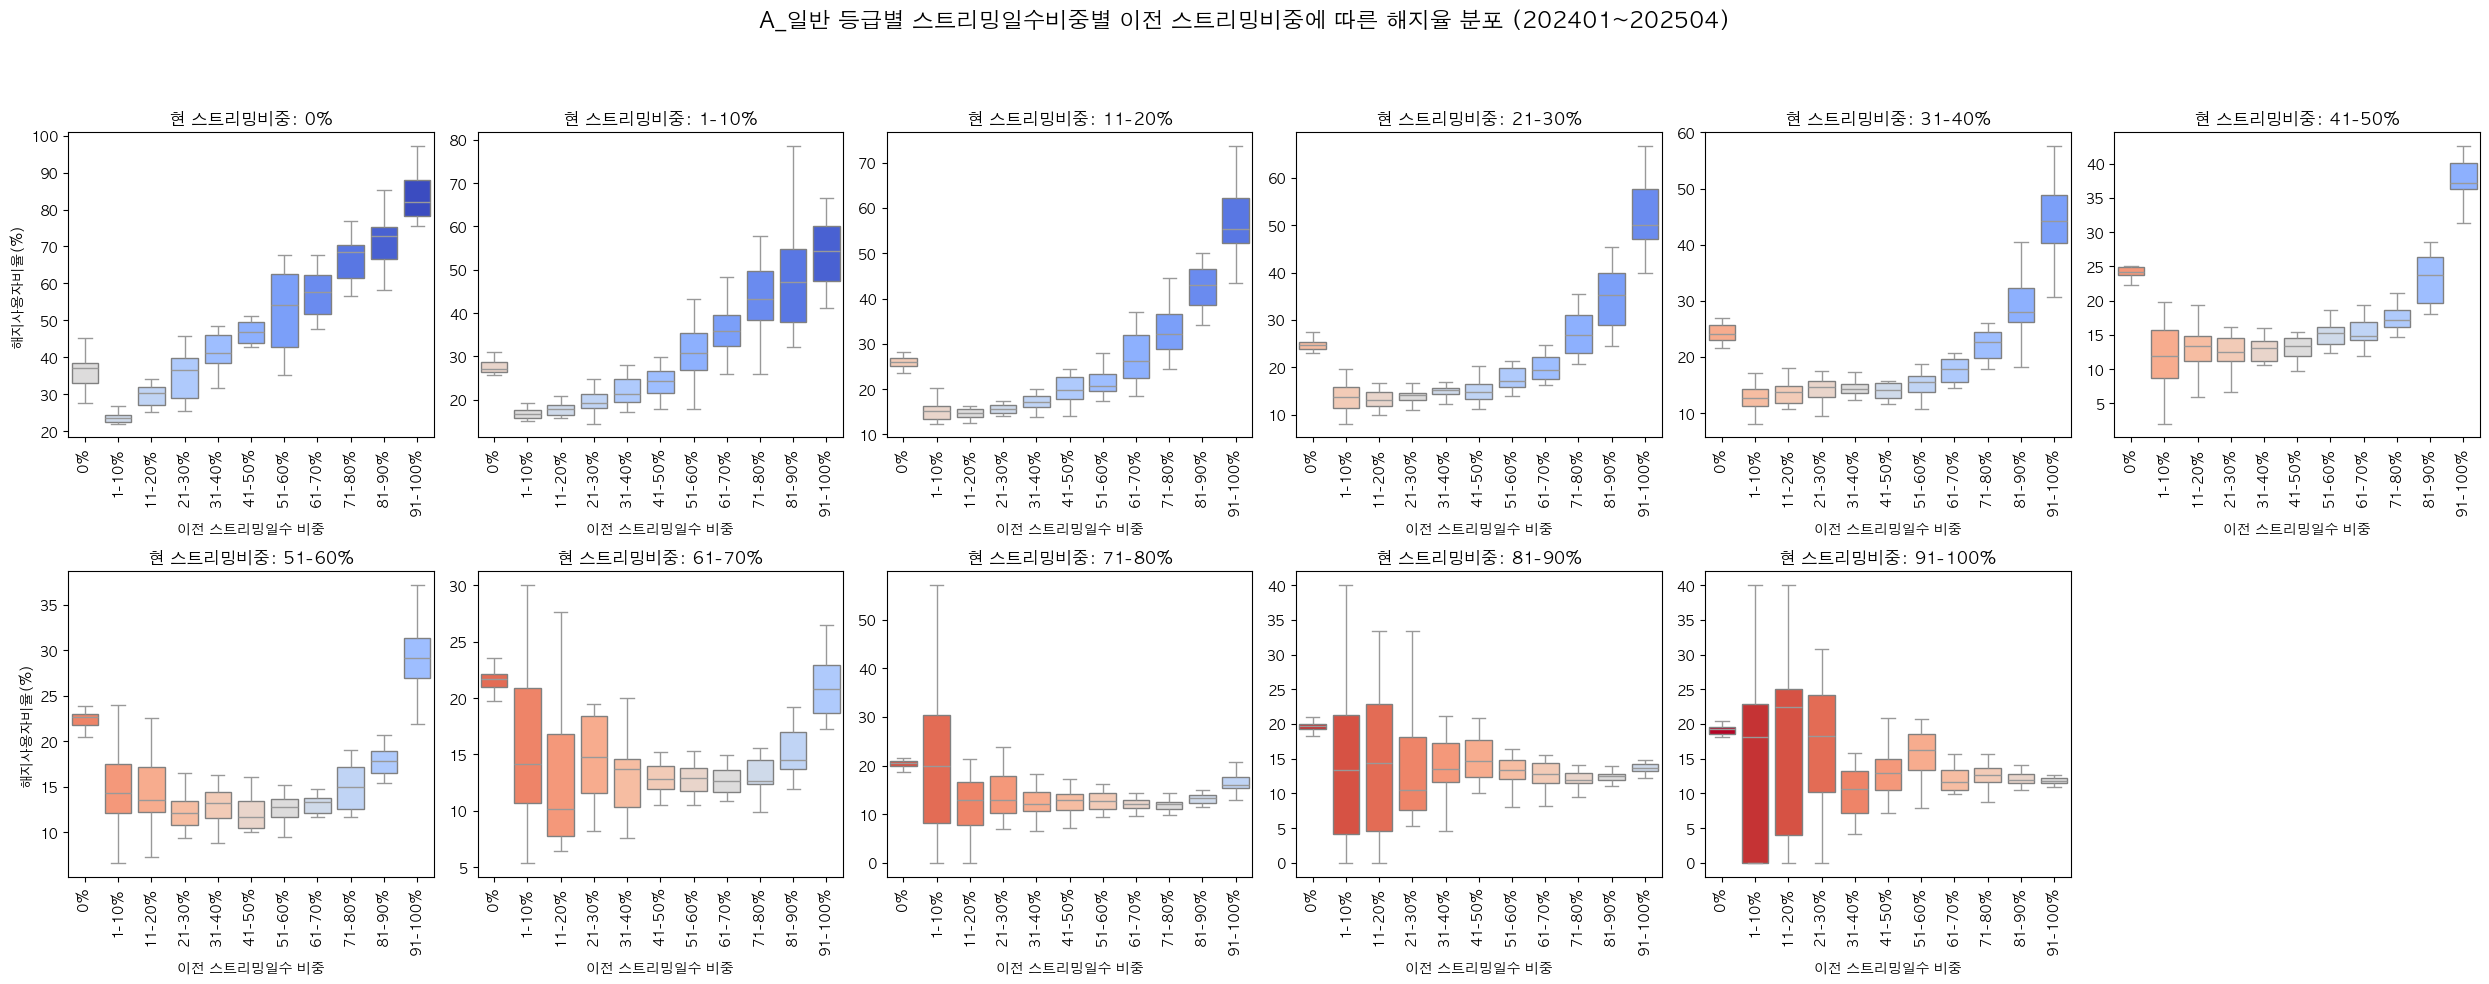

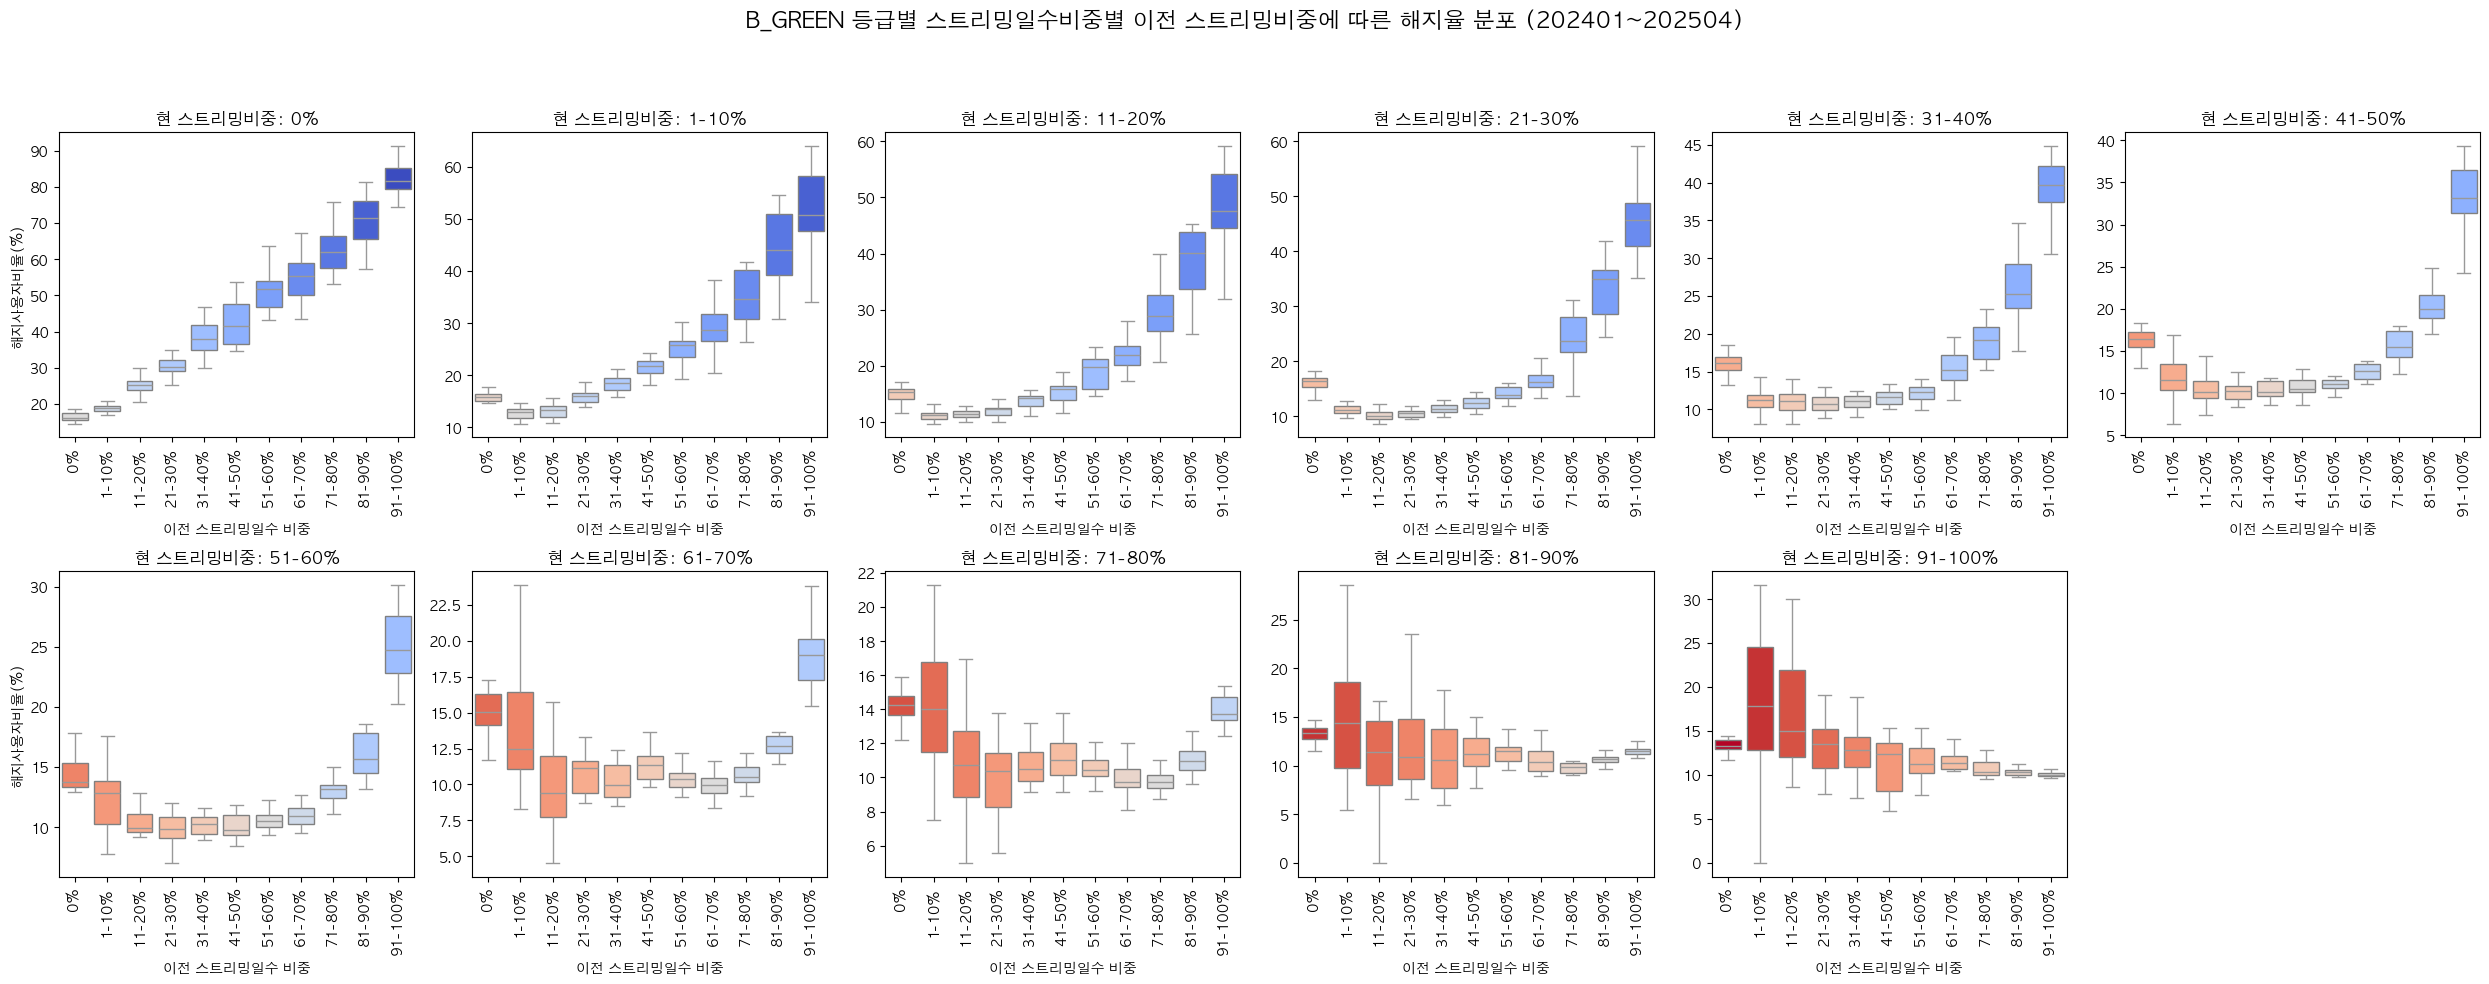

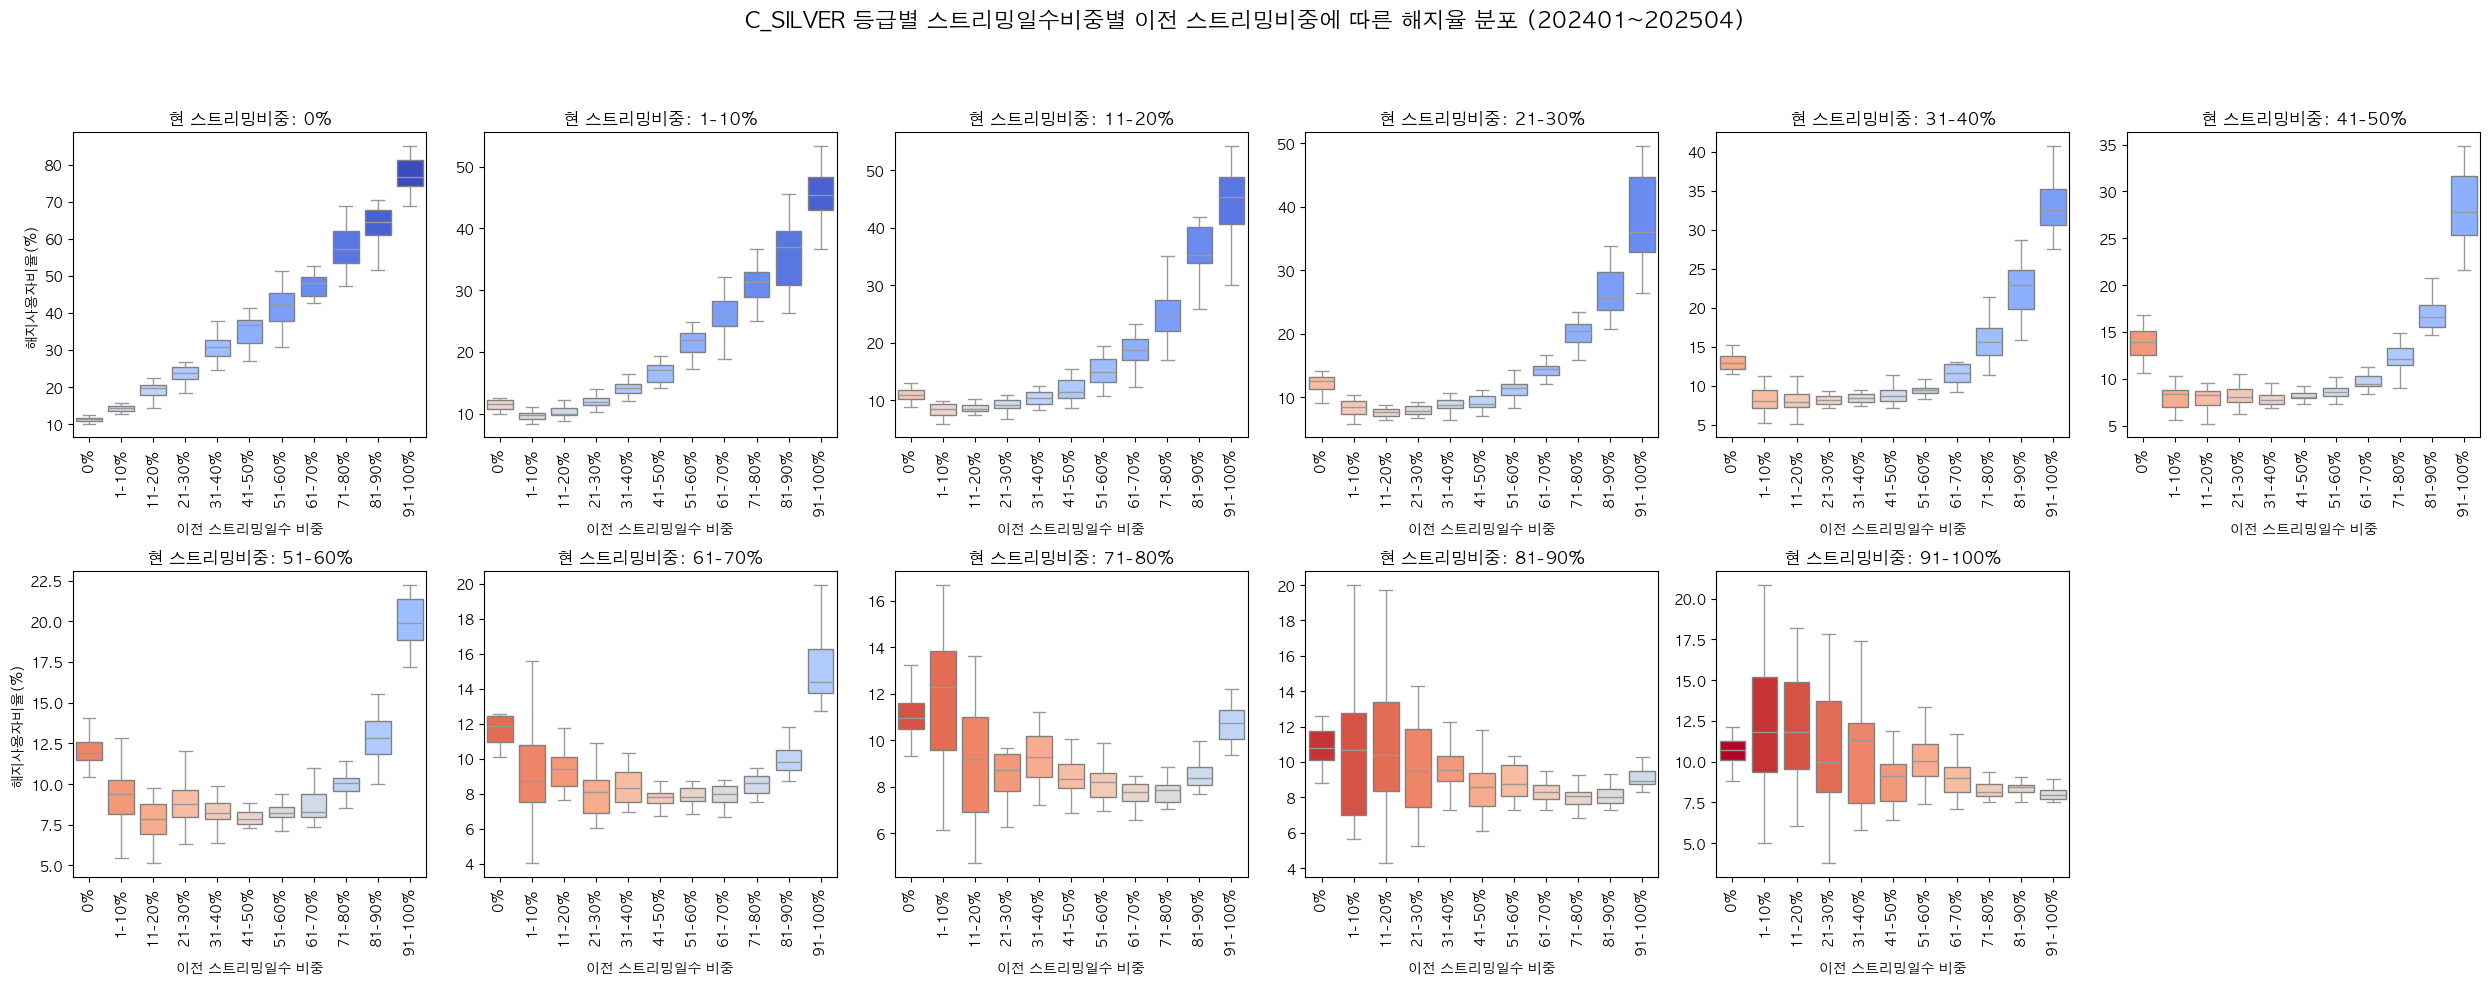

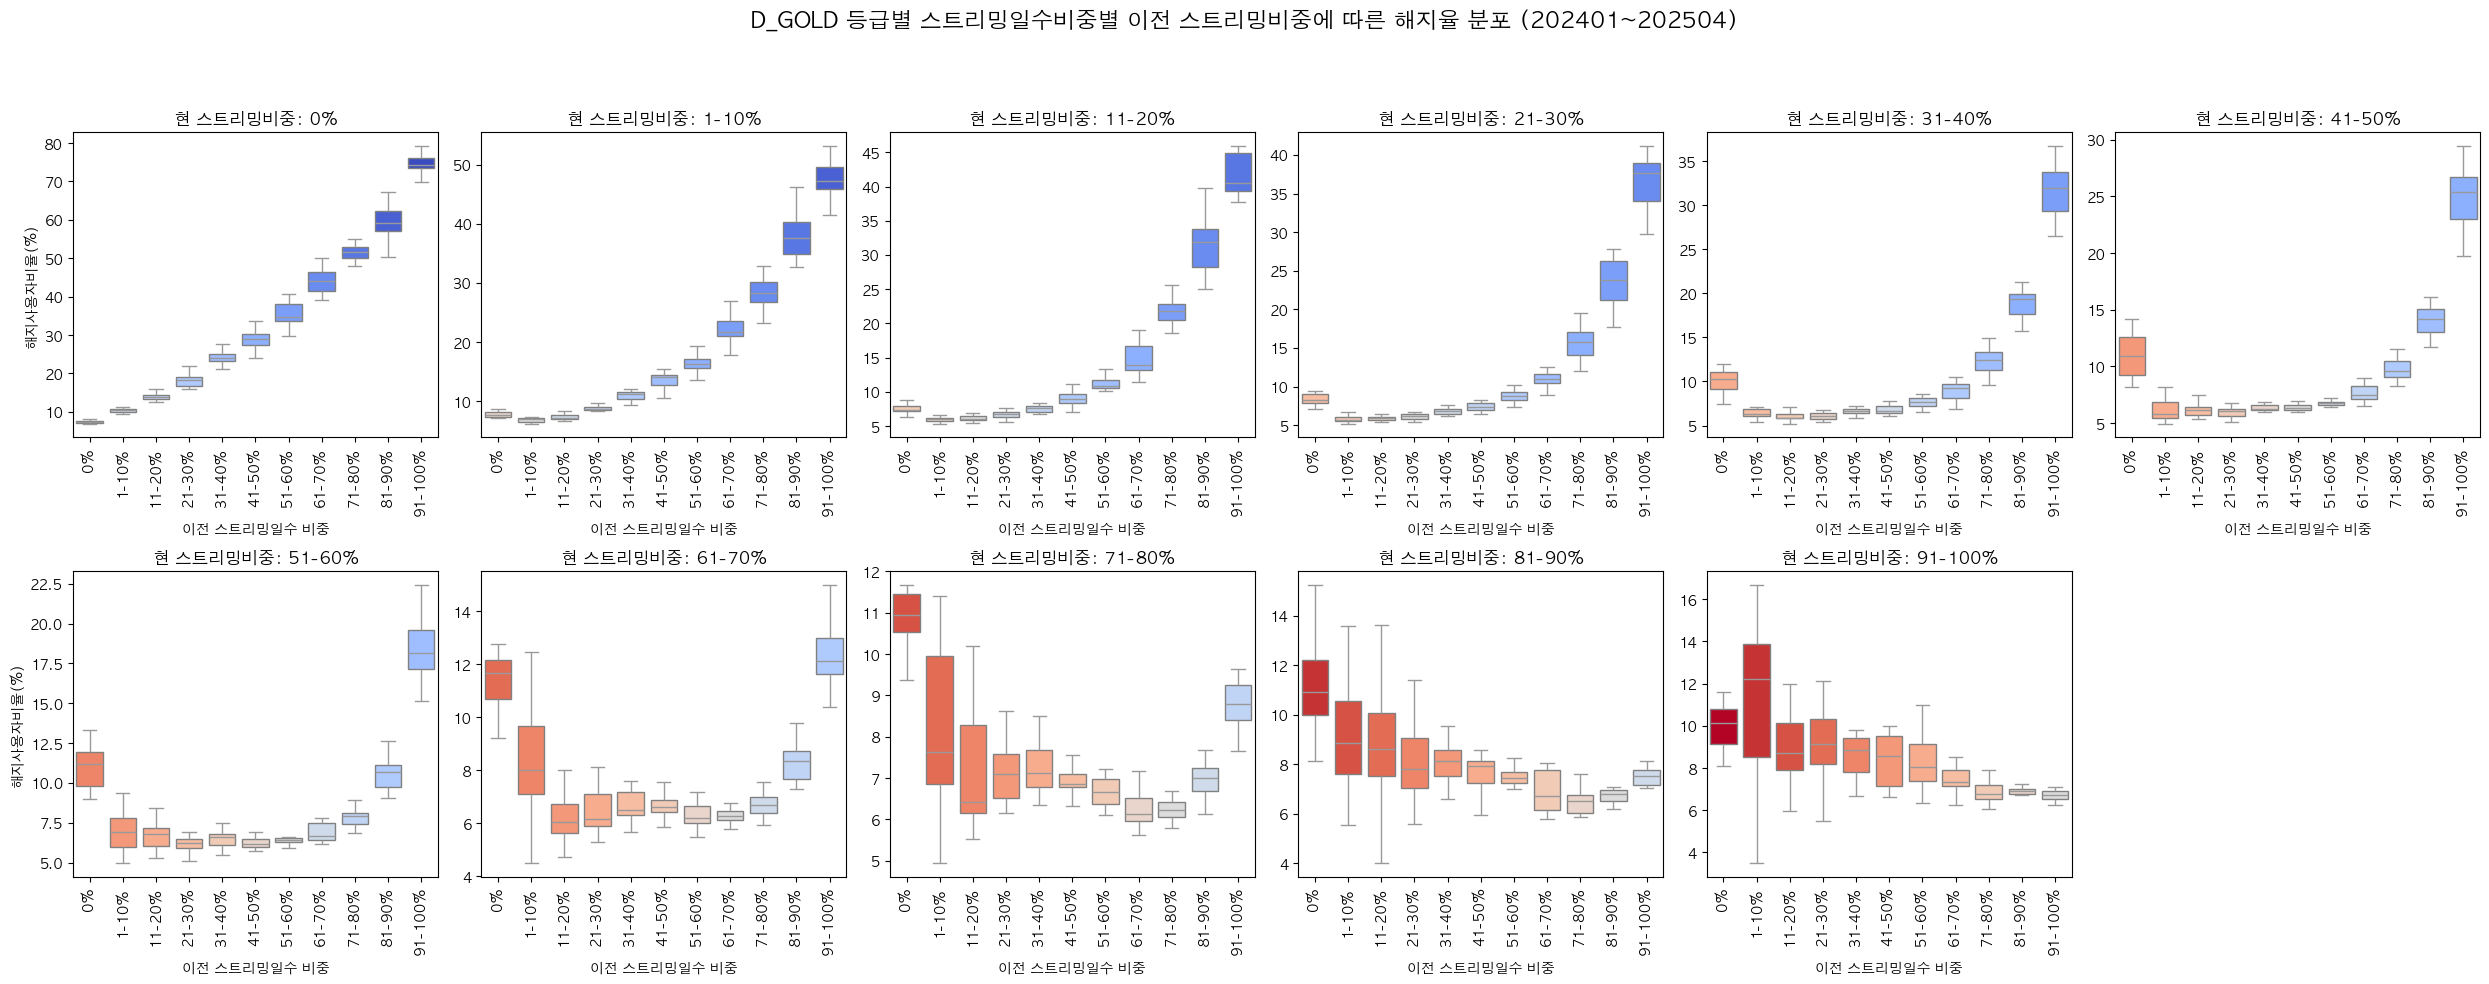

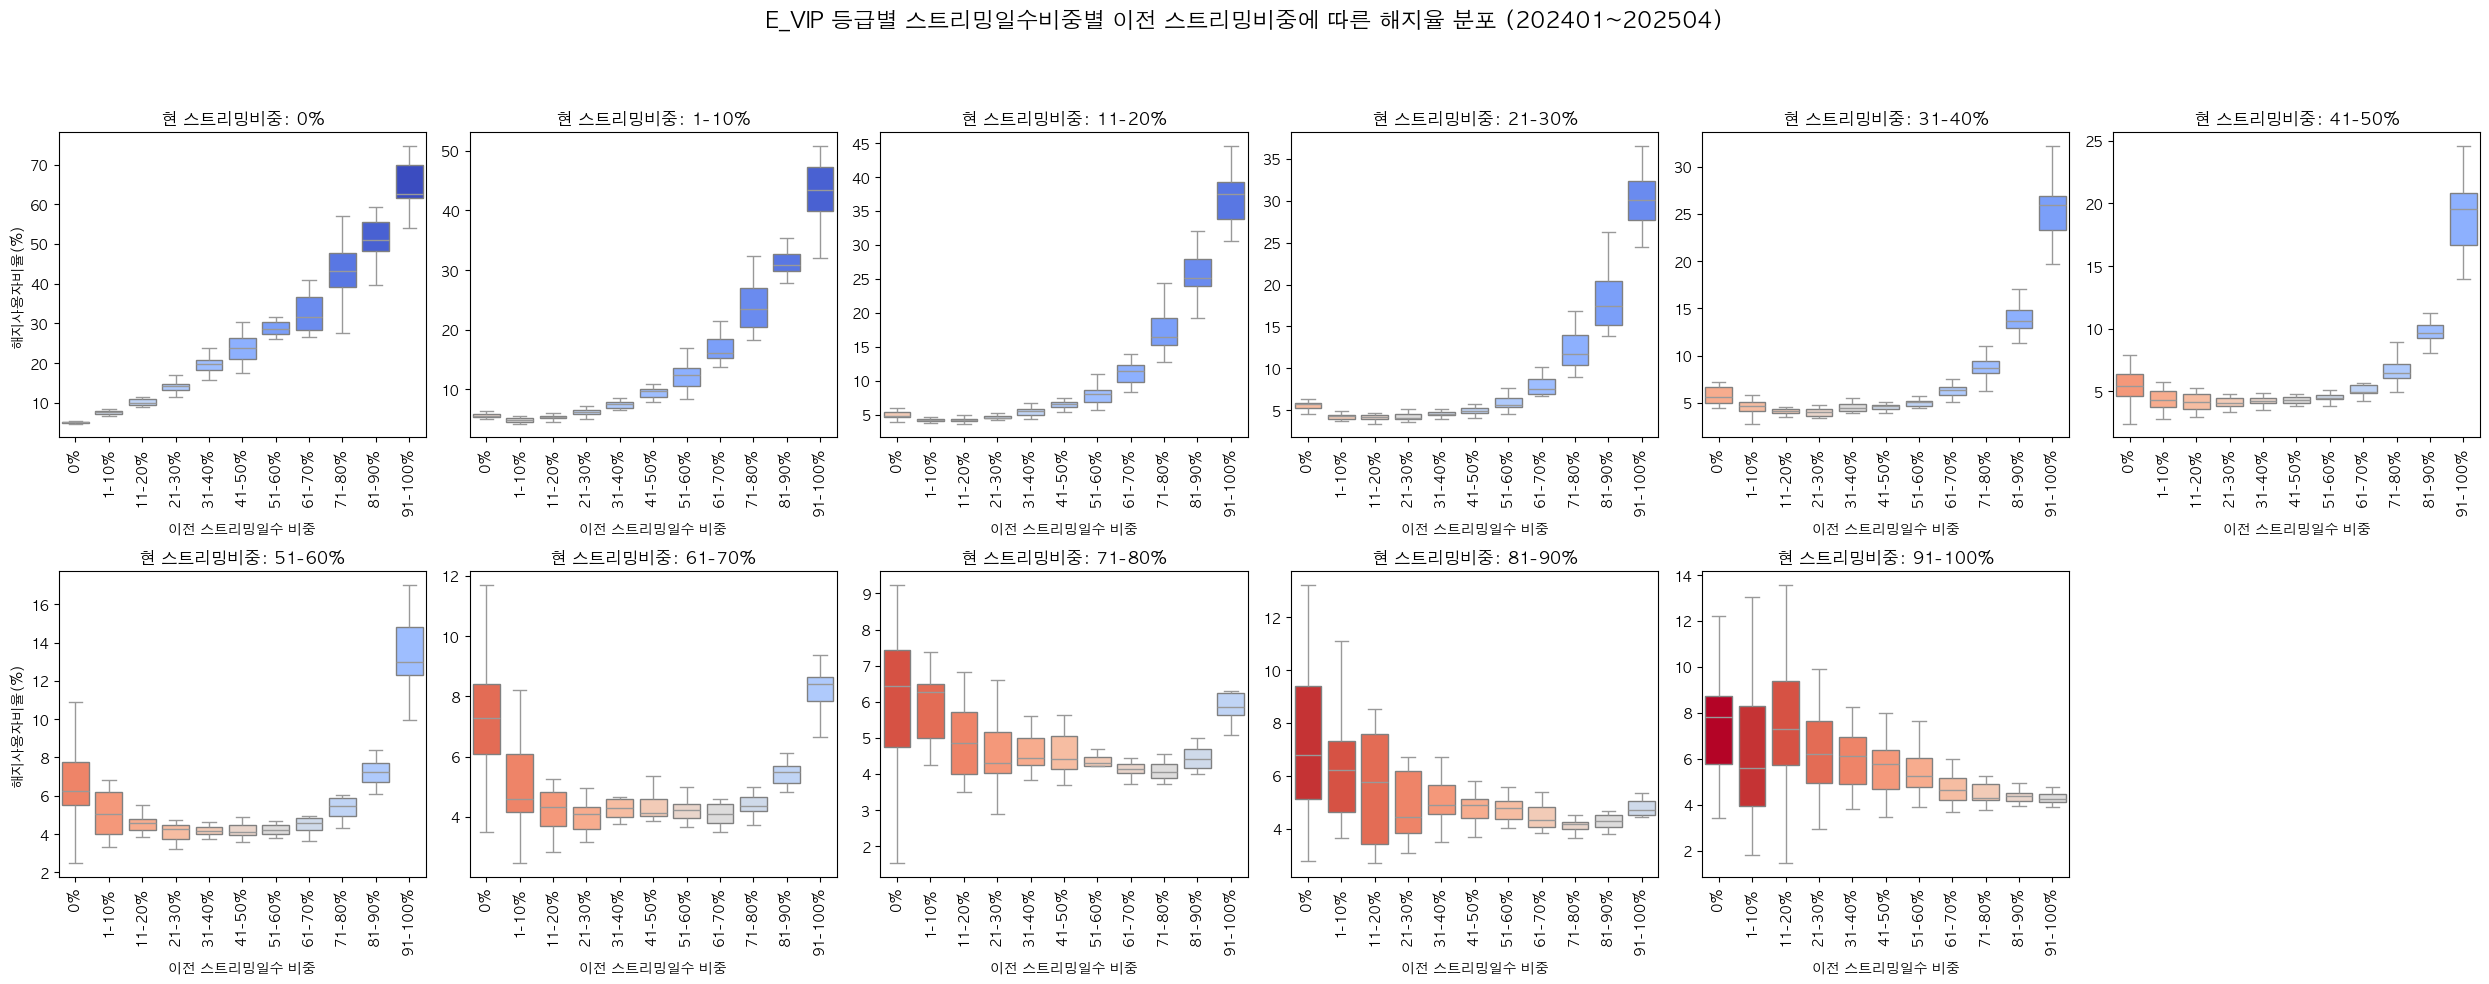

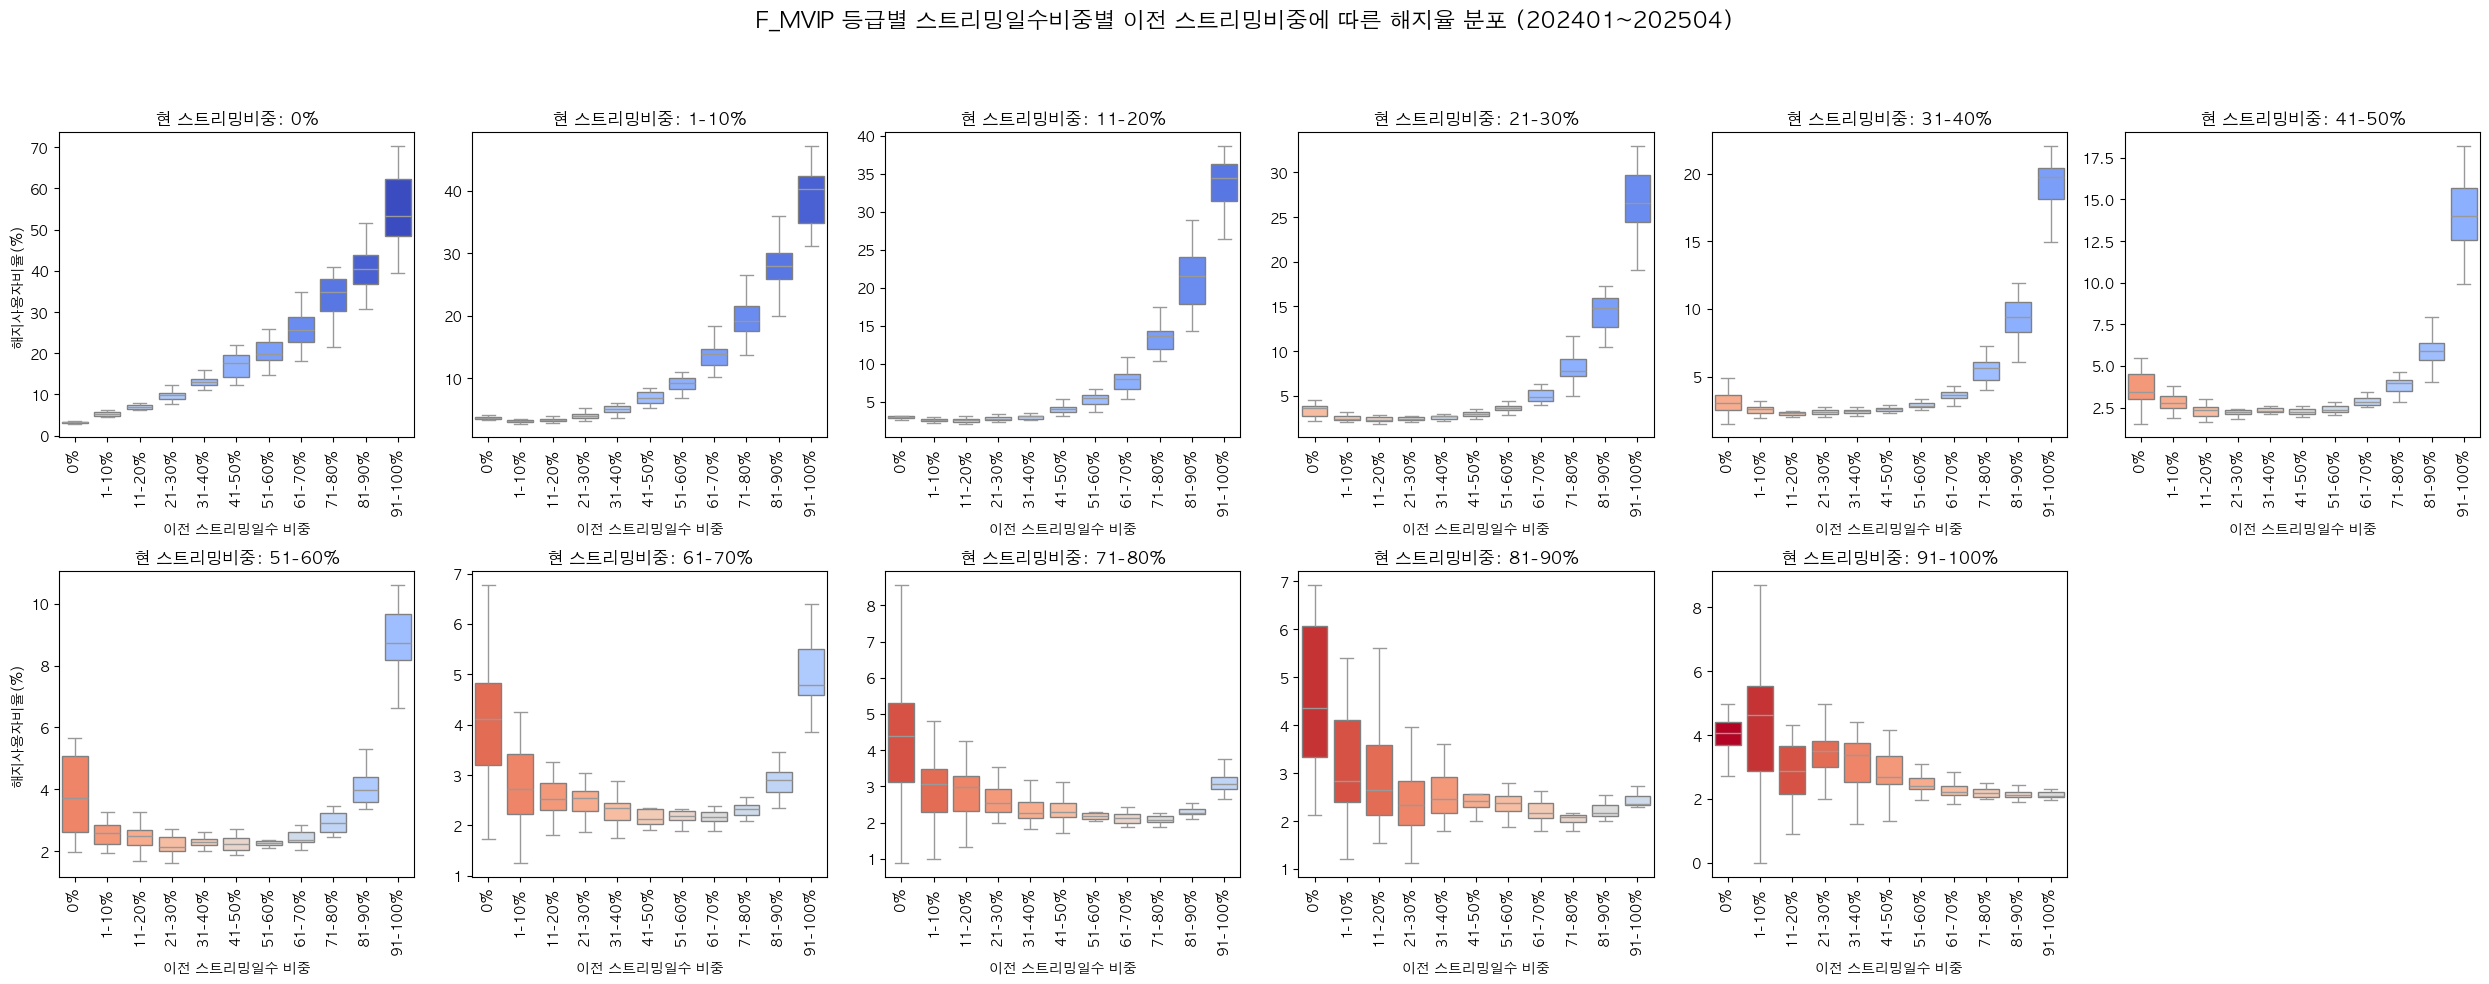

In [143]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. 데이터 전처리
df = st_day_ratio_df.copy()
df['ym'] = df['ym'].astype(str)
df = df[(df['ym'] >= '202401') & (df['ym'] <= '202504')].copy()

pre_order = ['0%', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '51-60%','61-70%', '71-80%', '81-90%', '91-100%']
cur_order = ['0%', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '51-60%','61-70%', '71-80%', '81-90%', '91-100%']
df['pre_st_day_ratio'] = pd.Categorical(df['pre_st_day_ratio'], categories=pre_order, ordered=True)
df['st_day_ratio_group'] = pd.Categorical(df['st_day_ratio_group'], categories=cur_order, ordered=True)

# 2. gradation 색상 함수 (YlGnBu_r: 파랑~노랑, RdPu: 빨강~보라 등 선택 가능)
def get_gradation_color(pre_group, cur_group, cmap_name="coolwarm"):
    group_map = {
        '0%': 0, '1-10%': 1, '11-20%': 2, '21-30%': 3, '31-40%': 4,
        '41-50%': 5, '51-60%': 6, '61-70%': 7, '71-80%': 8, '81-90%': 9, '91-100%': 10
    }
    pre_num = group_map.get(pre_group, np.nan)
    cur_num = group_map.get(cur_group, np.nan)
    if np.isnan(pre_num) or np.isnan(cur_num):
        return '#cccccc'
    diff = cur_num - pre_num  # -10 ~ +10
    norm_val = (diff + 10) / 20  # -10~+10 → 0~1
    cmap = matplotlib.colormaps[cmap_name]
    rgba = cmap(norm_val)
    return matplotlib.colors.to_hex(rgba, keep_alpha=False)

# 3. boxplot 그리기
for vip in df['vip_grade_nm'].unique():
    n_cols = int(np.ceil(len(cur_order) / 2))
    fig, axes = plt.subplots(2, n_cols, figsize=(25, 10), sharey=False)
    fig.suptitle(f"{vip} 등급별 스트리밍일수비중별 이전 스트리밍비중에 따른 해지율 분포 (202401~202504)", fontsize=16)
    axes = axes.flatten()  # 1차원 배열로 변환

    for idx, curr in enumerate(cur_order):
        ax = axes[idx]
        sub = df[(df['vip_grade_nm'] == vip) & (df['st_day_ratio_group'] == curr)]
        box = sns.boxplot(
            x='pre_st_day_ratio', y='out_user_ratio', data=sub,
            ax=ax, showfliers=False, linewidth=1, color='white'
        )
        # gradation 색상 적용
        for patch_idx, patch in enumerate(ax.patches):
            if patch_idx < len(pre_order):
                color = get_gradation_color(pre_order[patch_idx], curr, cmap_name="coolwarm")
                patch.set_facecolor(color)
                patch.set_edgecolor('grey')
        ax.set_title(f"현 스트리밍비중: {curr}")
        ax.set_xlabel("이전 스트리밍일수 비중")
        # x축 라벨 180도 회전 (FixedLocator 사용)
        ax.tick_params(axis='x', labelrotation=90)
        if idx % n_cols == 0:
            ax.set_ylabel("해지사용자비율(%)")
        else:
            ax.set_ylabel("")
    # 남는 subplot 숨기기
    for j in range(len(cur_order), len(axes)):
        axes[j].axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

### 2) 정상가 전환예정 상품 해지율 분포
- 스트리밍 일수 비중 변화에 따른 해지율
- 각 VIP 등급,스트리밍일수비중,이전스트리밍일수비중에 따른 해지율
- 프로모션 종료 예정 상품 기준

In [18]:
promo_end_user_query = '''
select t1.buy_no_partition as ym
     , t1.vip_grade_nm	
     , t1.st_day_ratio_group
     , case
            when pre_st_day_ratio = 0 or pre_st_day_ratio is null then '0%'
            when pre_st_day_ratio < 11 then '1-10%'
            when pre_st_day_ratio < 21 then '11-20%'
            when pre_st_day_ratio < 31 then '21-30%'
            when pre_st_day_ratio < 41 then '31-40%'
            when pre_st_day_ratio < 51 then '41-50%'
            when pre_st_day_ratio < 61 then '51-60%'
            when pre_st_day_ratio < 71 then '61-70%'
            when pre_st_day_ratio < 81 then '71-80%'
            when pre_st_day_ratio < 91 then '81-90%'
            else '91-100%'
          end as pre_st_day_ratio     
    , count(distinct member_key) as user_cnt
    , round(cast(count(distinct member_key) as double)/cast(tot_user_cnt as double)*100,2) as user_ratio_by_pre_st_day_ratio
	 , count(distinct if(out_yn = 'N',member_key)) as keep_user_cnt        
    , count(distinct if(out_yn = 'Y',member_key)) as out_user_cnt    
	 , round(cast(count(distinct if(out_yn = 'N',member_key)) as double)/cast(count(distinct member_key) as double)*100,2) as keep_user_ratio     
    , round(cast(count(distinct if(out_yn = 'Y',member_key)) as double)/cast(count(distinct member_key) as double)*100,2) as out_user_ratio     
from(
   select buy_no_partition
        , user_mkey as member_key
        , first_buy_no
        , buy_no
        , vip_grade_nm
        , st_day_ratio
        , case
            when st_day_ratio = 0 or st_day_ratio is null then '0%'
            when st_day_ratio < 11 then '1-10%'
            when st_day_ratio < 21 then '11-20%'
            when st_day_ratio < 31 then '21-30%'
            when st_day_ratio < 41 then '31-40%'
            when st_day_ratio < 51 then '41-50%'
            when st_day_ratio < 61 then '51-60%'
            when st_day_ratio < 71 then '61-70%'
            when st_day_ratio < 81 then '71-80%'
            when st_day_ratio < 91 then '81-90%'
            else '91-100%'
          end as st_day_ratio_group
        , out_yn
        , lag(st_day_ratio) over(partition by first_buy_no order by buy_date) as pre_st_day_ratio
        , st_day_ratio - lag(st_day_ratio) over(partition by first_buy_no order by buy_date) as diff_st_day_ratio
   from hadoop_kent.melon_sys_temp_production.samuel_prod_use_stat_dtl_tb
   where remain_offer_cnt = 0
   and normal_price_yn = 0
   and user_trgt_nm = '일반' --체리피커,B리스트 제외
) t1
left join(
   select buy_no_partition        
        , vip_grade_nm
        , case
            when st_day_ratio = 0 or st_day_ratio is null then '0%'
            when st_day_ratio < 11 then '1-10%'
            when st_day_ratio < 21 then '11-20%'
            when st_day_ratio < 31 then '21-30%'
            when st_day_ratio < 41 then '31-40%'
            when st_day_ratio < 51 then '41-50%'
            when st_day_ratio < 61 then '51-60%'
            when st_day_ratio < 71 then '61-70%'
            when st_day_ratio < 81 then '71-80%'
            when st_day_ratio < 91 then '81-90%'
            else '91-100%'
          end as st_day_ratio_group
        , count(distinct user_mkey) as tot_user_cnt
   from hadoop_kent.melon_sys_temp_production.samuel_prod_use_stat_dtl_tb
   where remain_offer_cnt = 0
   and normal_price_yn = 0
   and user_trgt_nm = '일반' --체리피커,B리스트 제외
   group by 1,2,3
) t2 on t1.buy_no_partition = t2.buy_no_partition and t1.vip_grade_nm = t2.vip_grade_nm and t1.st_day_ratio_group = t2.st_day_ratio_group
group by 1,2,3,4,tot_user_cnt
order by 1,2,3,4
'''

cur.execute(promo_end_user_query)

results = cur.fetchall()
colnames = [part[0] for part in cur.description]

promo_end_user_df = pd.DataFrame(results, columns=colnames)

cur.cancel()
conn.close()
promo_end_user_df.head()

,ym,vip_grade_nm,st_day_ratio_group,pre_st_day_ratio,user_cnt,user_ratio_by_pre_st_day_ratio,keep_user_cnt,out_user_cnt,keep_user_ratio,out_user_ratio
0,202301,A_일반,0%,0%,10400,100.0,6548,3862,62.96,37.13
1,202301,A_일반,1-10%,0%,5606,100.0,3427,2179,61.13,38.87
2,202301,A_일반,11-20%,0%,4455,100.0,2848,1607,63.93,36.07
3,202301,A_일반,21-30%,0%,4406,100.0,2886,1520,65.50,34.50
4,202301,A_일반,31-40%,0%,4650,100.0,3085,1565,66.34,33.66


vip_grade_nm,A_일반,B_GREEN,C_SILVER,D_GOLD,E_VIP,F_MVIP
st_day_ratio_group,,,,,,
0%,0.608847,0.507436,0.525216,0.602288,0.489691,0.373643
1-10%,0.221857,0.408430,0.454966,0.513416,0.315854,0.318754
11-20%,0.181870,0.341982,0.352417,0.472359,0.449696,0.286775
21-30%,0.225305,0.319025,0.313008,0.552699,0.395239,0.352393
31-40%,0.187616,0.301413,0.349051,0.463563,0.320475,0.283970
41-50%,0.009194,0.215302,0.175595,0.320811,0.349670,0.227964
51-60%,-0.089325,0.176967,0.176343,0.104069,0.196158,0.051849
61-70%,-0.107387,0.015203,0.054429,0.020398,-0.040273,-0.146292
71-80%,-0.244834,-0.211845,-0.091955,-0.108869,-0.113638,-0.125431


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


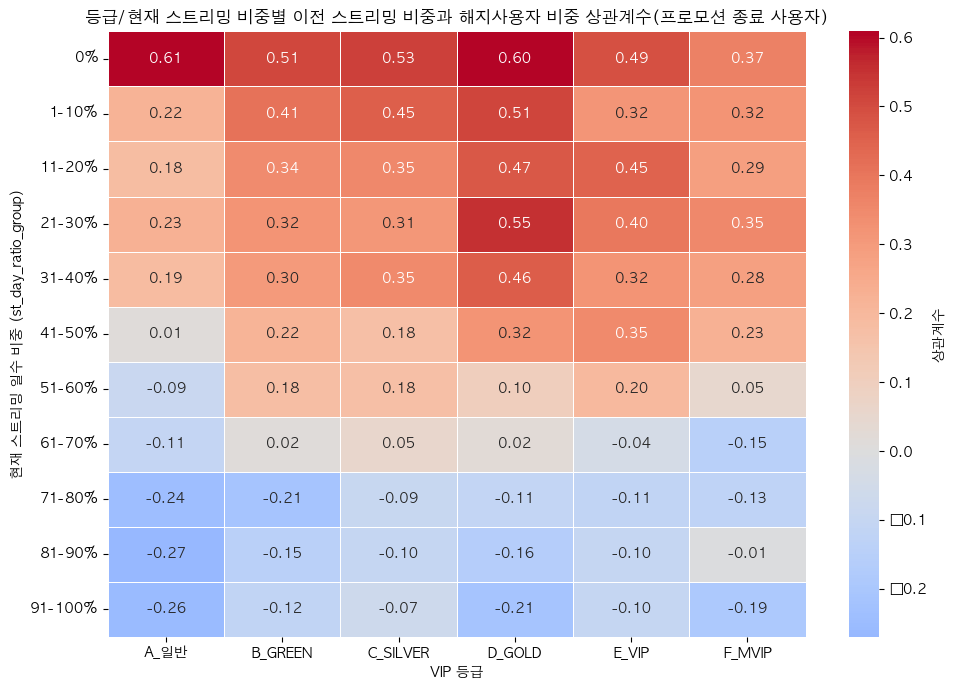

In [26]:
pre_map = {'0%':0, '1-10%':5, '11-20%':15, '21-30%':25, '31-40%':35, '41-50%':45, '51-60%':55, '61-70%':65, '71-80%':75, '81-90%':85, '91-100%':95}
df = promo_end_user_df.copy()
df = df[df['pre_st_day_ratio'].notnull() & df['out_user_ratio'].notnull()]
df['pre_st_day_ratio_num'] = df['pre_st_day_ratio'].map(pre_map)

result = []
for grade in df['vip_grade_nm'].unique():
    for group in df['st_day_ratio_group'].unique():
        sub = df[(df['vip_grade_nm']==grade) & (df['st_day_ratio_group']==group)]
        if len(sub) > 1:  # 상관계수 계산 최소 2개
            corr = sub[['pre_st_day_ratio_num', 'out_user_ratio']].corr().iloc[0,1]
            result.append({'vip_grade_nm': grade, 'st_day_ratio_group': group, 'corr': corr})

corr_df = pd.DataFrame(result)

# corr_df를 pivot 형태로 변환 (x축: vip_grade_nm, y축: st_day_ratio_group)
pivot_corr = corr_df.pivot(index='st_day_ratio_group', columns='vip_grade_nm', values='corr')
display(pivot_corr)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.heatmap(
    pivot_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={'label': '상관계수'}
)
plt.title("등급/현재 스트리밍 비중별 이전 스트리밍 비중과 해지사용자 비중 상관계수(프로모션 종료 사용자)")
plt.xlabel("VIP 등급")
plt.ylabel("현재 스트리밍 일수 비중 (st_day_ratio_group)")
plt.tight_layout()
plt.show()


In [145]:
# 등급, 현재 스트리밍 활성도, 이전 스트리밍 활성도별 해지사용자 비율 평균 pivot table 생성 (소수 둘째자리 반올림)
df = promo_end_user_df.copy()
df['ym'] = df['ym'].astype(str)
df = df[(df['ym'] >= '202401') & (df['ym'] <= '202504')].copy()

pivot = pd.pivot_table(
    df,
    values='out_user_ratio',
    index=['vip_grade_nm', 'st_day_ratio_group'],
    columns='pre_st_day_ratio',
    aggfunc='mean'
)

pivot = pivot[['0%', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '51-60%','61-70%', '71-80%', '81-90%', '91-100%']]  # 보기 좋게 정렬
pivot = pivot.round(2)  # 소수 둘째자리 반올림
pivot

pre_st_day_ratio                    0%  1-10%  11-20%  21-30%  31-40%  41-50%  \
vip_grade_nm st_day_ratio_group                                                 
A_일반         0%                  49.51  21.70   34.97   34.17   50.45   55.55   
             1-10%               54.34  11.18   14.21   13.53   17.80   24.57   
             11-20%              50.86  12.23   11.84   14.36   12.76   18.61   
             21-30%              48.96  12.50   12.64   10.43   12.98   13.70   
             31-40%              48.20   3.49   11.92   15.11   12.91   17.14   
...                                ...    ...     ...     ...     ...     ...   
F_MVIP       51-60%               7.89   5.75    8.96    6.35    4.92    3.89   
             61-70%               7.49  11.99   11.68    5.72    6.73    6.37   
             71-80%               7.07   6.60    8.86    7.96    3.00    4.94   
             81-90%               6.85   2.50    6.52    4.75    9.01    7.44   
             91-100%              6.07  15.42    8.18   10.95    8.65    8.56   

pre_st_day_ratio                 51-60%  61-70%  71-80%  81-90%  91-100%  
vip_grade_nm st_day_ratio_group                                           
A_일반         0%                   67.08   69.51   57.22   70.52    82.89  
             1-10%                26.90   28.56   27.16   53.22    47.41  
             11-20%               23.79   26.53   23.35   23.72    42.95  
             21-30%               16.12   18.19   27.21   39.29    40.62  
             31-40%               14.45   16.70   29.95   19.54    50.06  
...                                 ...     ...     ...     ...      ...  
F_MVIP       51-60%                4.02    4.37    5.03    8.71    11.28  
             61-70%                3.93    3.38    4.88    5.48    10.17  
             71-80%                4.69    4.01    4.14    4.26     6.42  
             81-90%                6.09    5.61    4.36    3.80     4.56  
             91-100%               6.94    7.95    5.90    3.60     3.57  

[66 rows x 11 columns]

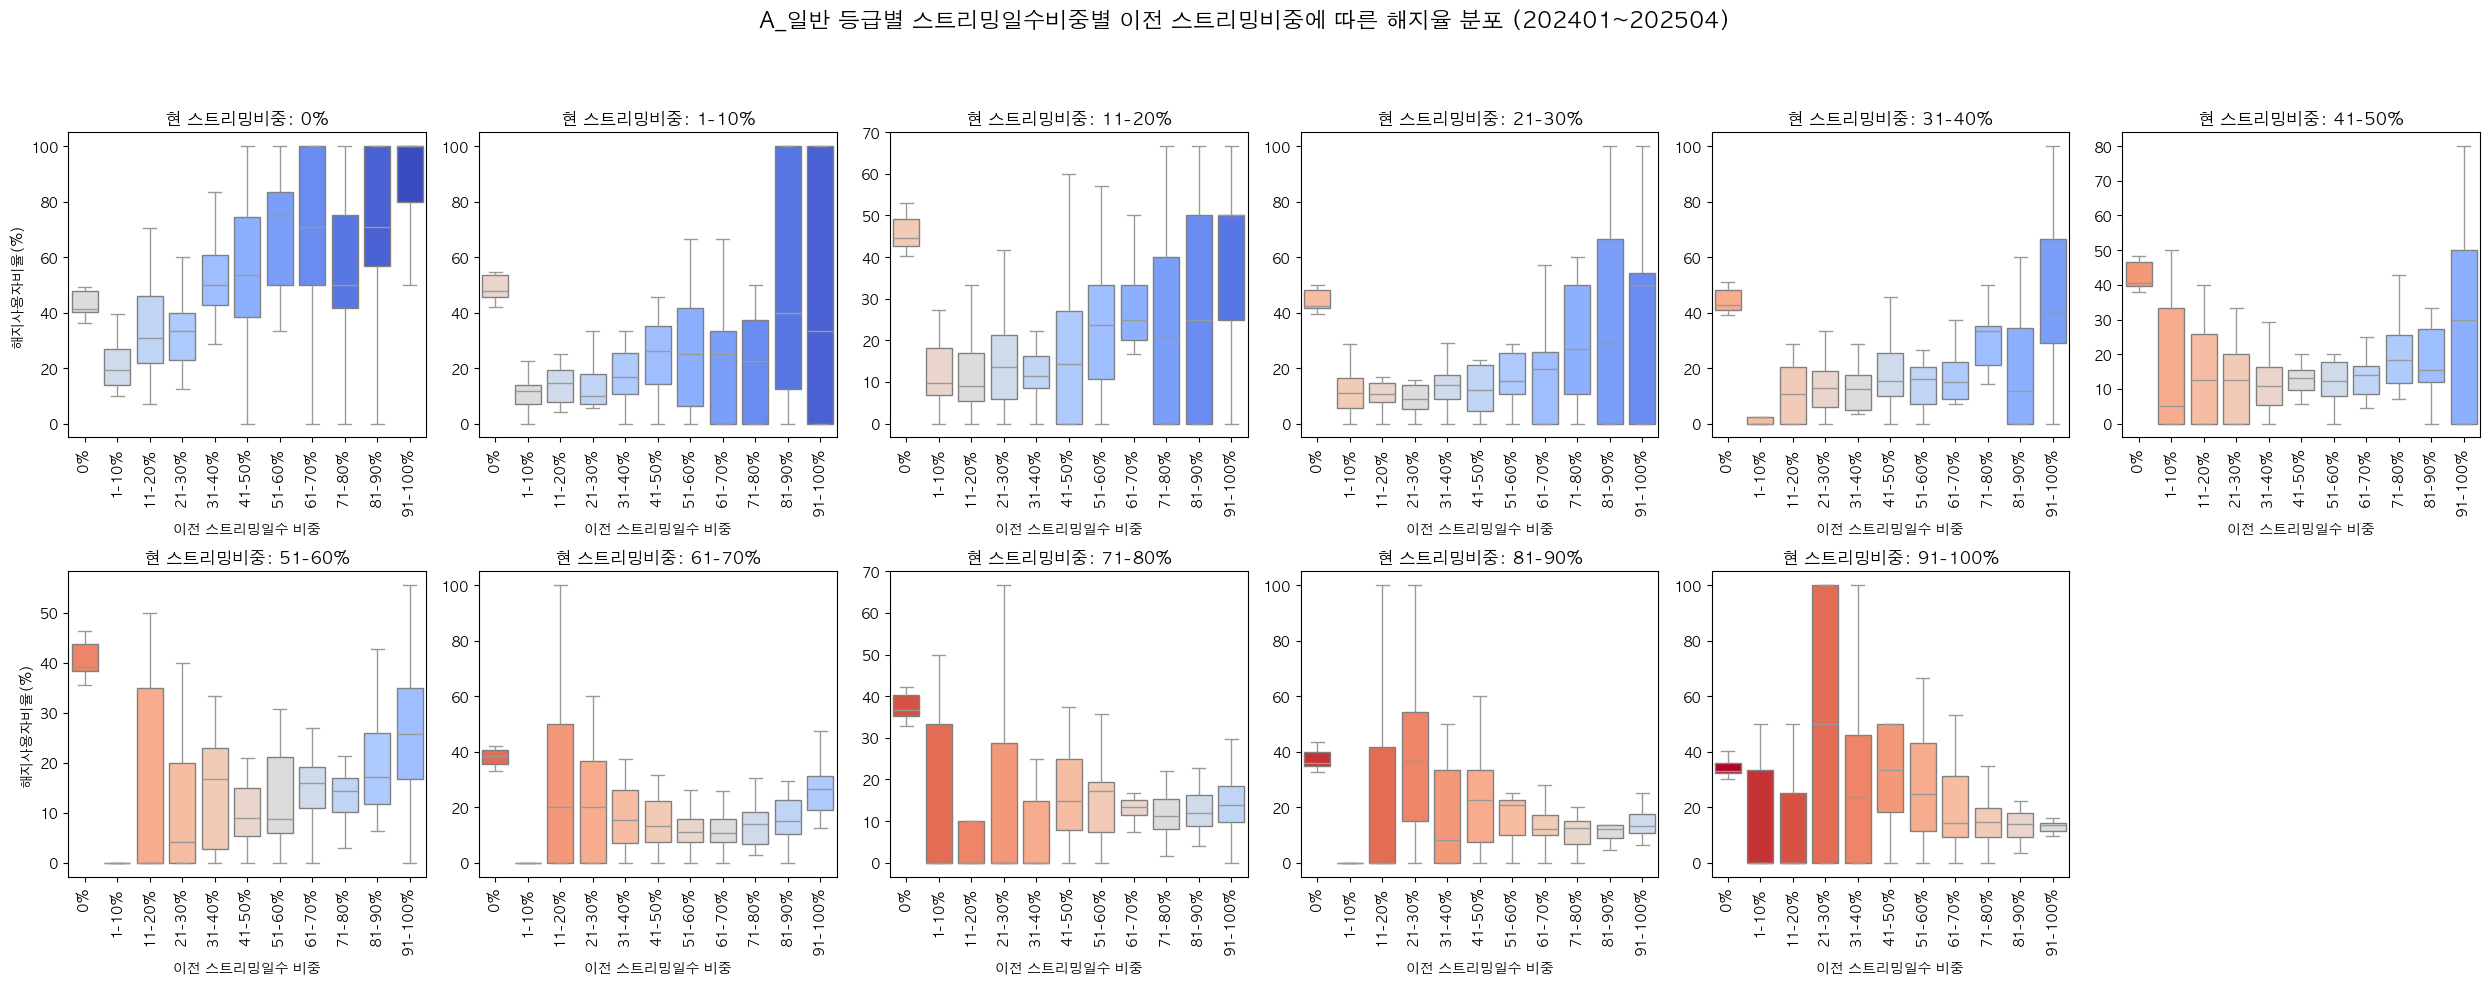

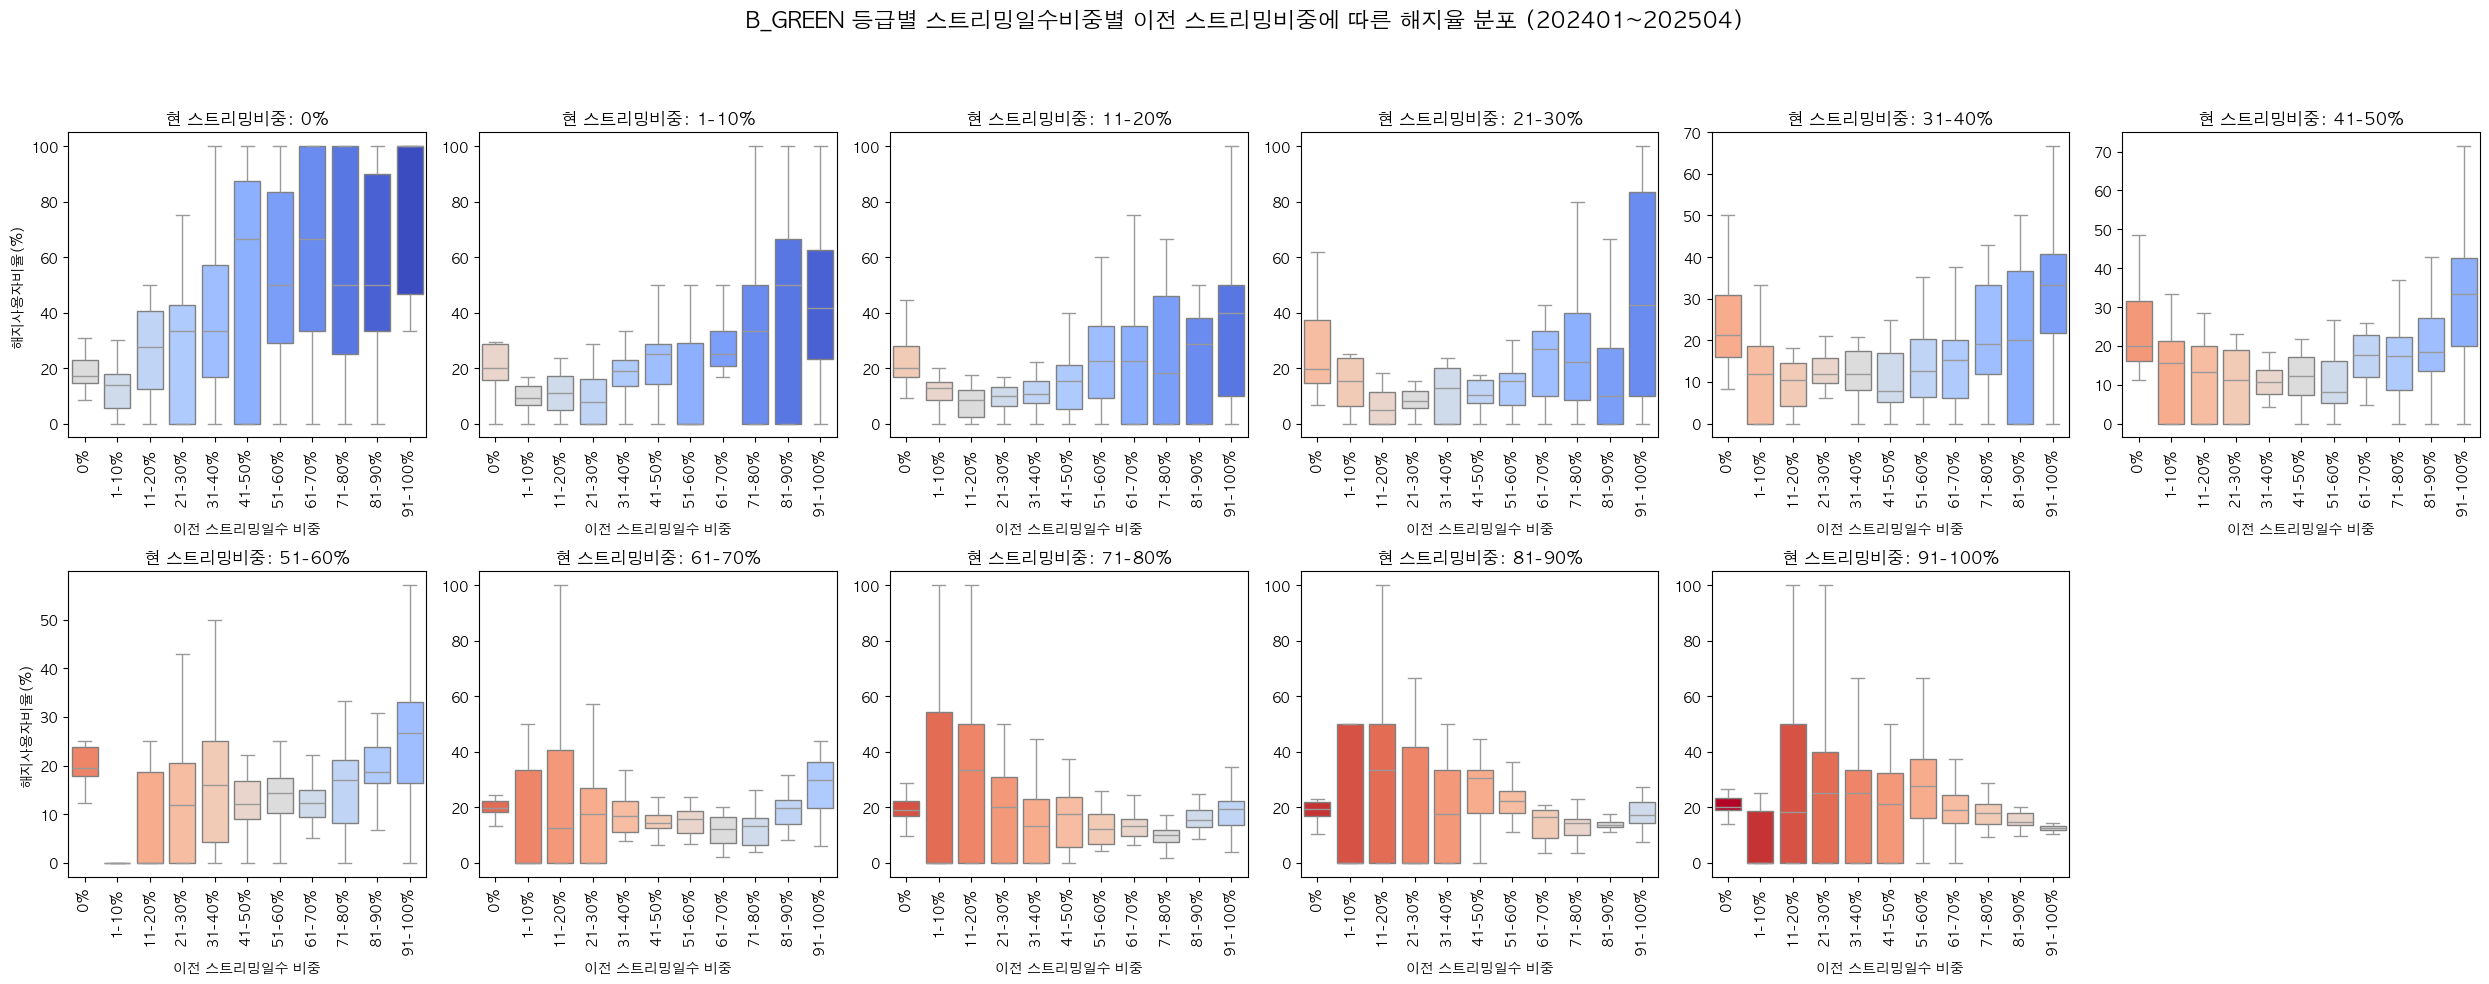

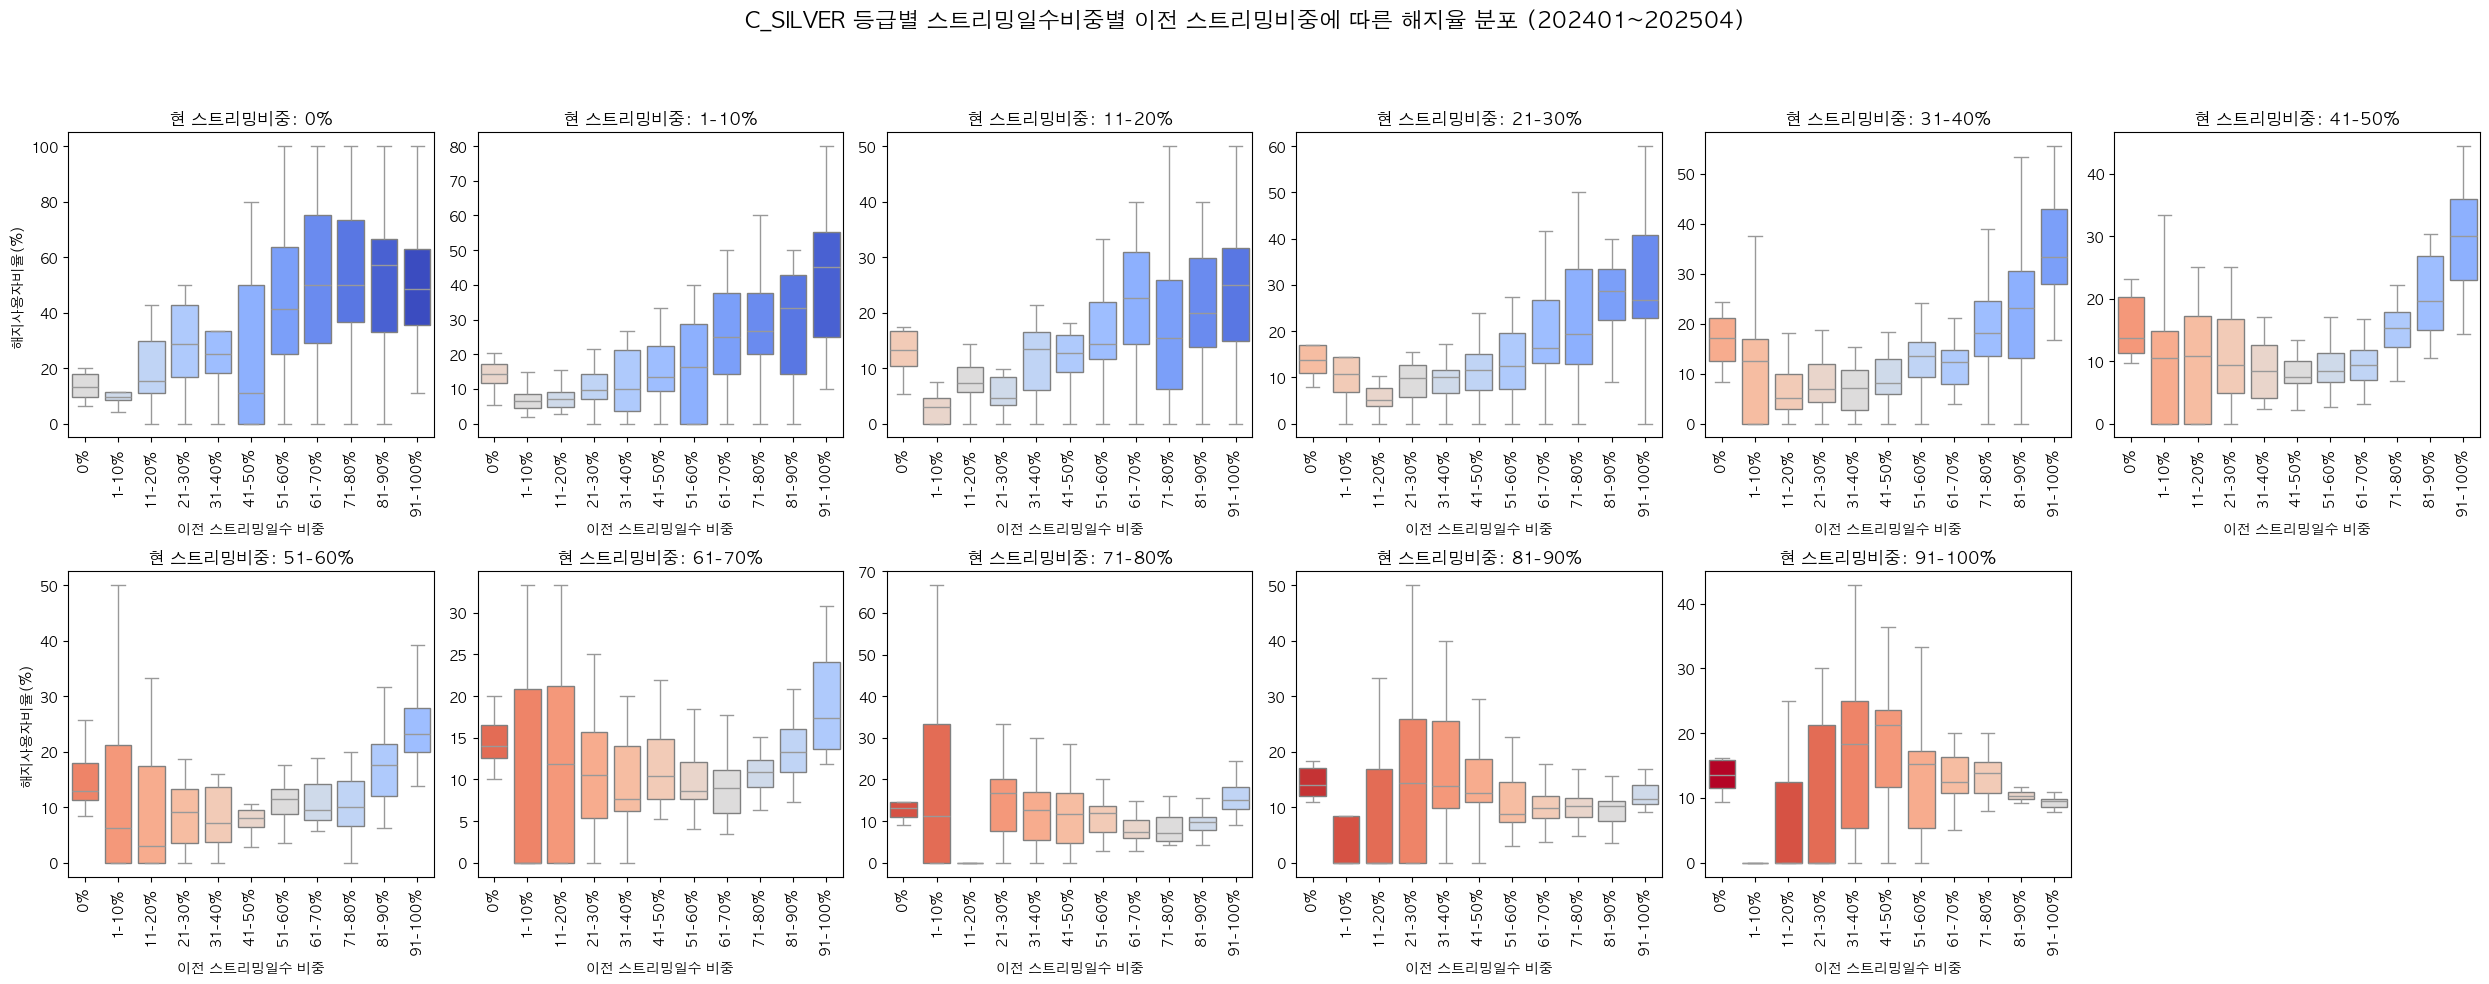

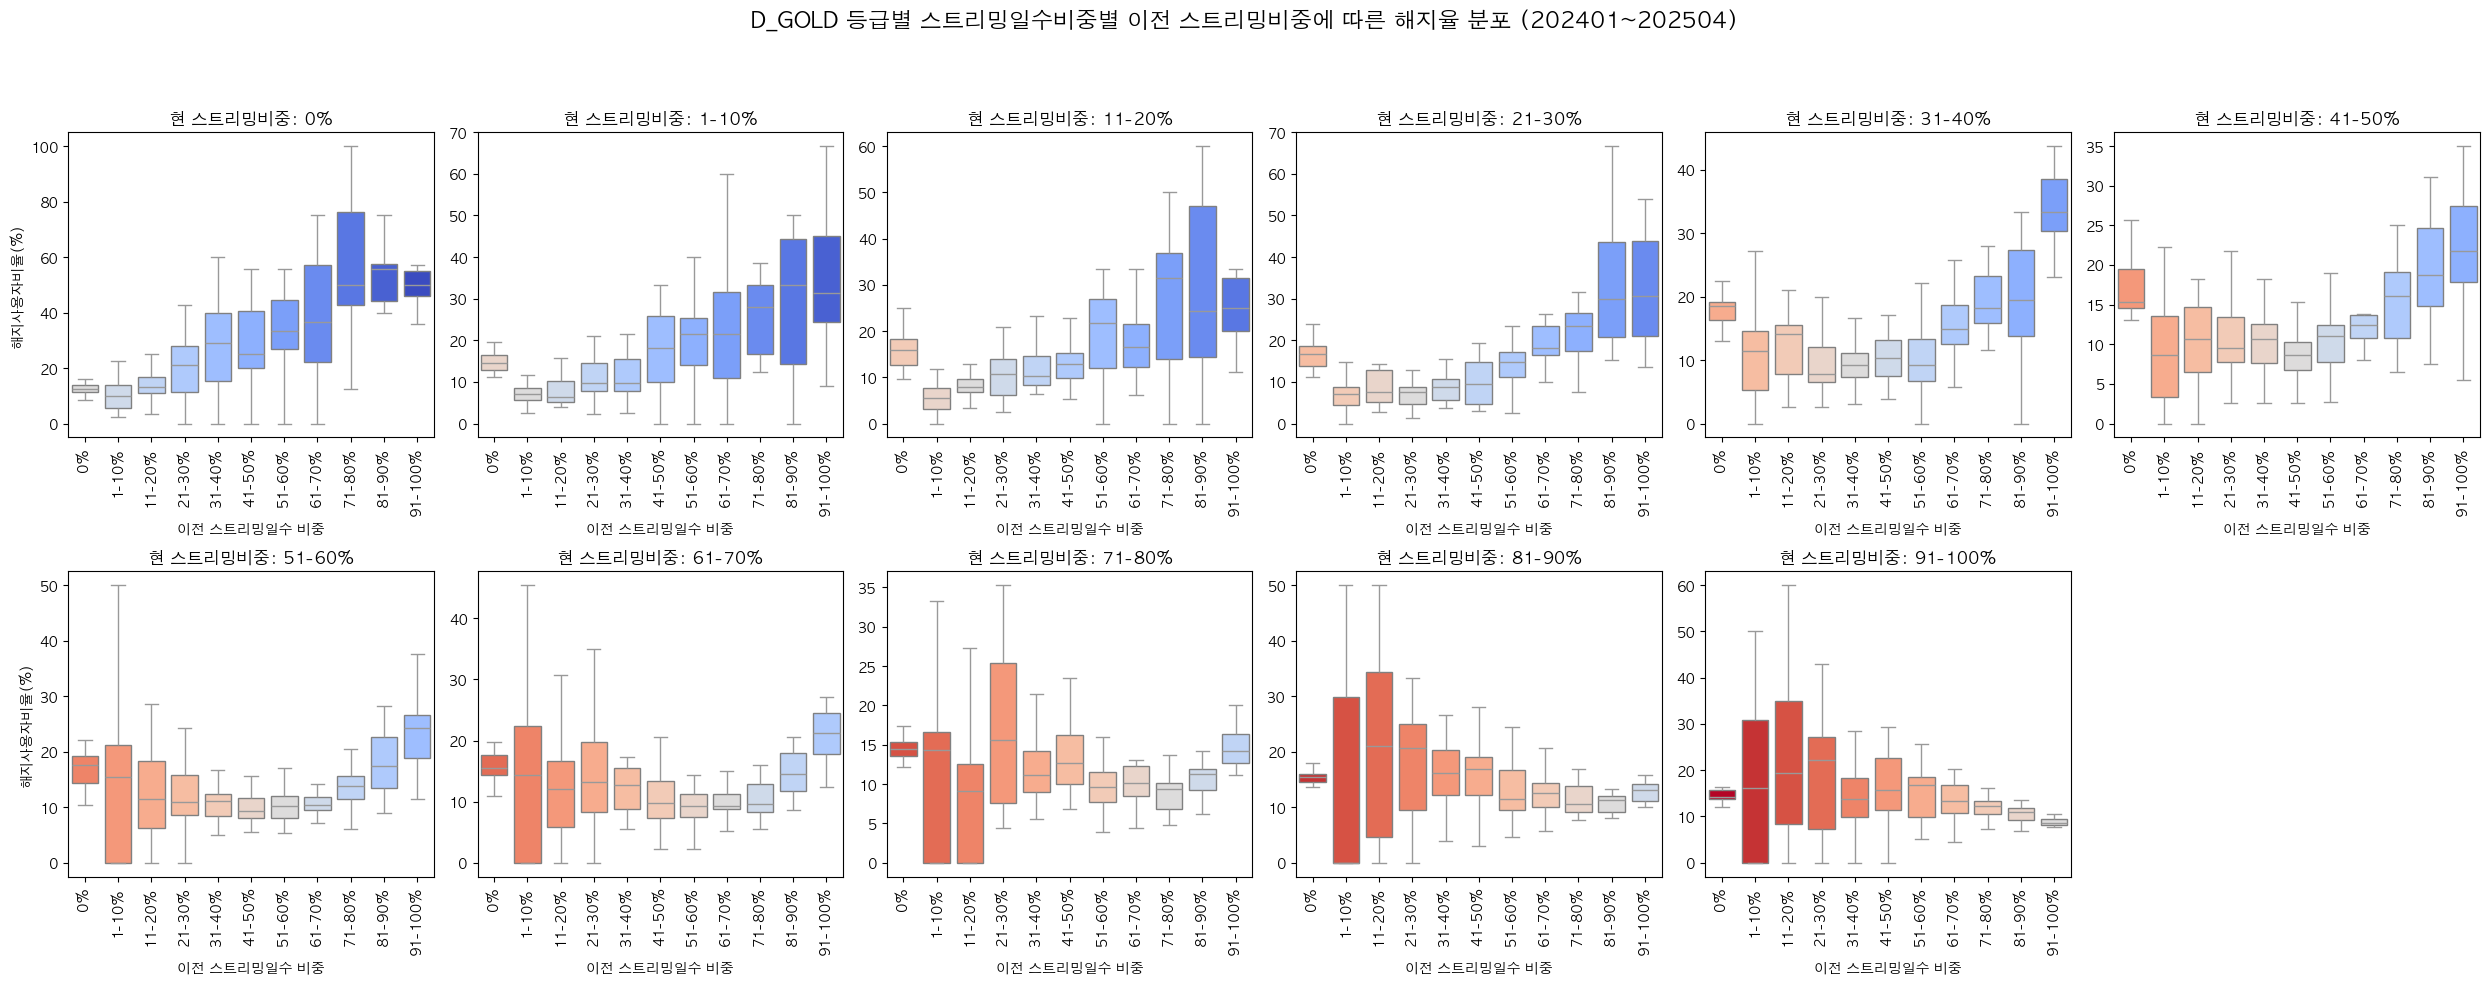

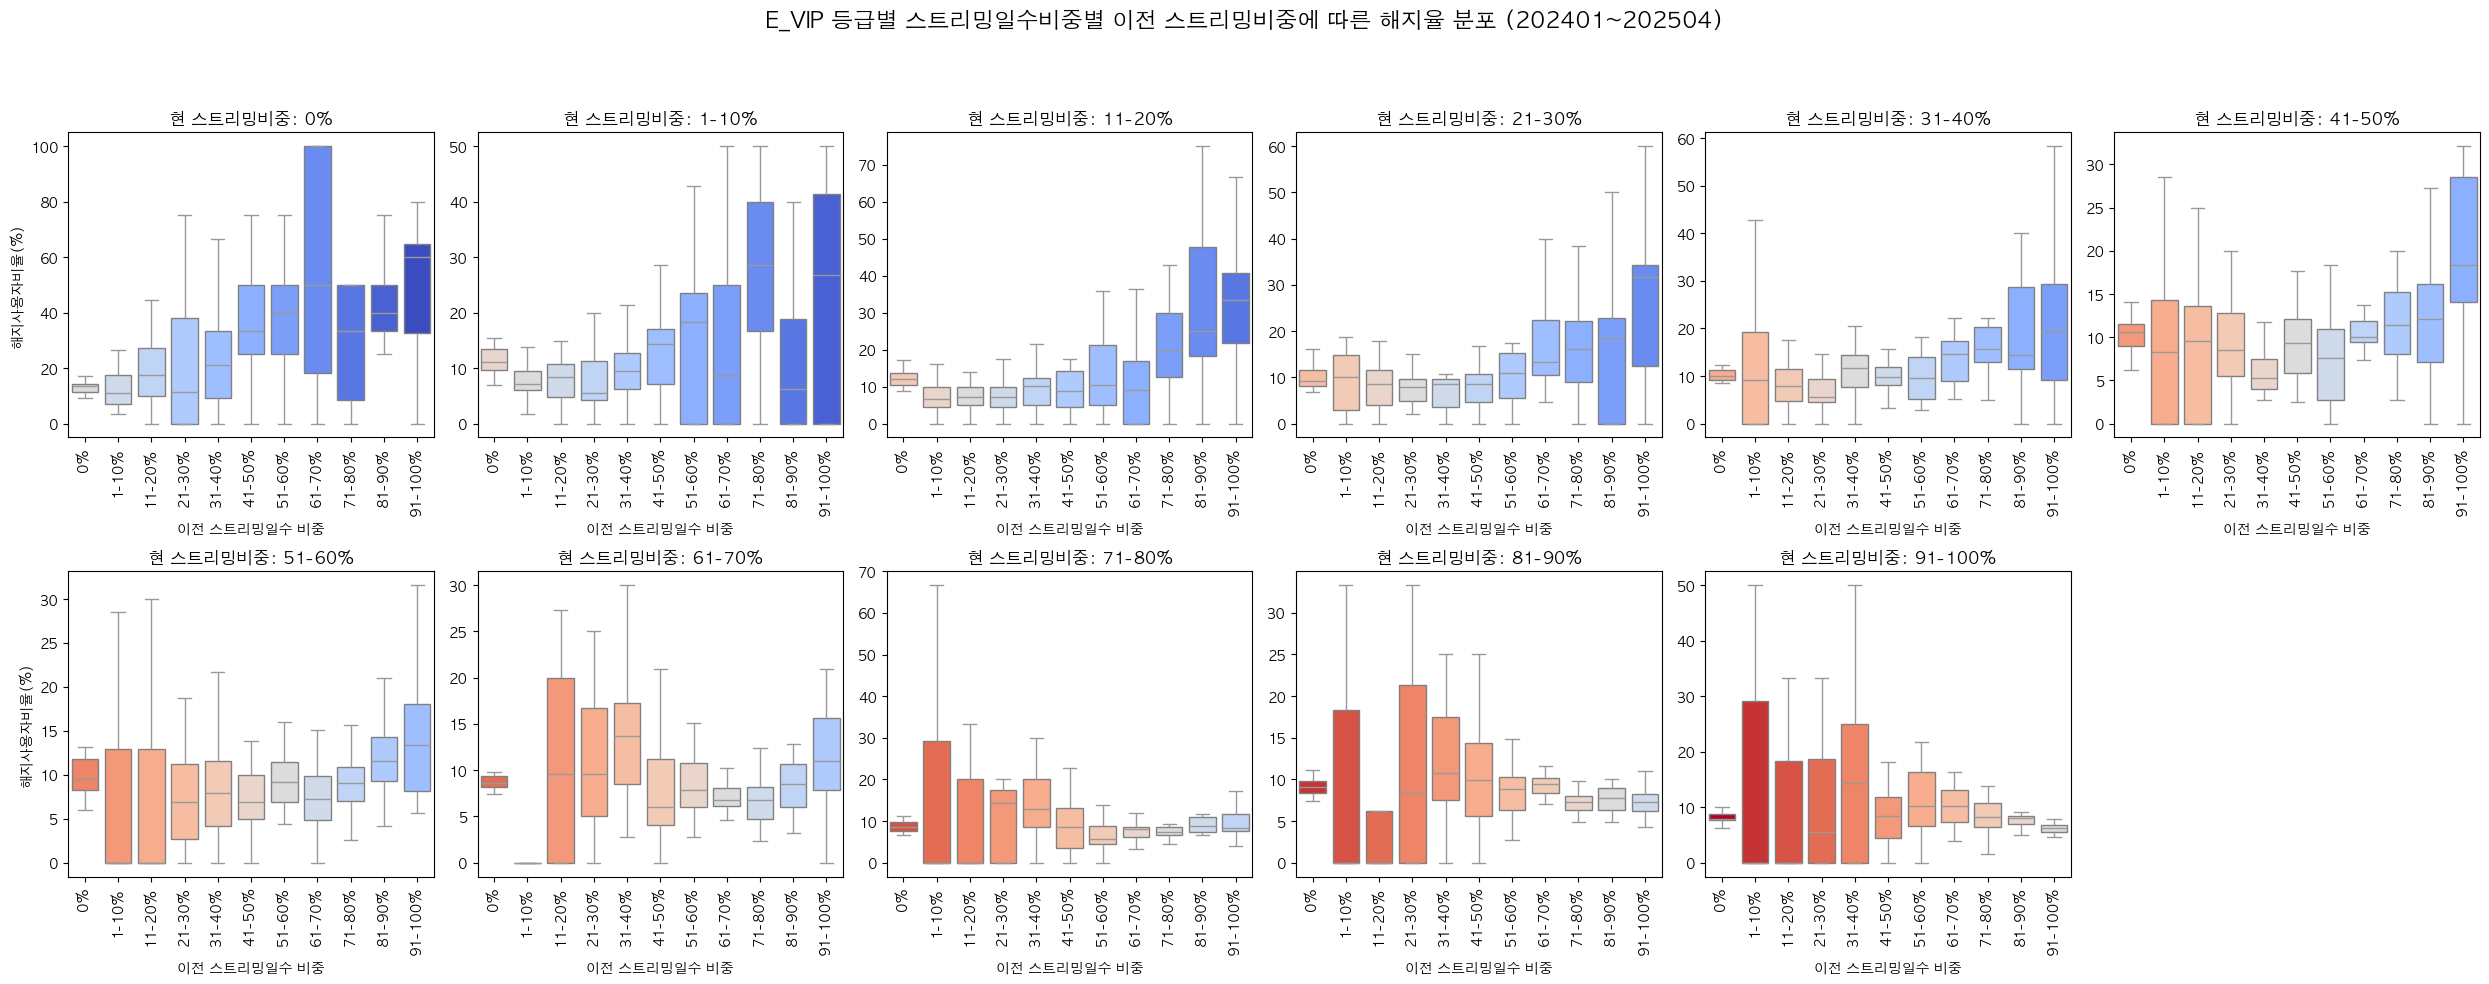

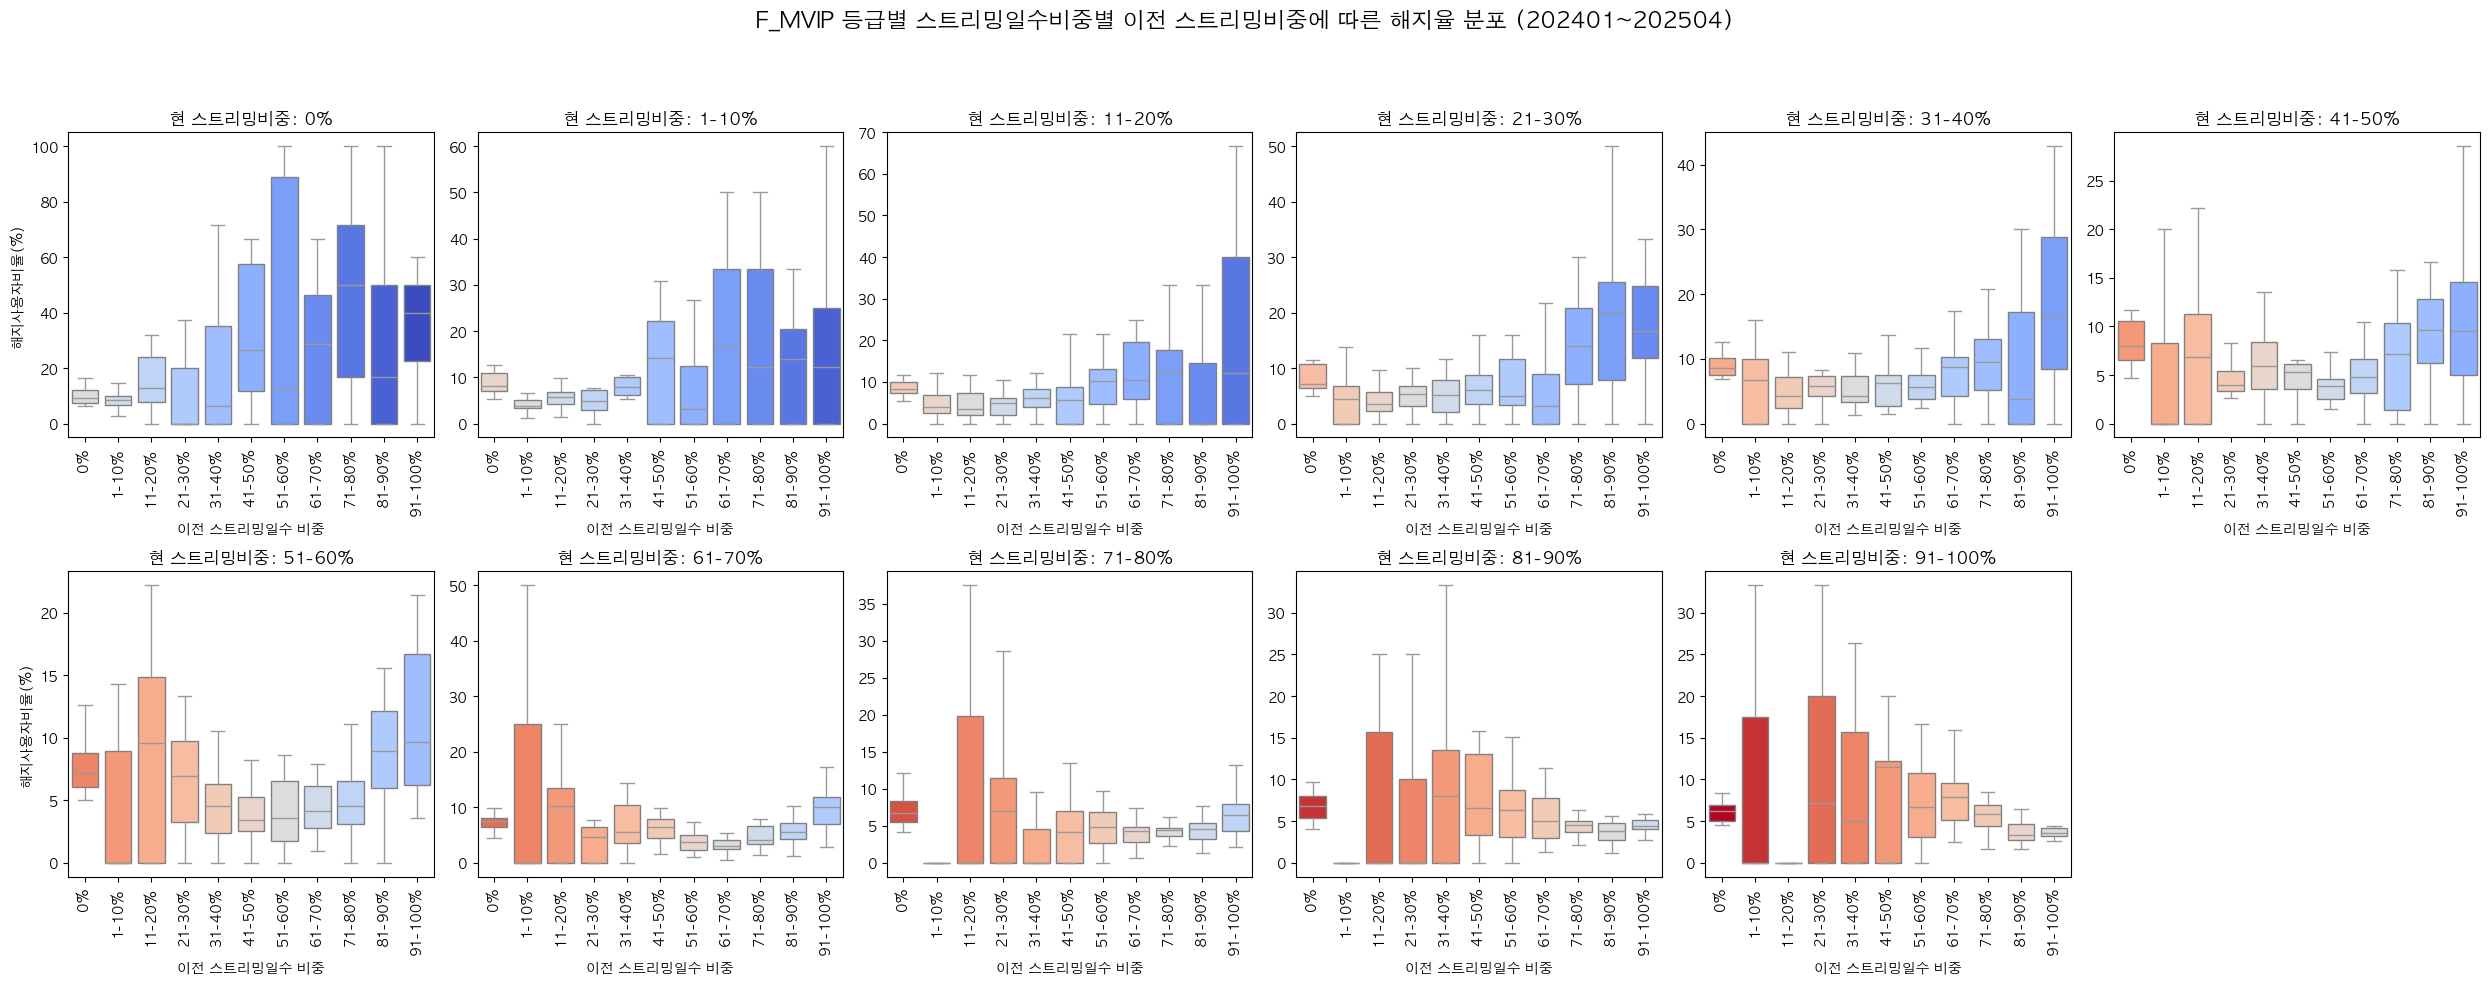

In [146]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. 데이터 전처리
df = promo_end_user_df.copy()
df['ym'] = df['ym'].astype(str)
df = df[(df['ym'] >= '202401') & (df['ym'] <= '202504')].copy()

pre_order = ['0%', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '51-60%','61-70%', '71-80%', '81-90%', '91-100%']
cur_order = ['0%', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '51-60%','61-70%', '71-80%', '81-90%', '91-100%']
df['pre_st_day_ratio'] = pd.Categorical(df['pre_st_day_ratio'], categories=pre_order, ordered=True)
df['st_day_ratio_group'] = pd.Categorical(df['st_day_ratio_group'], categories=cur_order, ordered=True)

# 2. gradation 색상 함수 (YlGnBu_r: 파랑~노랑, RdPu: 빨강~보라 등 선택 가능)
def get_gradation_color(pre_group, cur_group, cmap_name="coolwarm"):
    group_map = {
        '0%': 0, '1-10%': 1, '11-20%': 2, '21-30%': 3, '31-40%': 4,
        '41-50%': 5, '51-60%': 6, '61-70%': 7, '71-80%': 8, '81-90%': 9, '91-100%': 10
    }
    pre_num = group_map.get(pre_group, np.nan)
    cur_num = group_map.get(cur_group, np.nan)
    if np.isnan(pre_num) or np.isnan(cur_num):
        return '#cccccc'
    diff = cur_num - pre_num  # -10 ~ +10
    norm_val = (diff + 10) / 20  # -10~+10 → 0~1
    cmap = matplotlib.colormaps[cmap_name]
    rgba = cmap(norm_val)
    return matplotlib.colors.to_hex(rgba, keep_alpha=False)

# 3. boxplot 그리기
for vip in df['vip_grade_nm'].unique():
    n_cols = int(np.ceil(len(cur_order) / 2))
    fig, axes = plt.subplots(2, n_cols, figsize=(25, 10), sharey=False)
    fig.suptitle(f"{vip} 등급별 스트리밍일수비중별 이전 스트리밍비중에 따른 해지율 분포 (202401~202504)", fontsize=16)
    axes = axes.flatten()  # 1차원 배열로 변환

    for idx, curr in enumerate(cur_order):
        ax = axes[idx]
        sub = df[(df['vip_grade_nm'] == vip) & (df['st_day_ratio_group'] == curr)]
        box = sns.boxplot(
            x='pre_st_day_ratio', y='out_user_ratio', data=sub,
            ax=ax, showfliers=False, linewidth=1, color='white'
        )
        # gradation 색상 적용
        for patch_idx, patch in enumerate(ax.patches):
            if patch_idx < len(pre_order):
                color = get_gradation_color(pre_order[patch_idx], curr, cmap_name="coolwarm")
                patch.set_facecolor(color)
                patch.set_edgecolor('grey')
        ax.set_title(f"현 스트리밍비중: {curr}")
        ax.set_xlabel("이전 스트리밍일수 비중")
        # x축 라벨 180도 회전 (FixedLocator 사용)
        ax.tick_params(axis='x', labelrotation=90)
        if idx % n_cols == 0:
            ax.set_ylabel("해지사용자비율(%)")
        else:
            ax.set_ylabel("")
    # 남는 subplot 숨기기
    for j in range(len(cur_order), len(axes)):
        axes[j].axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

### 3) 해지신청 취소 및 미신청 사용자 해지율 변화
- 해지신청 사용자의 경우 사용량 감소나 증감의 원인이 불명확

In [15]:
cncl_req_none_user_query = '''
select t1.buy_no_partition as ym
     , t1.vip_grade_nm	
     , t1.st_day_ratio_group
     , case
            when pre_st_day_ratio = 0 or pre_st_day_ratio is null then '0%'
            when pre_st_day_ratio < 11 then '1-10%'
            when pre_st_day_ratio < 21 then '11-20%'
            when pre_st_day_ratio < 31 then '21-30%'
            when pre_st_day_ratio < 41 then '31-40%'
            when pre_st_day_ratio < 51 then '41-50%'
            when pre_st_day_ratio < 61 then '51-60%'
            when pre_st_day_ratio < 71 then '61-70%'
            when pre_st_day_ratio < 81 then '71-80%'
            when pre_st_day_ratio < 91 then '81-90%'
            else '91-100%'
          end as pre_st_day_ratio     
    , count(distinct member_key) as user_cnt
    , round(cast(count(distinct member_key) as double)/cast(tot_user_cnt as double)*100,2) as user_ratio_by_pre_st_day_ratio
	 , count(distinct if(out_yn = 'N',member_key)) as keep_user_cnt        
    , count(distinct if(out_yn = 'Y',member_key)) as out_user_cnt    
	 , round(cast(count(distinct if(out_yn = 'N',member_key)) as double)/cast(count(distinct member_key) as double)*100,2) as keep_user_ratio     
    , round(cast(count(distinct if(out_yn = 'Y',member_key)) as double)/cast(count(distinct member_key) as double)*100,2) as out_user_ratio     
from(
   select buy_no_partition
        , user_mkey as member_key
        , first_buy_no
        , buy_no
        , vip_grade_nm
        , st_day_ratio
        , case
            when st_day_ratio = 0 or st_day_ratio is null then '0%'
            when st_day_ratio < 11 then '1-10%'
            when st_day_ratio < 21 then '11-20%'
            when st_day_ratio < 31 then '21-30%'
            when st_day_ratio < 41 then '31-40%'
            when st_day_ratio < 51 then '41-50%'
            when st_day_ratio < 61 then '51-60%'
            when st_day_ratio < 71 then '61-70%'
            when st_day_ratio < 81 then '71-80%'
            when st_day_ratio < 91 then '81-90%'
            else '91-100%'
          end as st_day_ratio_group
        , out_yn
        , lag(st_day_ratio) over(partition by first_buy_no order by buy_date) as pre_st_day_ratio
        , st_day_ratio - lag(st_day_ratio) over(partition by first_buy_no order by buy_date) as diff_st_day_ratio
   from hadoop_kent.melon_sys_temp_production.samuel_prod_use_stat_dtl_tb
   where auto_bill_staus_code = '1Q0100' or auto_bill_staus_code is null -- 해지요청이 없는 사용자
   and remain_offer_cnt = 0
   and normal_price_yn = 1
   and user_trgt_nm = '일반' --체리피커,B리스트 제외
) t1
left join(
   select buy_no_partition        
        , vip_grade_nm
        , case
            when st_day_ratio = 0 or st_day_ratio is null then '0%'
            when st_day_ratio < 11 then '1-10%'
            when st_day_ratio < 21 then '11-20%'
            when st_day_ratio < 31 then '21-30%'
            when st_day_ratio < 41 then '31-40%'
            when st_day_ratio < 51 then '41-50%'
            when st_day_ratio < 61 then '51-60%'
            when st_day_ratio < 71 then '61-70%'
            when st_day_ratio < 81 then '71-80%'
            when st_day_ratio < 91 then '81-90%'
            else '91-100%'
          end as st_day_ratio_group
        , count(distinct user_mkey) as tot_user_cnt
   from hadoop_kent.melon_sys_temp_production.samuel_prod_use_stat_dtl_tb
   where auto_bill_staus_code = '1Q0100' or auto_bill_staus_code is null -- 해지요청이 없는 사용자
   and remain_offer_cnt = 0
   and normal_price_yn = 1
   and user_trgt_nm = '일반' --체리피커,B리스트 제외
   group by 1,2,3
) t2 on t1.buy_no_partition = t2.buy_no_partition and t1.vip_grade_nm = t2.vip_grade_nm and t1.st_day_ratio_group = t2.st_day_ratio_group
group by 1,2,3,4,tot_user_cnt
order by 1,2,3,4
'''

cur.execute(cncl_req_none_user_query)

results = cur.fetchall()
colnames = [part[0] for part in cur.description]

cncl_req_none_user_df = pd.DataFrame(results, columns=colnames)

cur.cancel()
conn.close()
cncl_req_none_user_df.head()

,ym,vip_grade_nm,st_day_ratio_group,pre_st_day_ratio,user_cnt,user_ratio_by_pre_st_day_ratio,keep_user_cnt,out_user_cnt,keep_user_ratio,out_user_ratio
0,202301,A_일반,0%,0%,18406,100.0,15850,2582,86.11,14.03
1,202301,A_일반,1-10%,0%,7627,100.0,6976,651,91.46,8.54
2,202301,A_일반,11-20%,0%,6157,100.0,5621,536,91.29,8.71
3,202301,A_일반,21-30%,0%,6222,100.0,5697,525,91.56,8.44
4,202301,A_일반,31-40%,0%,6997,100.0,6232,765,89.07,10.93


vip_grade_nm,A_일반,B_GREEN,C_SILVER,D_GOLD,E_VIP,F_MVIP
st_day_ratio_group,,,,,,
0%,0.876723,0.908218,0.894287,0.894148,0.821169,0.777315
1-10%,0.472547,0.647426,0.722405,0.831837,0.699818,0.628105
11-20%,0.483976,0.600787,0.686648,0.809199,0.636594,0.629842
21-30%,0.449748,0.571050,0.607534,0.720097,0.600396,0.509041
31-40%,0.326658,0.465767,0.552498,0.543812,0.524446,0.384641
41-50%,0.304949,0.395365,0.325427,0.341181,0.396648,0.129708
51-60%,0.097685,0.183558,0.192408,0.138858,-0.000696,-0.140576
61-70%,-0.152360,-0.003093,-0.072611,-0.235520,-0.249400,-0.282888
71-80%,-0.161663,-0.184990,-0.373943,-0.420248,-0.363324,-0.410427


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.draw()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


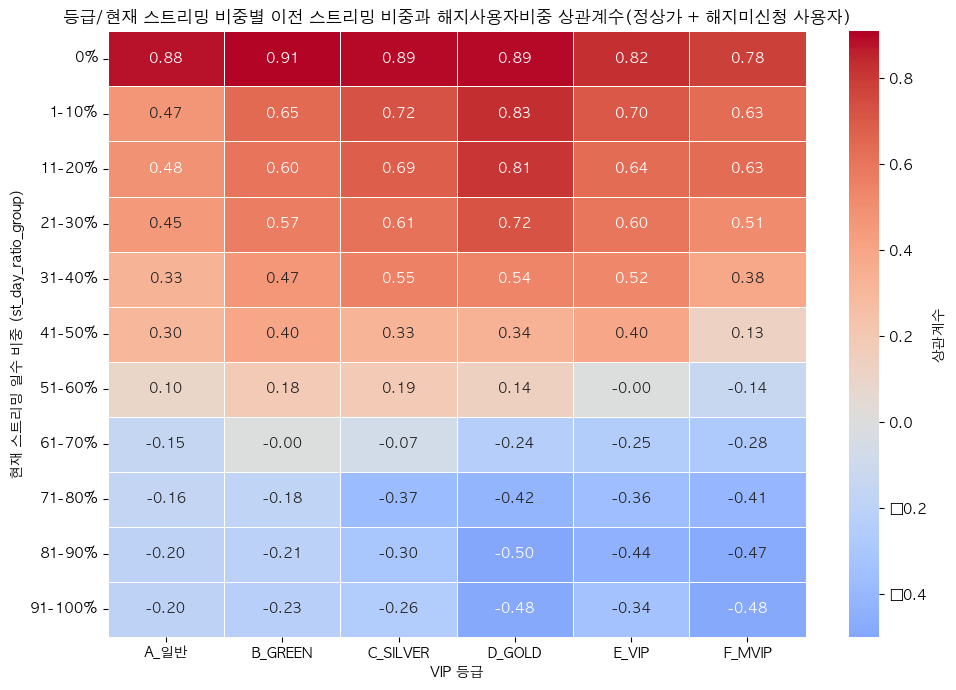

In [25]:
pre_map = {'0%':0, '1-10%':5, '11-20%':15, '21-30%':25, '31-40%':35, '41-50%':45, '51-60%':55, '61-70%':65, '71-80%':75, '81-90%':85, '91-100%':95}
df = cncl_req_none_user_df.copy()
df = df[df['pre_st_day_ratio'].notnull() & df['out_user_ratio'].notnull()]
df['pre_st_day_ratio_num'] = df['pre_st_day_ratio'].map(pre_map)

result = []
for grade in df['vip_grade_nm'].unique():
    for group in df['st_day_ratio_group'].unique():
        sub = df[(df['vip_grade_nm']==grade) & (df['st_day_ratio_group']==group)]
        if len(sub) > 1:  # 상관계수 계산 최소 2개
            corr = sub[['pre_st_day_ratio_num', 'out_user_ratio']].corr().iloc[0,1]
            result.append({'vip_grade_nm': grade, 'st_day_ratio_group': group, 'corr': corr})

corr_df = pd.DataFrame(result)

# corr_df를 pivot 형태로 변환 (x축: vip_grade_nm, y축: st_day_ratio_group)
pivot_corr = corr_df.pivot(index='st_day_ratio_group', columns='vip_grade_nm', values='corr')
display(pivot_corr)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.heatmap(
    pivot_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={'label': '상관계수'}
)
plt.title("등급/현재 스트리밍 비중별 이전 스트리밍 비중과 해지사용자비중 상관계수(정상가 + 해지미신청 사용자)")
plt.xlabel("VIP 등급")
plt.ylabel("현재 스트리밍 일수 비중 (st_day_ratio_group)")
plt.tight_layout()
plt.show()


In [148]:
# 등급, 현재 스트리밍 활성도, 이전 스트리밍 활성도별 해지사용자 비율 평균 pivot table 생성 (소수 둘째자리 반올림)
df = cncl_req_none_user_df.copy()
df['ym'] = df['ym'].astype(str)
df = df[(df['ym'] >= '202401') & (df['ym'] <= '202504')].copy()

pivot = pd.pivot_table(
    df,
    values='out_user_ratio',
    index=['vip_grade_nm', 'st_day_ratio_group'],
    columns='pre_st_day_ratio',
    aggfunc='mean'
)

pivot = pivot[['0%', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '51-60%','61-70%', '71-80%', '81-90%', '91-100%']]  # 보기 좋게 정렬
pivot = pivot.round(2)  # 소수 둘째자리 반올림
pivot

pre_st_day_ratio                    0%  1-10%  11-20%  21-30%  31-40%  41-50%  \
vip_grade_nm st_day_ratio_group                                                 
A_일반         0%                  14.83  10.21   13.13   15.68   21.25   26.02   
             1-10%                9.67   7.36    7.65    7.88    8.52    8.80   
             11-20%              10.01   7.78    7.73    7.48    8.32    8.46   
             21-30%              10.39   6.62    6.60    7.74    7.29    7.18   
             31-40%              10.55   7.86    7.15    8.14    8.13    7.26   
...                                ...    ...     ...     ...     ...     ...   
F_MVIP       51-60%               2.66   2.03    1.89    1.73    1.87    1.75   
             61-70%               2.59   2.18    2.09    1.96    1.84    1.74   
             71-80%               3.46   2.21    2.28    2.12    2.01    1.94   
             81-90%               3.73   2.62    2.54    1.90    2.10    2.18   
             91-100%              3.79   3.61    2.34    2.90    2.56    2.39   

pre_st_day_ratio                 51-60%  61-70%  71-80%  81-90%  91-100%  
vip_grade_nm st_day_ratio_group                                           
A_일반         0%                   29.36   31.08   44.86   45.95    65.49  
             1-10%                10.17   10.22   13.44   17.56    21.17  
             11-20%                8.78   11.50   11.26    9.38    19.20  
             21-30%                8.02    8.93   11.18   10.22    15.14  
             31-40%                7.94    8.46    9.89   10.58    13.36  
...                                 ...     ...     ...     ...      ...  
F_MVIP       51-60%                1.72    1.79    1.91    2.14     2.50  
             61-70%                1.78    1.71    1.78    1.91     2.15  
             71-80%                1.86    1.78    1.71    1.84     1.94  
             81-90%                2.03    1.88    1.77    1.87     1.95  
             91-100%               2.10    1.92    1.88    1.89     1.89  

[66 rows x 11 columns]

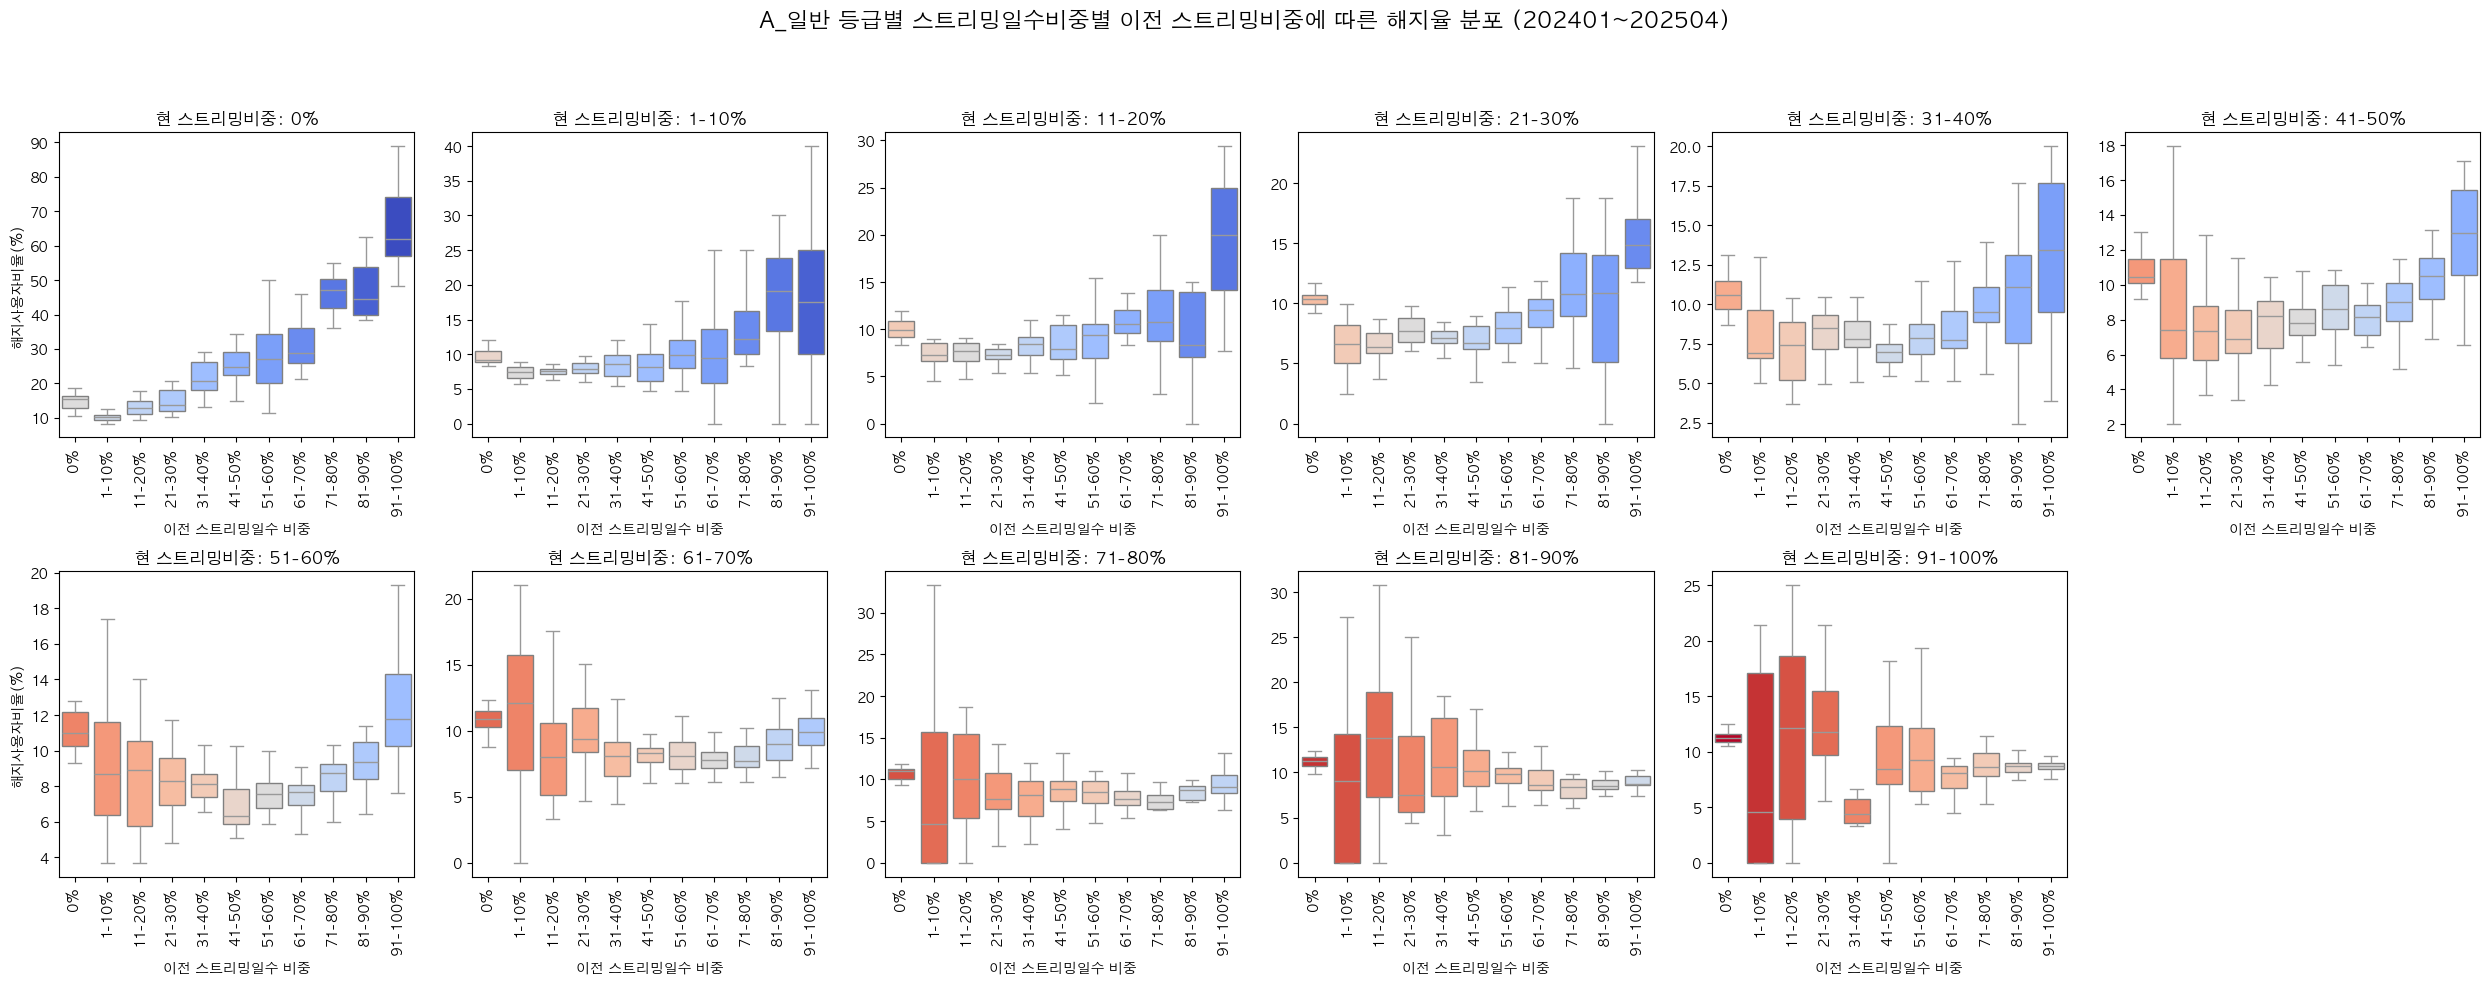

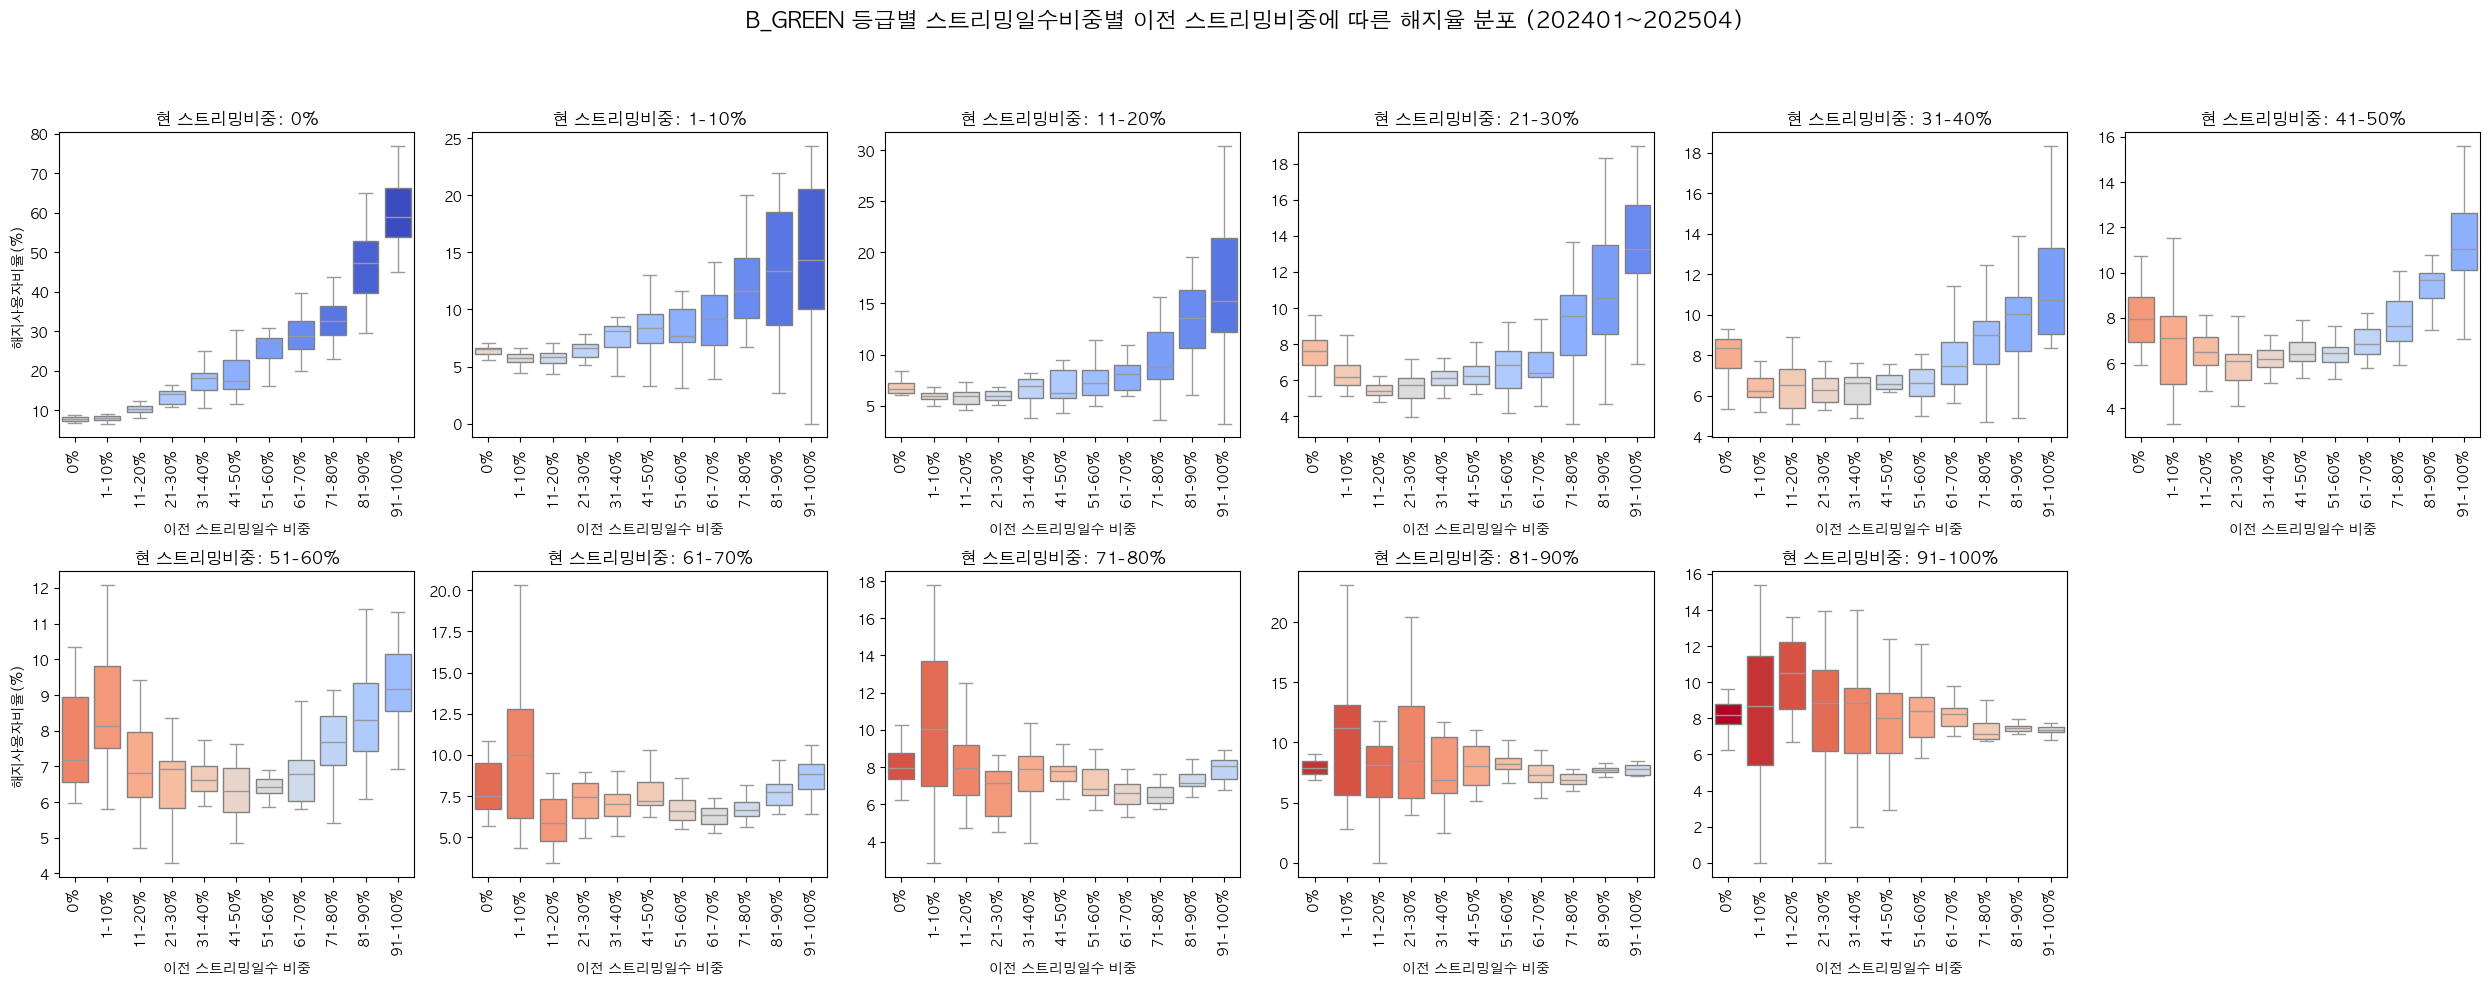

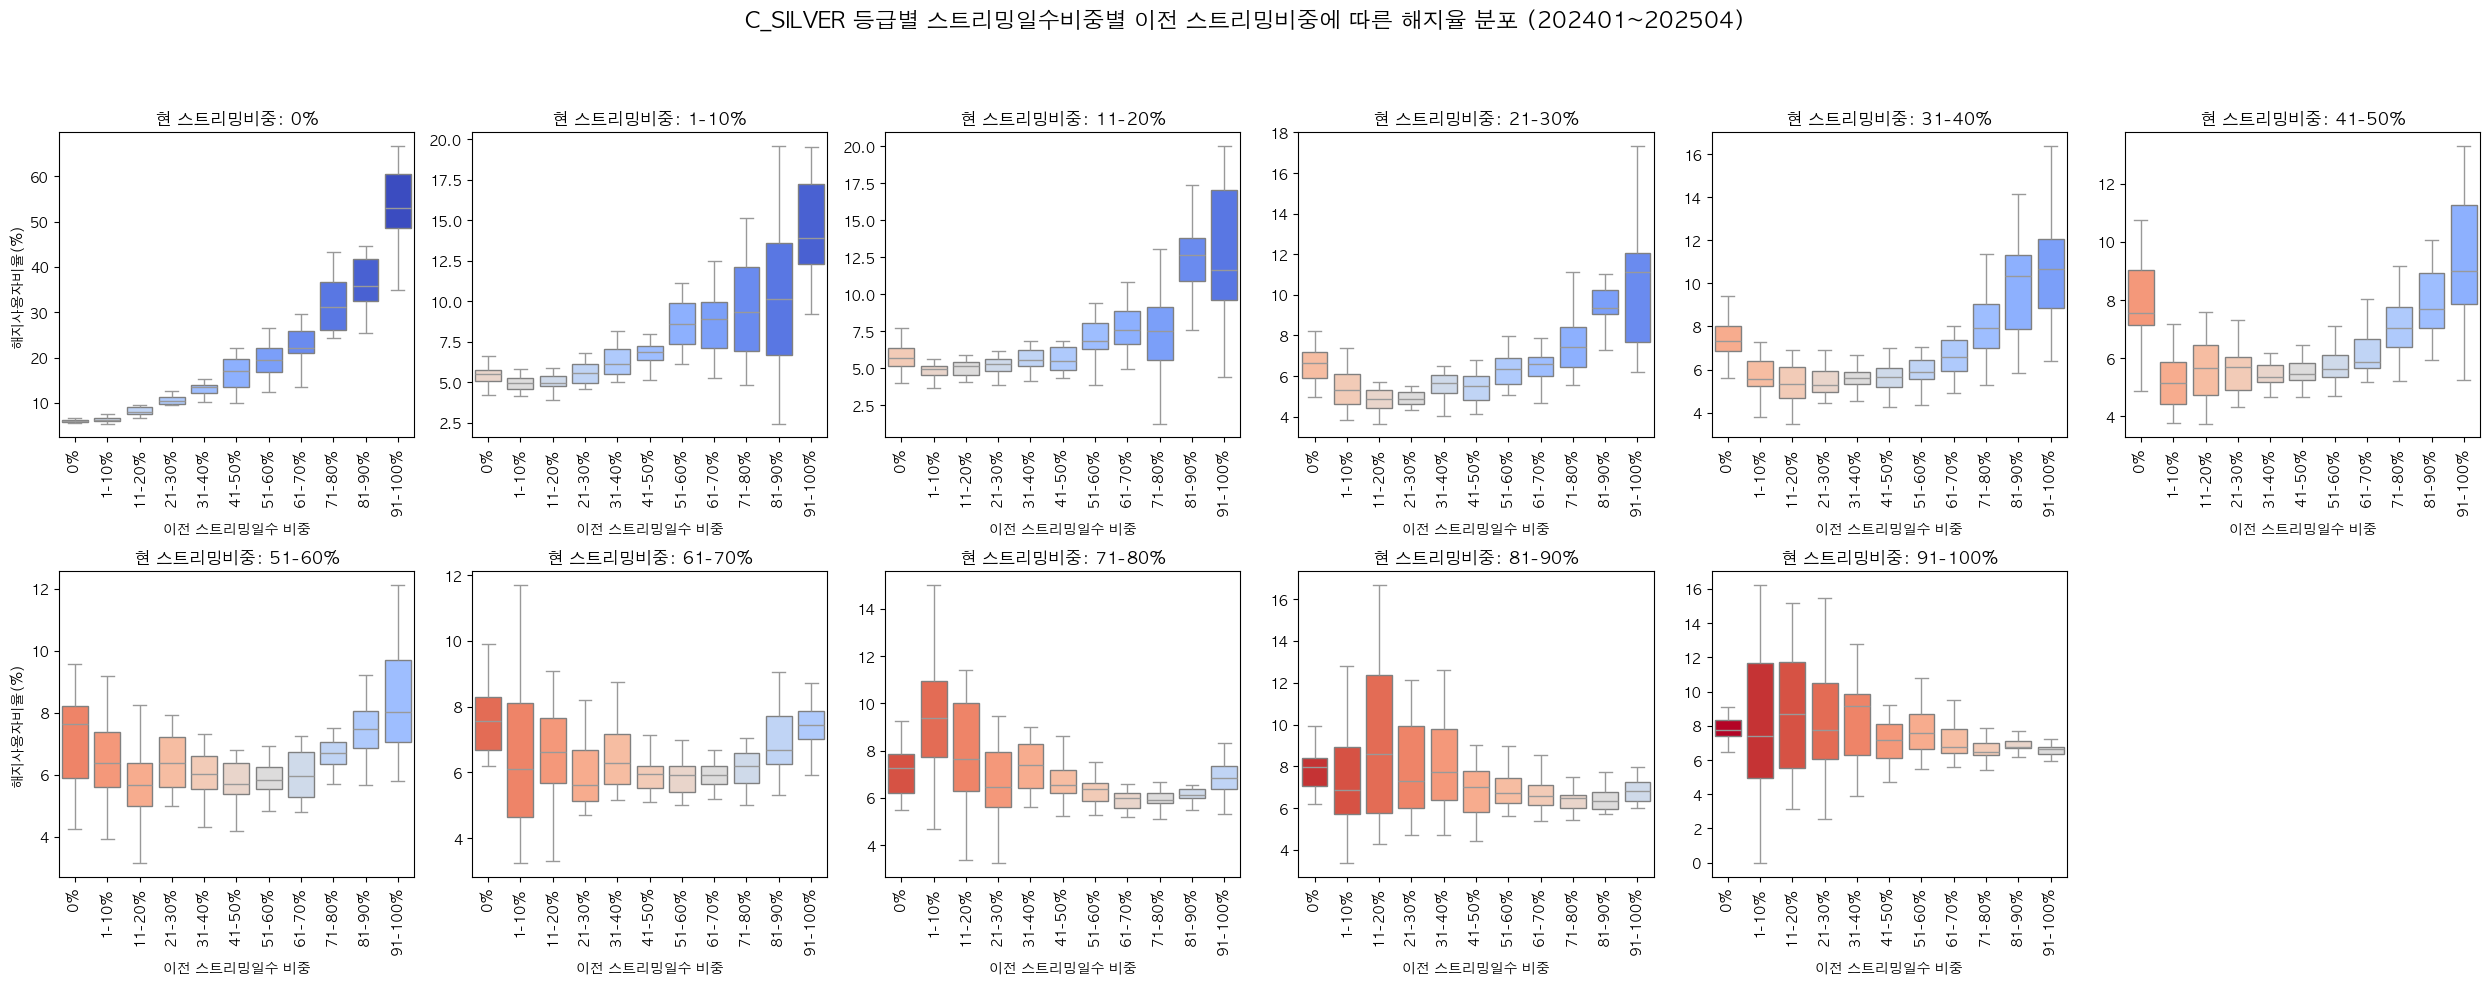

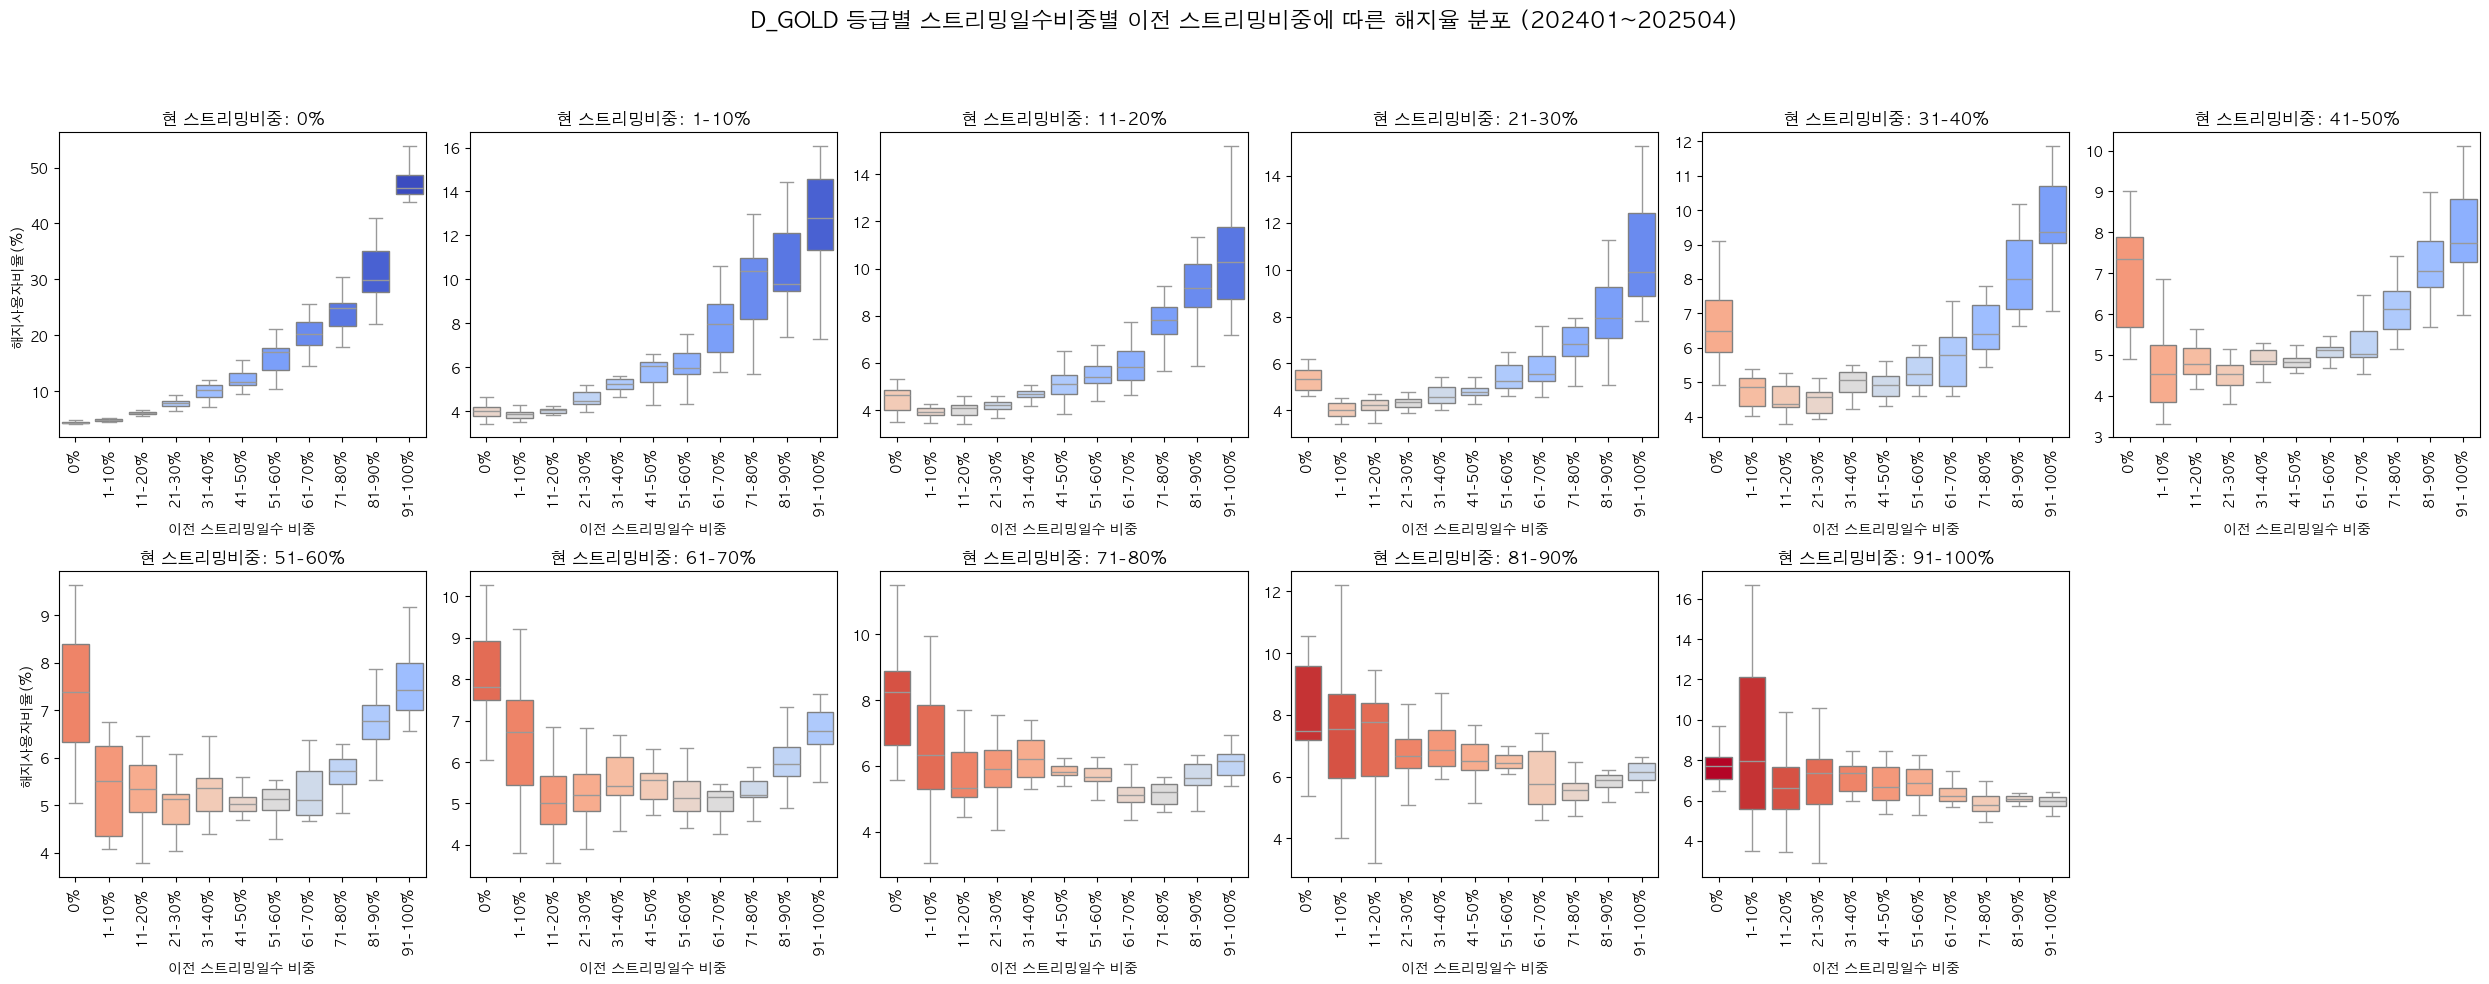

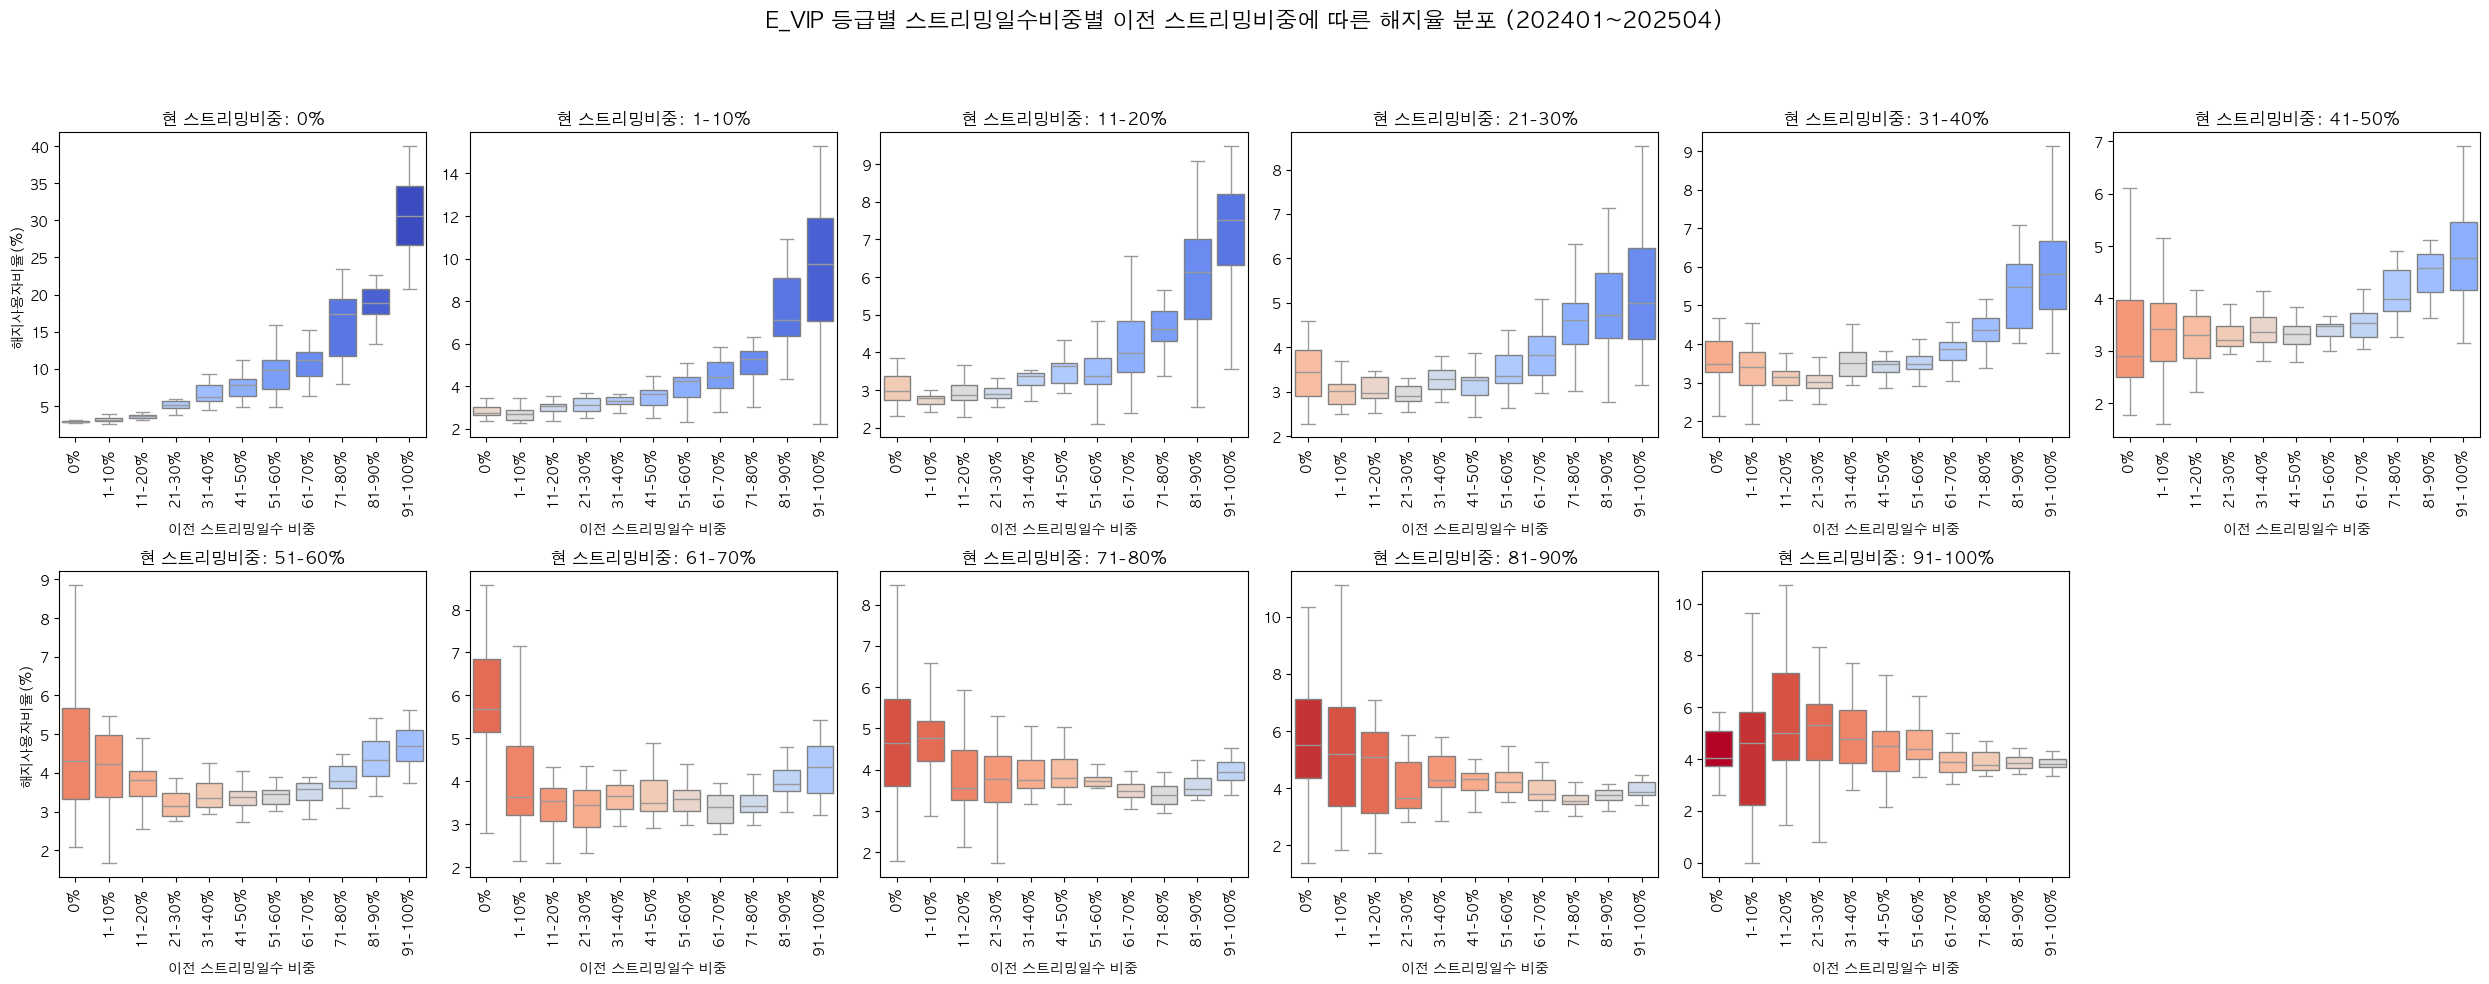

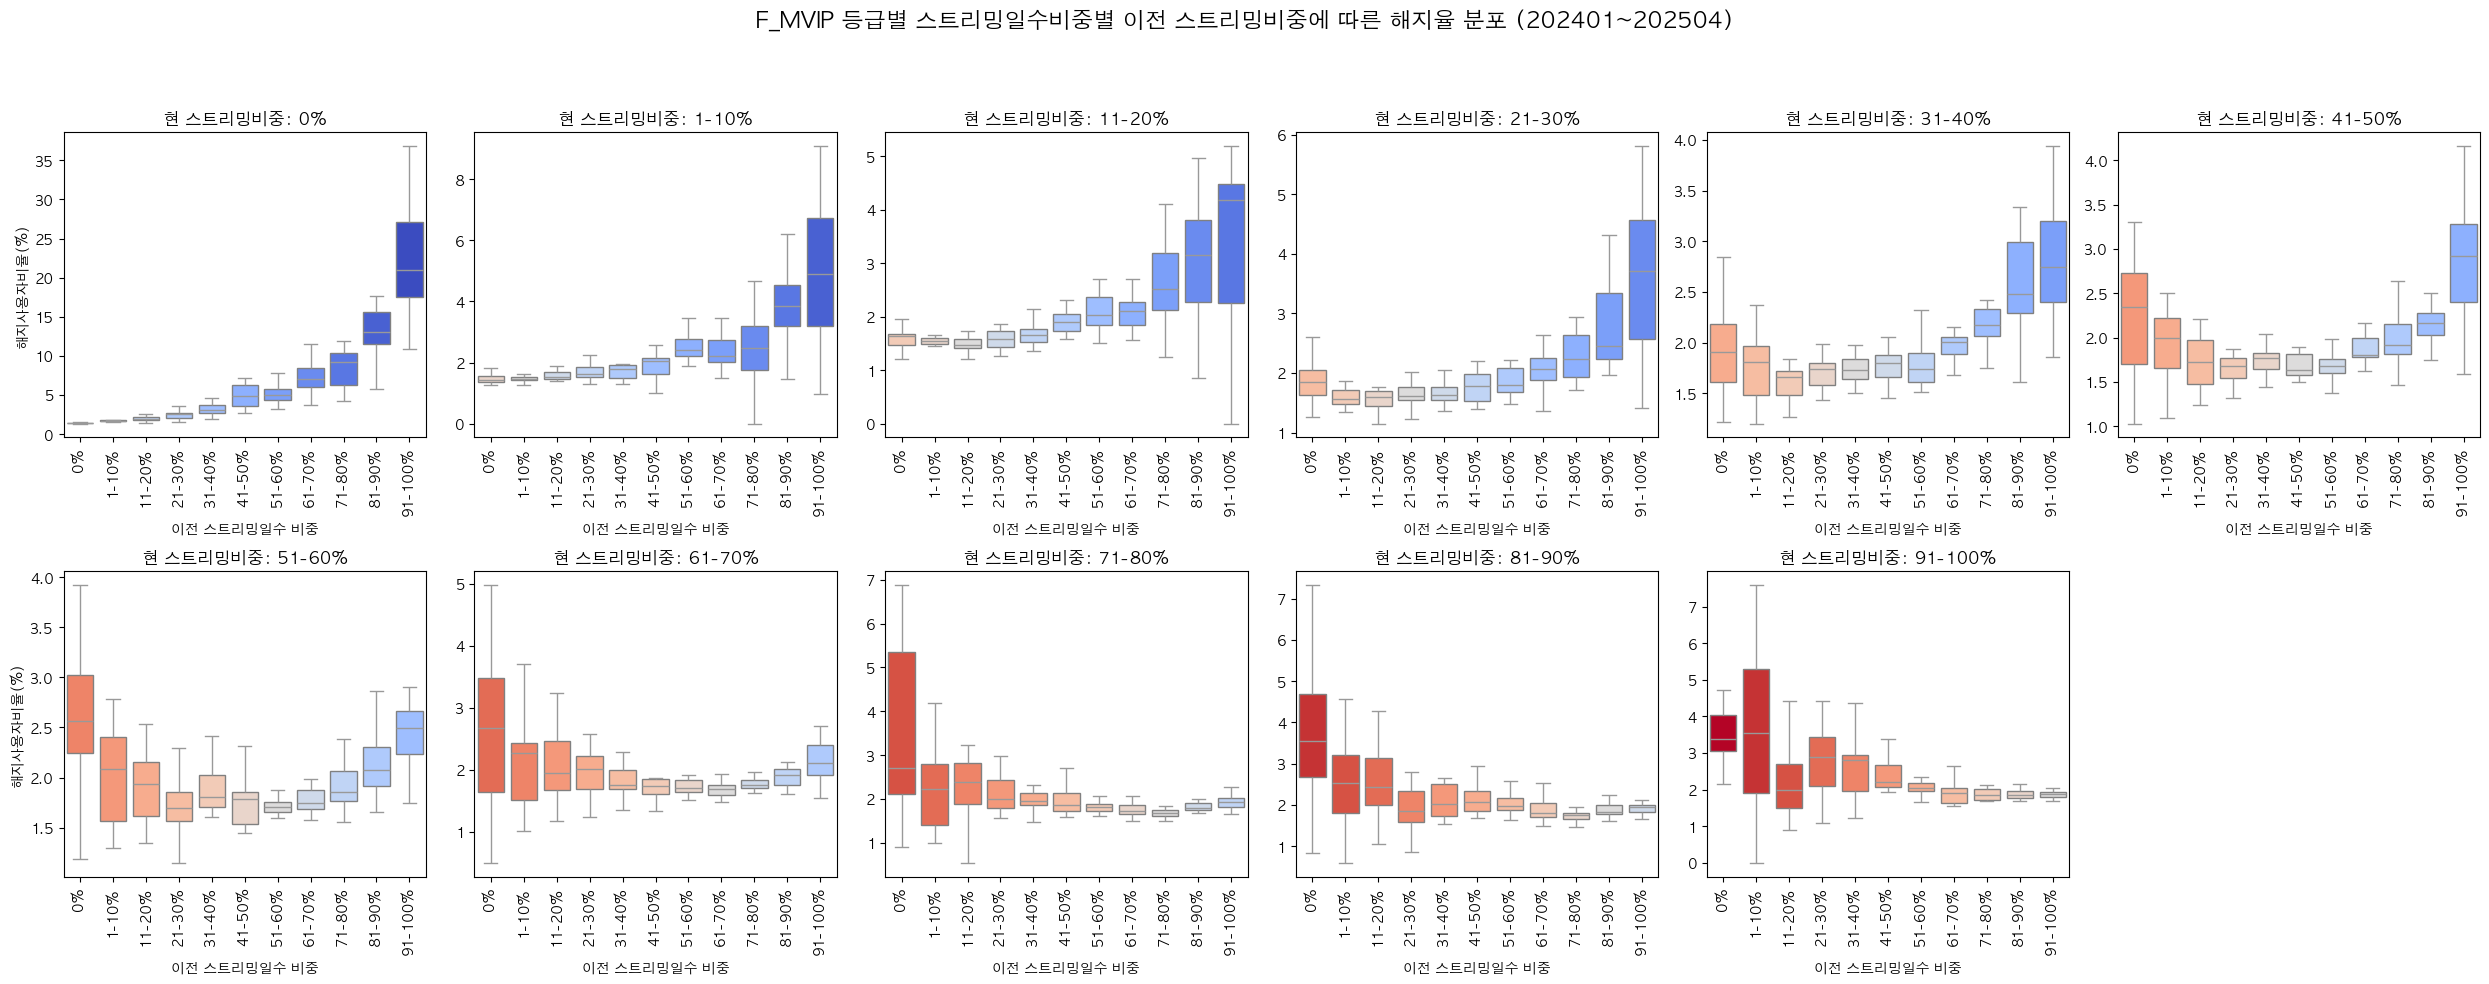

In [149]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. 데이터 전처리
df = cncl_req_none_user_df.copy()
df['ym'] = df['ym'].astype(str)
df = df[(df['ym'] >= '202401') & (df['ym'] <= '202504')].copy()

pre_order = ['0%', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '51-60%','61-70%', '71-80%', '81-90%', '91-100%']
cur_order = ['0%', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '51-60%','61-70%', '71-80%', '81-90%', '91-100%']
df['pre_st_day_ratio'] = pd.Categorical(df['pre_st_day_ratio'], categories=pre_order, ordered=True)
df['st_day_ratio_group'] = pd.Categorical(df['st_day_ratio_group'], categories=cur_order, ordered=True)

# 2. gradation 색상 함수 (YlGnBu_r: 파랑~노랑, RdPu: 빨강~보라 등 선택 가능)
def get_gradation_color(pre_group, cur_group, cmap_name="coolwarm"):
    group_map = {
        '0%': 0, '1-10%': 1, '11-20%': 2, '21-30%': 3, '31-40%': 4,
        '41-50%': 5, '51-60%': 6, '61-70%': 7, '71-80%': 8, '81-90%': 9, '91-100%': 10
    }
    pre_num = group_map.get(pre_group, np.nan)
    cur_num = group_map.get(cur_group, np.nan)
    if np.isnan(pre_num) or np.isnan(cur_num):
        return '#cccccc'
    diff = cur_num - pre_num  # -10 ~ +10
    norm_val = (diff + 10) / 20  # -10~+10 → 0~1
    cmap = matplotlib.colormaps[cmap_name]
    rgba = cmap(norm_val)
    return matplotlib.colors.to_hex(rgba, keep_alpha=False)

# 3. boxplot 그리기
for vip in df['vip_grade_nm'].unique():
    n_cols = int(np.ceil(len(cur_order) / 2))
    fig, axes = plt.subplots(2, n_cols, figsize=(25, 10), sharey=False)
    fig.suptitle(f"{vip} 등급별 스트리밍일수비중별 이전 스트리밍비중에 따른 해지율 분포 (202401~202504)", fontsize=16)
    axes = axes.flatten()  # 1차원 배열로 변환

    for idx, curr in enumerate(cur_order):
        ax = axes[idx]
        sub = df[(df['vip_grade_nm'] == vip) & (df['st_day_ratio_group'] == curr)]
        box = sns.boxplot(
            x='pre_st_day_ratio', y='out_user_ratio', data=sub,
            ax=ax, showfliers=False, linewidth=1, color='white'
        )
        # gradation 색상 적용
        for patch_idx, patch in enumerate(ax.patches):
            if patch_idx < len(pre_order):
                color = get_gradation_color(pre_order[patch_idx], curr, cmap_name="coolwarm")
                patch.set_facecolor(color)
                patch.set_edgecolor('grey')
        ax.set_title(f"현 스트리밍비중: {curr}")
        ax.set_xlabel("이전 스트리밍일수 비중")
        # x축 라벨 180도 회전 (FixedLocator 사용)
        ax.tick_params(axis='x', labelrotation=90)
        if idx % n_cols == 0:
            ax.set_ylabel("해지사용자비율(%)")
        else:
            ax.set_ylabel("")
    # 남는 subplot 숨기기
    for j in range(len(cur_order), len(axes)):
        axes[j].axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

### 4) 3개 그룹 평균 해지율 비교

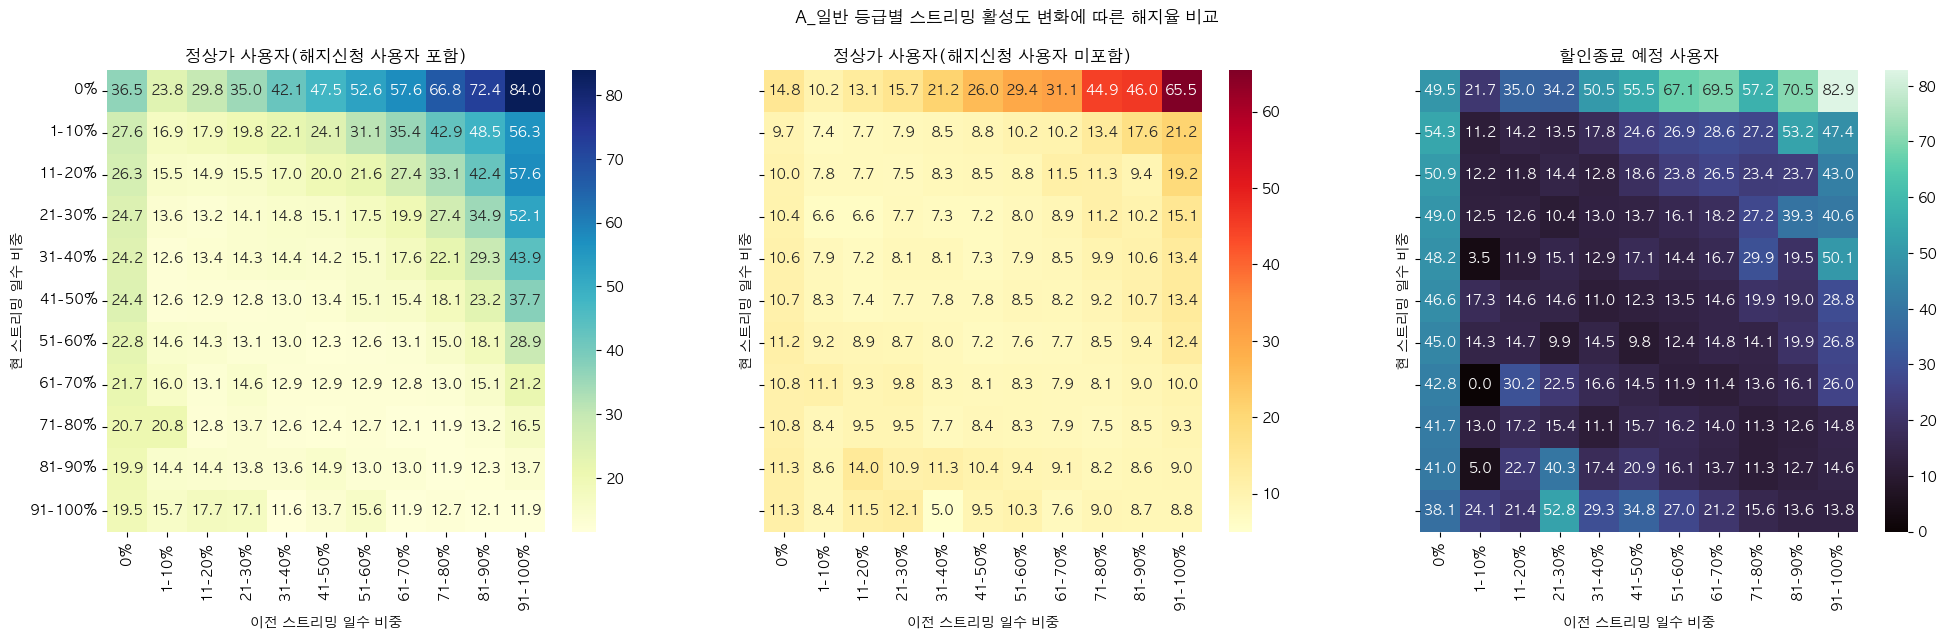

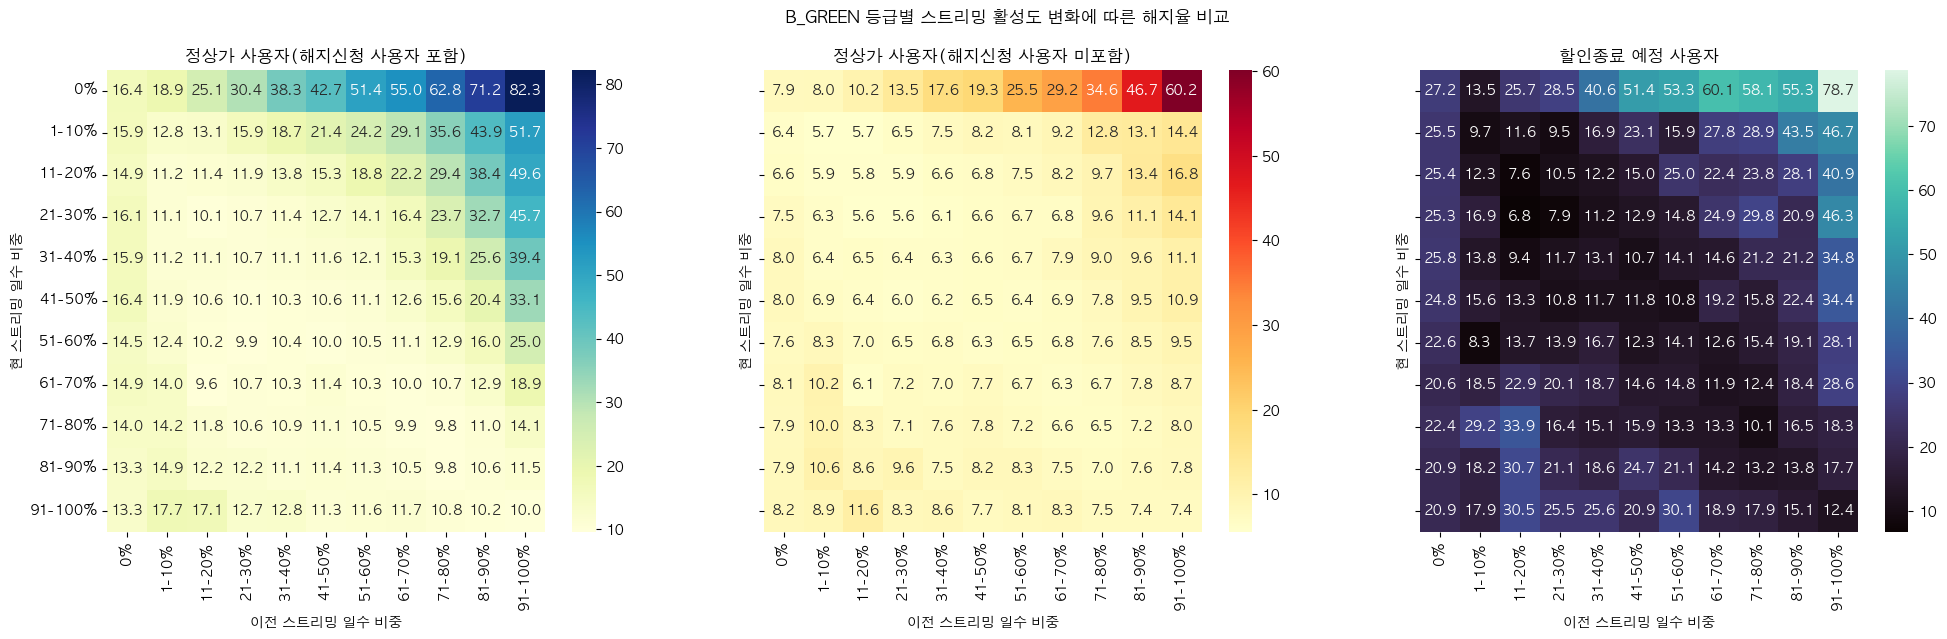

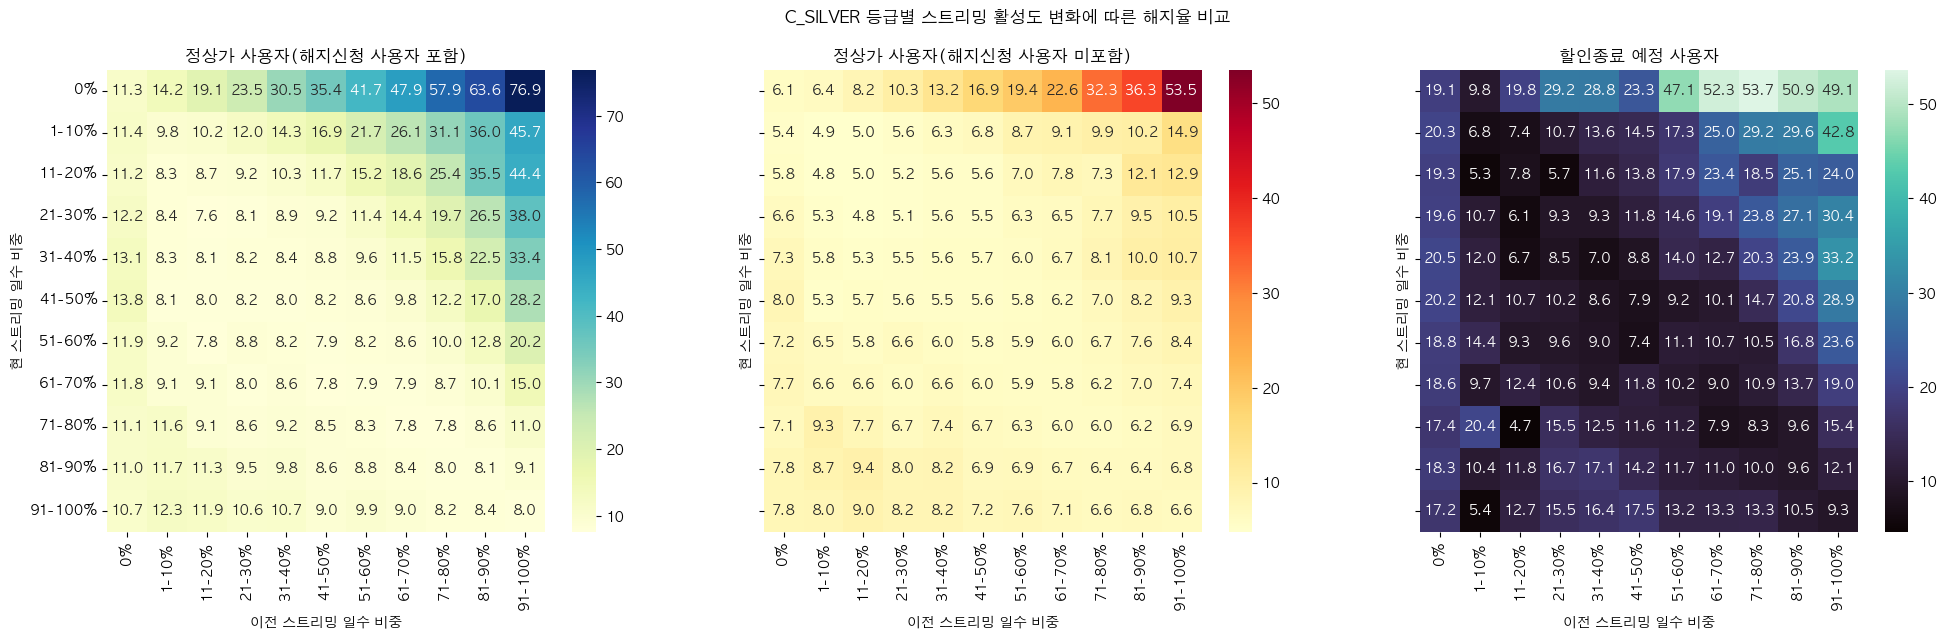

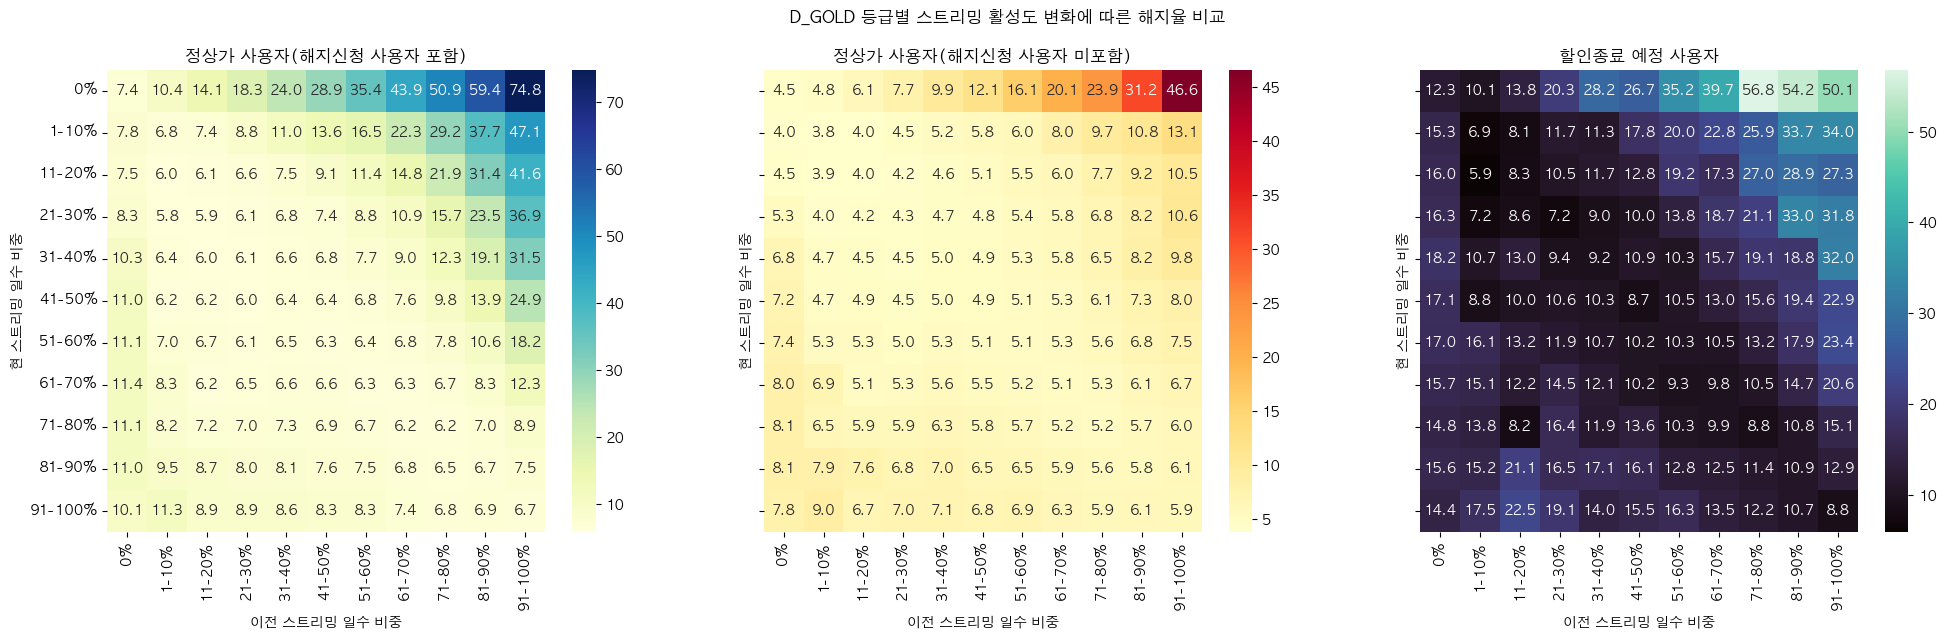

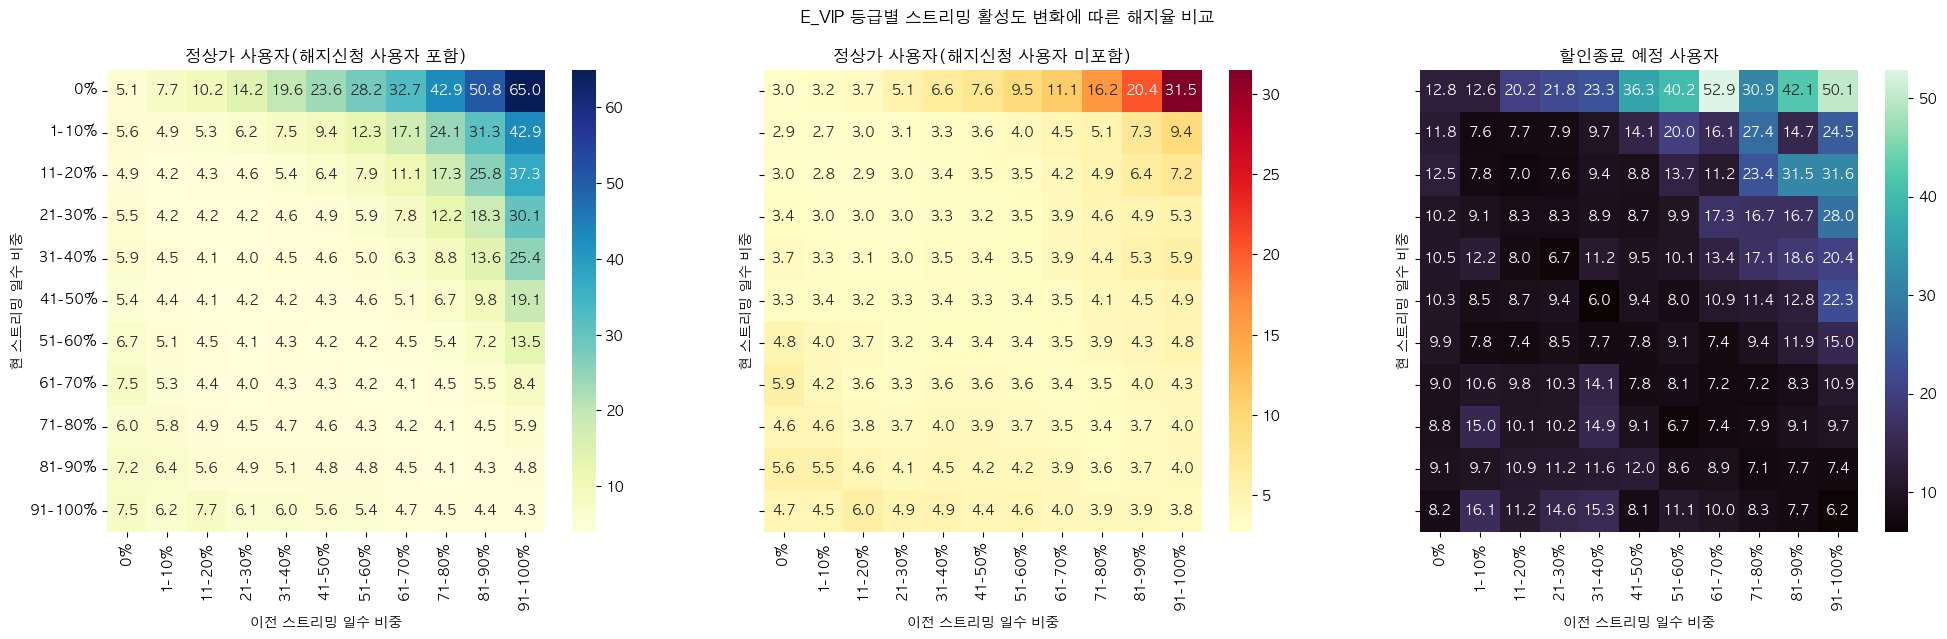

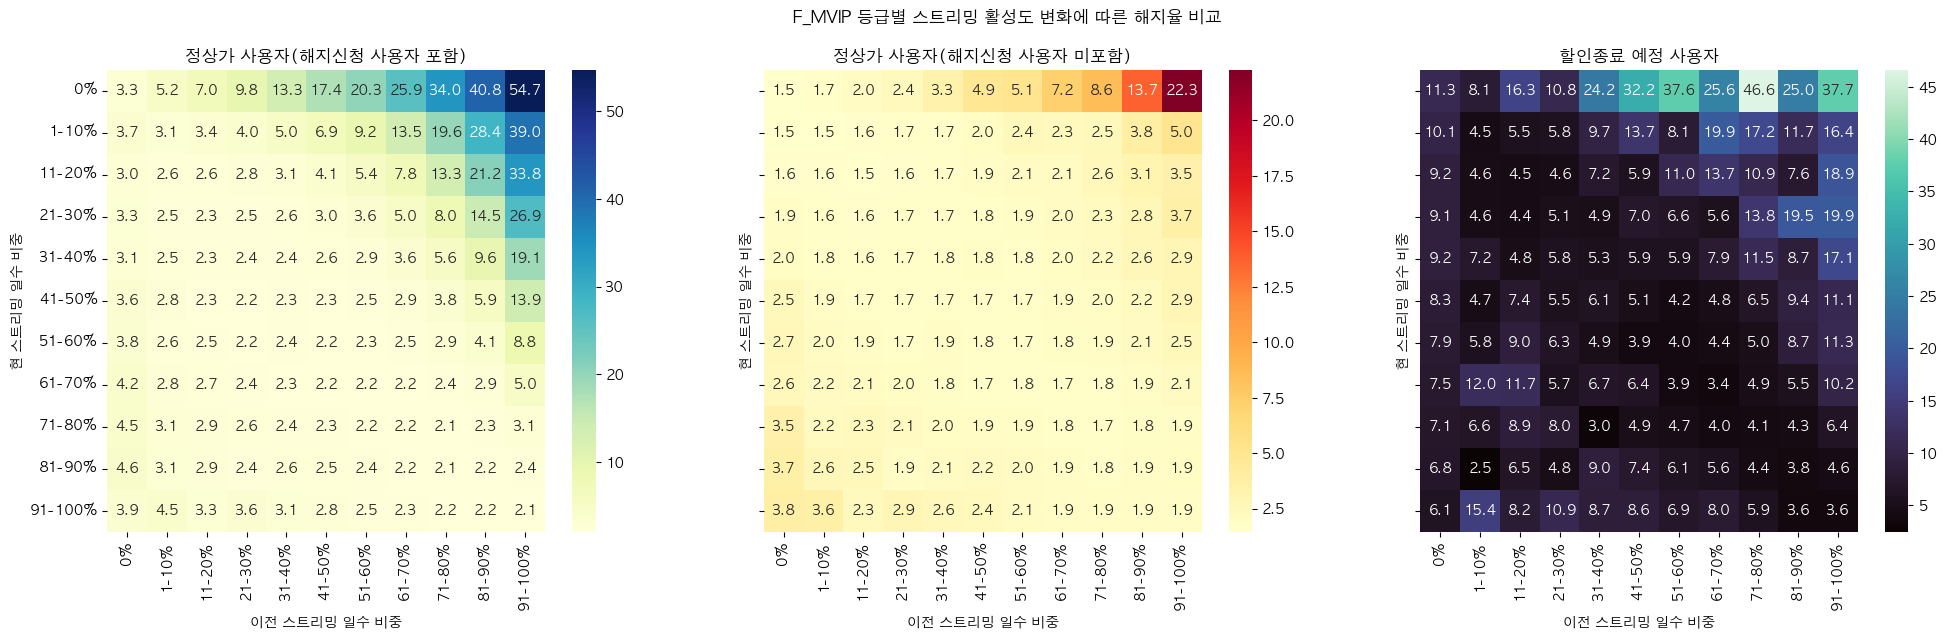

In [161]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 피벗테이블 생성 (정상가)
df1 = st_day_ratio_df.copy()
df1['ym'] = df1['ym'].astype(str)
df1 = df1[(df1['ym'] >= '202401') & (df1['ym'] <= '202504')]
pivot1 = pd.pivot_table(
    df1, values='out_user_ratio',
    index=['vip_grade_nm', 'st_day_ratio_group'],
    columns='pre_st_day_ratio',
    aggfunc='mean'
).round(2)

# 2. 피벗테이블 생성 (프로모션 종료 후)
df2 = promo_end_user_df.copy()
df2['ym'] = df2['ym'].astype(str)
df2 = df2[(df2['ym'] >= '202401') & (df2['ym'] <= '202504')]
pivot2 = pd.pivot_table(
    df2, values='out_user_ratio',
    index=['vip_grade_nm', 'st_day_ratio_group'],
    columns='pre_st_day_ratio',
    aggfunc='mean'
).round(2)

# 3. 피벗테이블 생성 (해지신청 미사용자 + 정상가 사용자)
df3 = cncl_req_none_user_df.copy()
df3['ym'] = df3['ym'].astype(str)
df3 = df3[(df3['ym'] >= '202401') & (df3['ym'] <= '202504')]
pivot3 = pd.pivot_table(
    df3, values='out_user_ratio',
    index=['vip_grade_nm', 'st_day_ratio_group'],
    columns='pre_st_day_ratio',
    aggfunc='mean'
).round(2)


# 4. 등급별 Heatmap 비교
for grade in df1['vip_grade_nm'].unique():
    fig, axes = plt.subplots(1, 3, figsize=(24,6), sharey=True)
    sns.heatmap(
        pivot1.loc[grade], annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0]
    )
    axes[0].set_title(f"정상가 사용자(해지신청 사용자 포함)")
    axes[0].set_ylabel("현 스트리밍 일수 비중")
    axes[0].set_xlabel("이전 스트리밍 일수 비중")
    sns.heatmap(
        pivot3.loc[grade], annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1]
    )
    axes[1].set_title(f"정상가 사용자(해지신청 사용자 미포함)")
    axes[1].set_xlabel("이전 스트리밍 일수 비중")
    axes[1].set_ylabel("현 스트리밍 일수 비중")
    sns.heatmap(
        pivot2.loc[grade], annot=True, fmt=".1f", cmap="mako", ax=axes[2]
    )
    axes[2].set_title(f"할인종료 예정 사용자")
    axes[2].set_xlabel("이전 스트리밍 일수 비중")
    axes[2].set_ylabel("현 스트리밍 일수 비중")
    plt.suptitle(f"{grade} 등급별 스트리밍 활성도 변화에 따른 해지율 비교")
    plt.show()

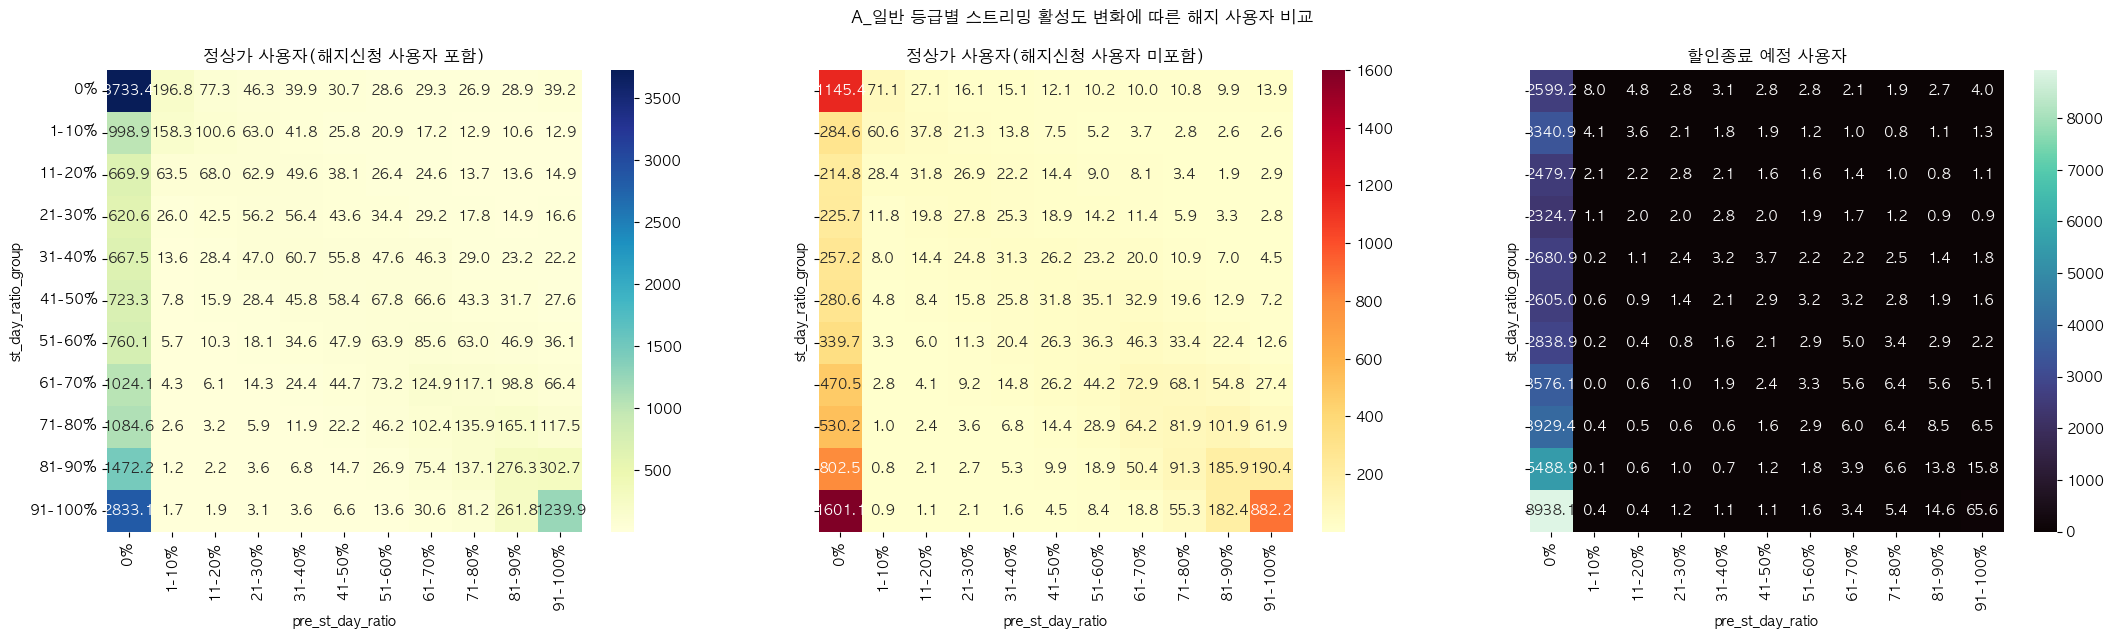

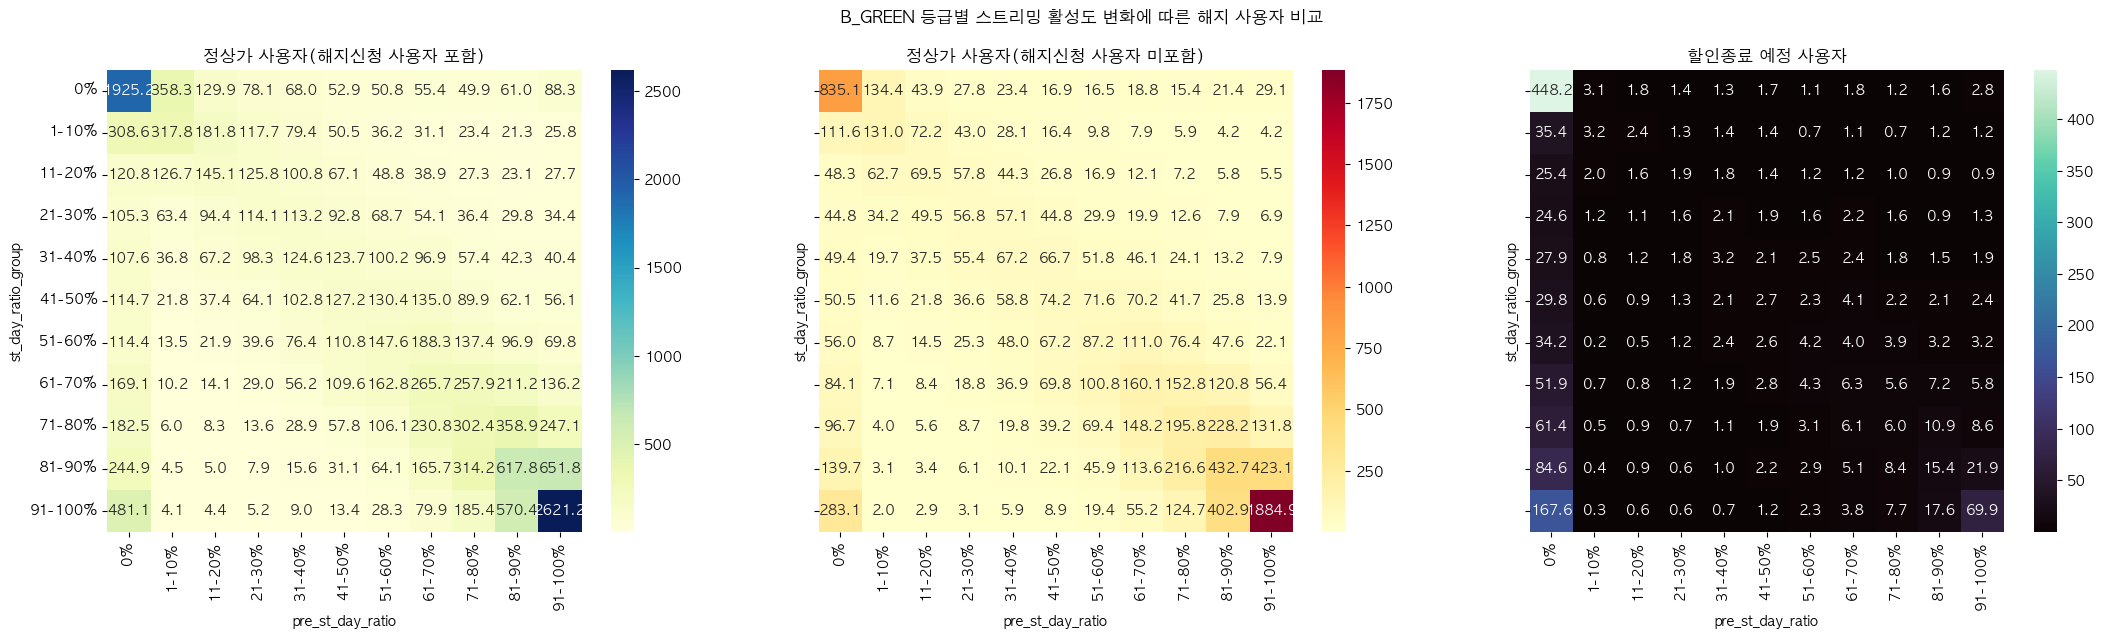

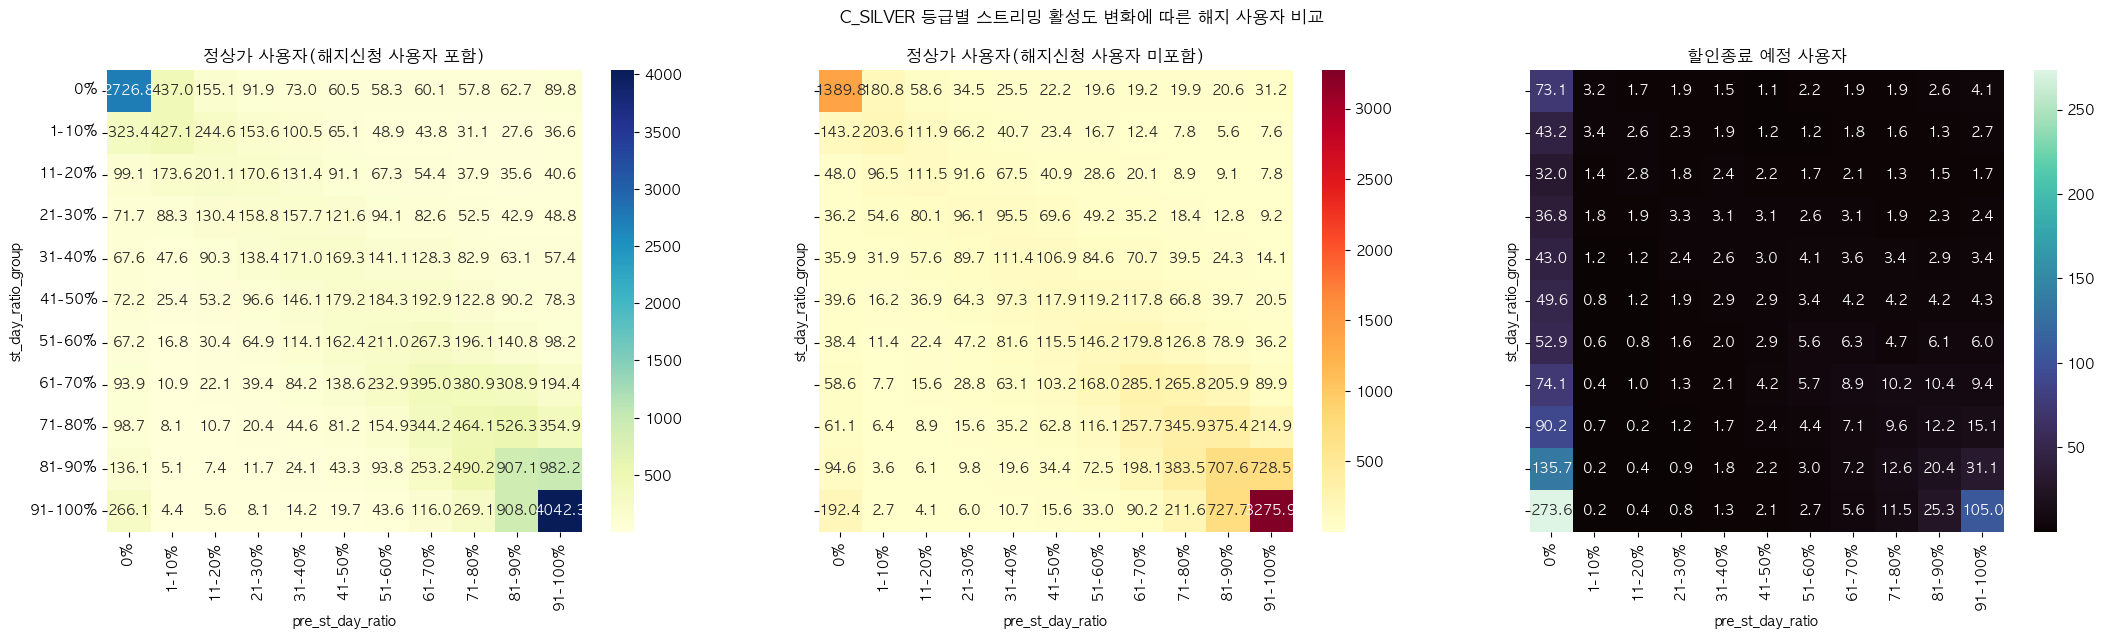

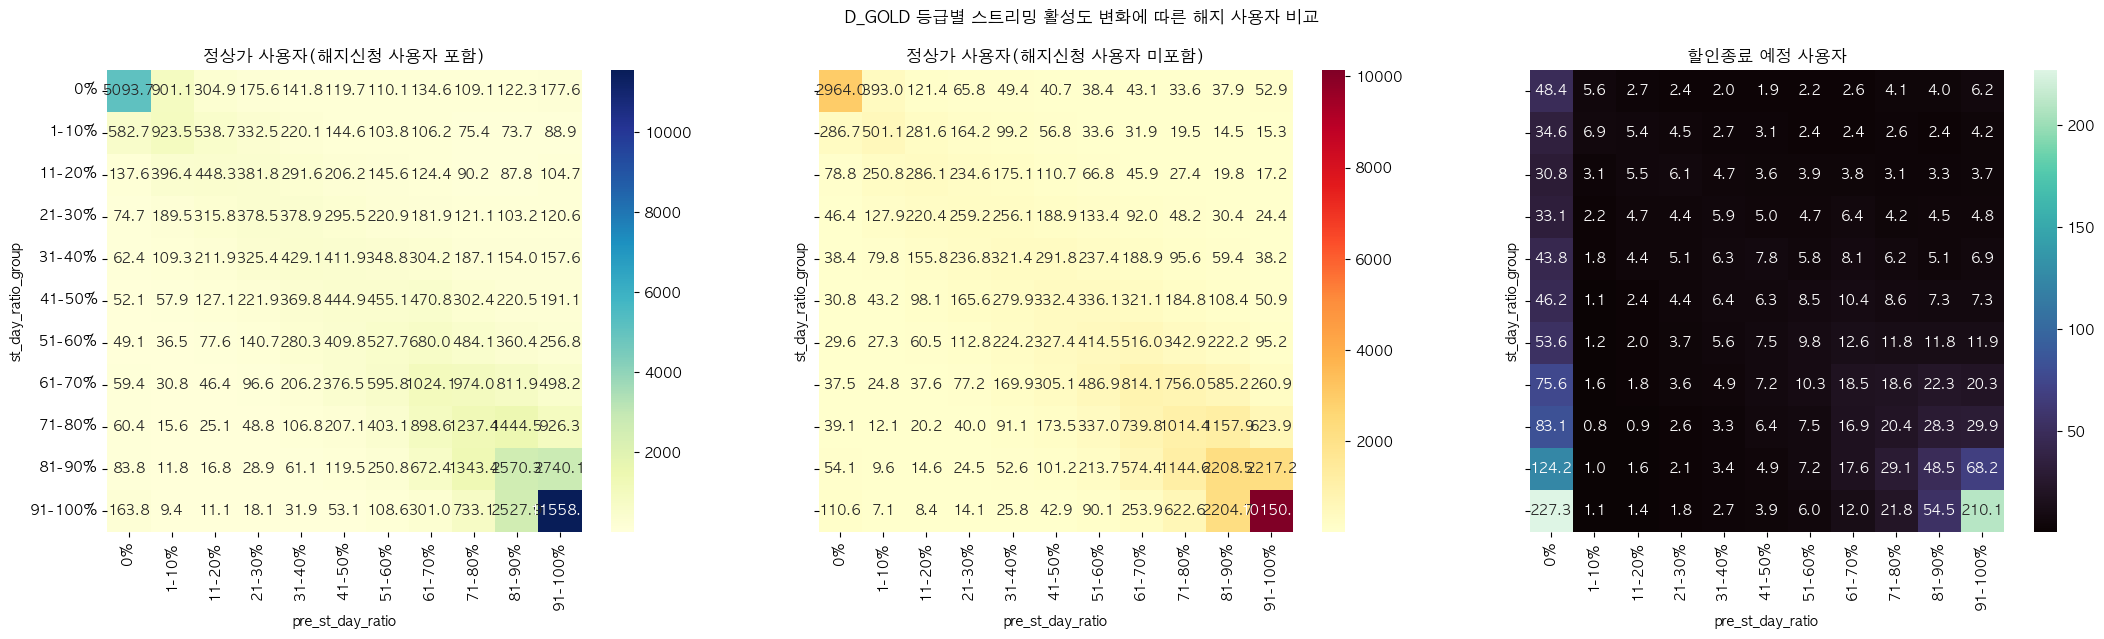

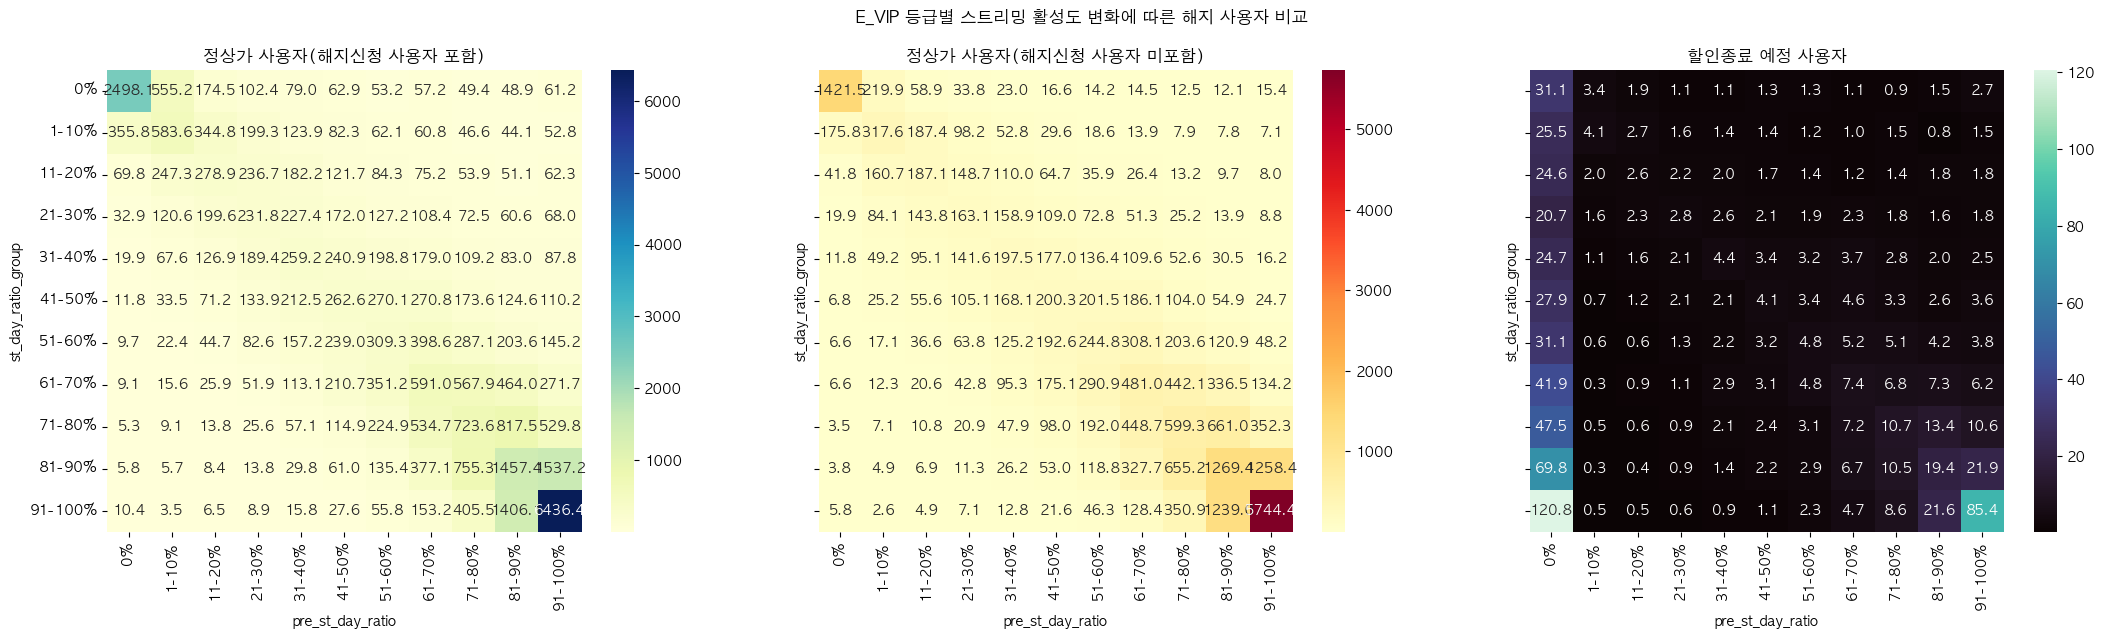

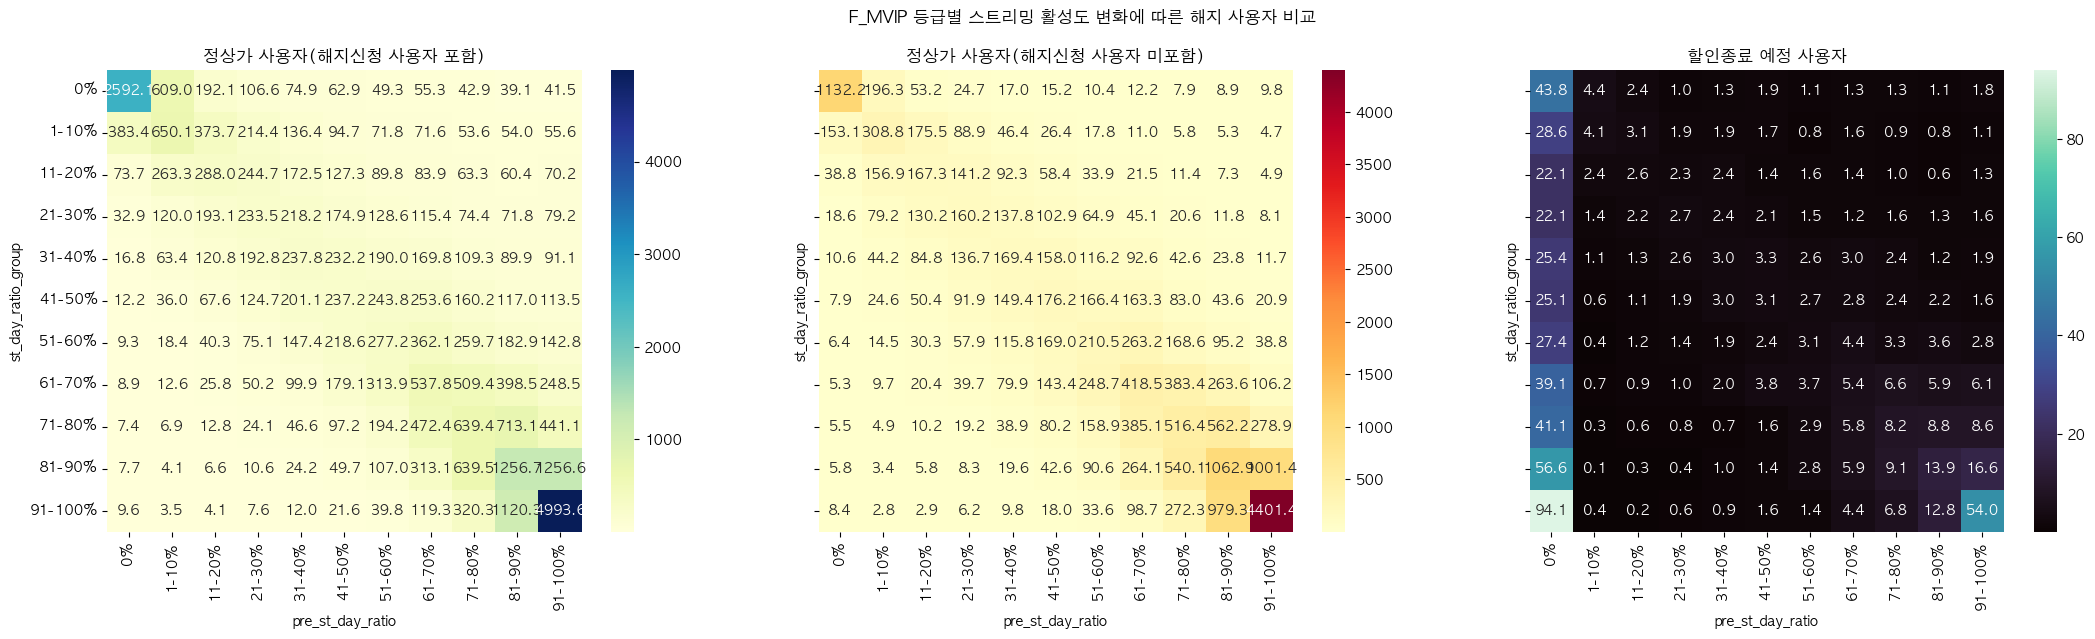

In [162]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 피벗테이블 생성 (정상가)
df1 = st_day_ratio_df.copy()
df1['ym'] = df1['ym'].astype(str)
df1 = df1[(df1['ym'] >= '202401') & (df1['ym'] <= '202504')]
pivot1 = pd.pivot_table(
    df1, values='out_user_cnt',
    index=['vip_grade_nm', 'st_day_ratio_group'],
    columns='pre_st_day_ratio',
    aggfunc='mean'
).round(2)

# 2. 피벗테이블 생성 (프로모션 종료 후)
df2 = promo_end_user_df.copy()
df2['ym'] = df2['ym'].astype(str)
df2 = df2[(df2['ym'] >= '202401') & (df2['ym'] <= '202504')]
pivot2 = pd.pivot_table(
    df2, values='out_user_cnt',
    index=['vip_grade_nm', 'st_day_ratio_group'],
    columns='pre_st_day_ratio',
    aggfunc='mean'
).round(2)

# 3. 피벗테이블 생성 (해지신청 미사용자 + 정상가 사용자)
df3 = cncl_req_none_user_df.copy()
df3['ym'] = df3['ym'].astype(str)
df3 = df3[(df3['ym'] >= '202401') & (df3['ym'] <= '202504')]
pivot3 = pd.pivot_table(
    df3, values='out_user_cnt',
    index=['vip_grade_nm', 'st_day_ratio_group'],
    columns='pre_st_day_ratio',
    aggfunc='mean'
).round(2)


# 4. 등급별 Heatmap 비교
for grade in df1['vip_grade_nm'].unique():
    fig, axes = plt.subplots(1, 3, figsize=(26,6), sharey=True)
    sns.heatmap(
        pivot1.loc[grade], annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[0]
    )
    axes[0].set_title(f"정상가 사용자(해지신청 사용자 포함)")
    sns.heatmap(
        pivot3.loc[grade], annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1]
    )
    axes[1].set_title(f"정상가 사용자(해지신청 사용자 미포함)")
    sns.heatmap(
        pivot2.loc[grade], annot=True, fmt=".1f", cmap="mako", ax=axes[2]
    )
    axes[2].set_title(f"할인종료 예정 사용자")
    plt.suptitle(f"{grade} 등급별 스트리밍 활성도 변화에 따른 해지 사용자 비교")
    plt.show()

### 5) 해지신청 상품과 이전 스트리밍 활동성 상관성

In [3]:
cncl_req_user_query = '''
select t1.buy_no_partition as ym
     , t1.vip_grade_nm     
     , t1.st_day_ratio_group
     , case
            when pre_st_day_ratio = 0 or pre_st_day_ratio is null then '0%'
            when pre_st_day_ratio < 11 then '1-10%'
            when pre_st_day_ratio < 21 then '11-20%'
            when pre_st_day_ratio < 31 then '21-30%'
            when pre_st_day_ratio < 41 then '31-40%'
            when pre_st_day_ratio < 51 then '41-50%'
            when pre_st_day_ratio < 61 then '51-60%'
            when pre_st_day_ratio < 71 then '61-70%'
            when pre_st_day_ratio < 81 then '71-80%'
            when pre_st_day_ratio < 91 then '81-90%'
            else '91-100%'
          end as pre_st_day_ratio     
    , count(distinct member_key) as user_cnt    
    , count(distinct if(out_yn = 'Y',member_key)) as out_user_cnt    
    , count(distinct if(out_yn = 'Y' and AUTO_BILL_STAUS_CODE = '1Q0300',member_key)) as cncl_req_user_cnt
    , round(cast(count(distinct if(out_yn = 'Y' and AUTO_BILL_STAUS_CODE = '1Q0300',member_key)) as double)/cast(count(distinct member_key) as double)*100,2) as cncl_req_user_ratio     
    , round(cast(count(distinct if(out_yn = 'Y' and AUTO_BILL_STAUS_CODE = '1Q0300',member_key)) as double)/cast(count(distinct if(out_yn = 'Y',member_key)) as double)*100,2) as cncl_req_user_ratio_by_out_user
    , count(distinct if(out_yn = 'N' and AUTO_BILL_STAUS_CODE = '1Q0100',member_key)) as cncl_req_cncl_user_cnt -- 해지신청 취소자
    , round(cast(count(distinct if(out_yn = 'N' and AUTO_BILL_STAUS_CODE = '1Q0100',member_key)) as double)/cast(count(distinct if(AUTO_BILL_STAUS_CODE is not null,member_key)) as double)*100,2) as cncl_req_cncl_user_ratio_by_cncl_req_user_cnt -- 해지신청 사용자중 해지신청 취소자 비중
from(
   select buy_no_partition
        , user_mkey as member_key
        , first_buy_no
        , buy_no
        , AUTO_BILL_STAUS_CODE
        , vld_strt_date
        , vip_grade_nm
        , st_day_ratio
        , case
            when st_day_ratio = 0 or st_day_ratio is null then '0%'
            when st_day_ratio < 11 then '1-10%'
            when st_day_ratio < 21 then '11-20%'
            when st_day_ratio < 31 then '21-30%'
            when st_day_ratio < 41 then '31-40%'
            when st_day_ratio < 51 then '41-50%'
            when st_day_ratio < 61 then '51-60%'
            when st_day_ratio < 71 then '61-70%'
            when st_day_ratio < 81 then '71-80%'
            when st_day_ratio < 91 then '81-90%'
            else '91-100%'
          end as st_day_ratio_group
        , out_yn
        , lag(st_day_ratio) over(partition by first_buy_no order by buy_date) as pre_st_day_ratio
        , st_day_ratio - lag(st_day_ratio) over(partition by first_buy_no order by buy_date) as diff_st_day_ratio
   from hadoop_kent.melon_sys_temp_production.samuel_prod_use_stat_dtl_tb
   where buy_no_partition between '202312' and '202504'
   and remain_offer_cnt = 0
   and normal_price_yn = 1
   and user_trgt_nm = '일반' --체리피커,B리스트 제외
) t1
left join(
   select buy_no_partition        
        , vip_grade_nm
        , case
            when st_day_ratio = 0 or st_day_ratio is null then '0%'
            when st_day_ratio < 11 then '1-10%'
            when st_day_ratio < 21 then '11-20%'
            when st_day_ratio < 31 then '21-30%'
            when st_day_ratio < 41 then '31-40%'
            when st_day_ratio < 51 then '41-50%'
            when st_day_ratio < 61 then '51-60%'
            when st_day_ratio < 71 then '61-70%'
            when st_day_ratio < 81 then '71-80%'
            when st_day_ratio < 91 then '81-90%'
            else '91-100%'
          end as st_day_ratio_group
        , count(distinct user_mkey) as tot_user_cnt
   from hadoop_kent.melon_sys_temp_production.samuel_prod_use_stat_dtl_tb
   where buy_no_partition between '202312' and '202504'
   and remain_offer_cnt = 0
   and normal_price_yn = 1
   and user_trgt_nm = '일반' --체리피커,B리스트 제외
   group by 1,2,3
) t2 on t1.buy_no_partition = t2.buy_no_partition and t1.vip_grade_nm = t2.vip_grade_nm and t1.st_day_ratio_group = t2.st_day_ratio_group
where t1.buy_no_partition <> '202312'
group by 1,2,3,4
order by 1,2,3,4
'''

cur.execute(cncl_req_user_query)

results = cur.fetchall()
colnames = [part[0] for part in cur.description]

cncl_req_user_df = pd.DataFrame(results, columns=colnames)

cur.cancel()
conn.close()
cncl_req_user_df.head()

,ym,vip_grade_nm,st_day_ratio_group,pre_st_day_ratio,user_cnt,out_user_cnt,cncl_req_user_cnt,cncl_req_user_ratio,cncl_req_user_ratio_by_out_user,cncl_req_cncl_user_cnt,cncl_req_cncl_user_ratio_by_cncl_req_user_cnt
0,202401,A_일반,0%,0%,17390,5481,3125,17.97,57.02,25,0.64
1,202401,A_일반,0%,1-10%,1553,413,251,16.16,60.77,0,0.00
2,202401,A_일반,0%,11-20%,514,164,106,20.62,64.63,1,0.79
3,202401,A_일반,0%,21-30%,255,104,51,20.00,49.04,0,0.00
4,202401,A_일반,0%,31-40%,206,92,40,19.42,43.48,0,0.00


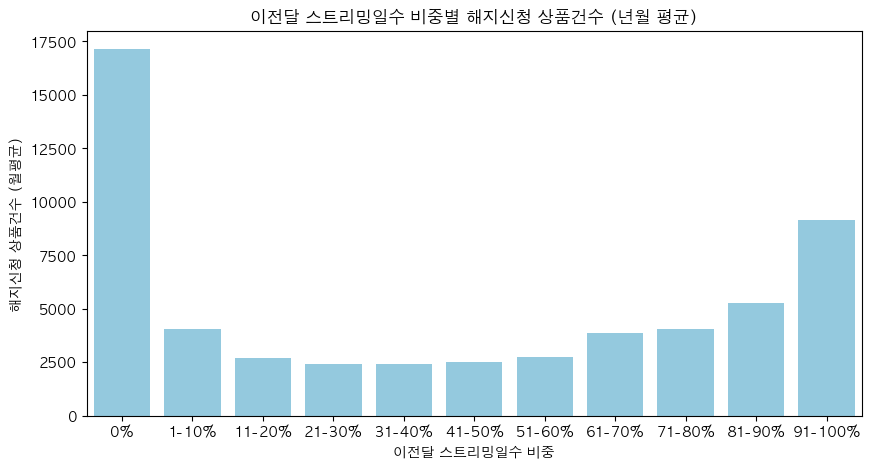

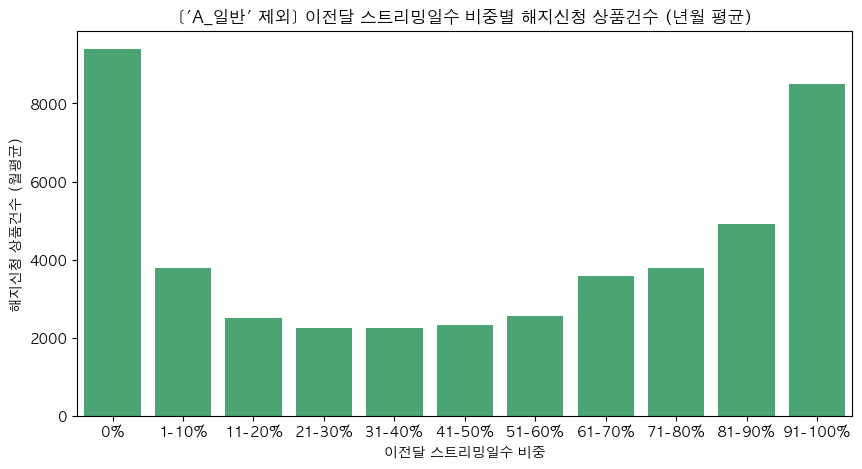

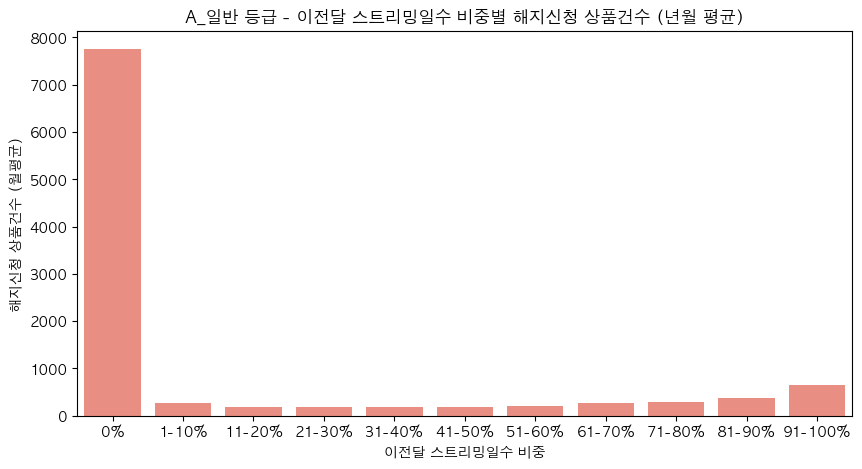

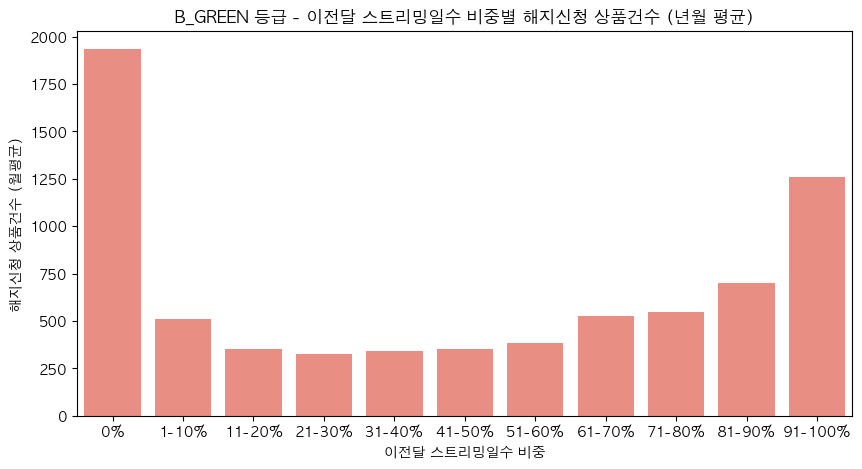

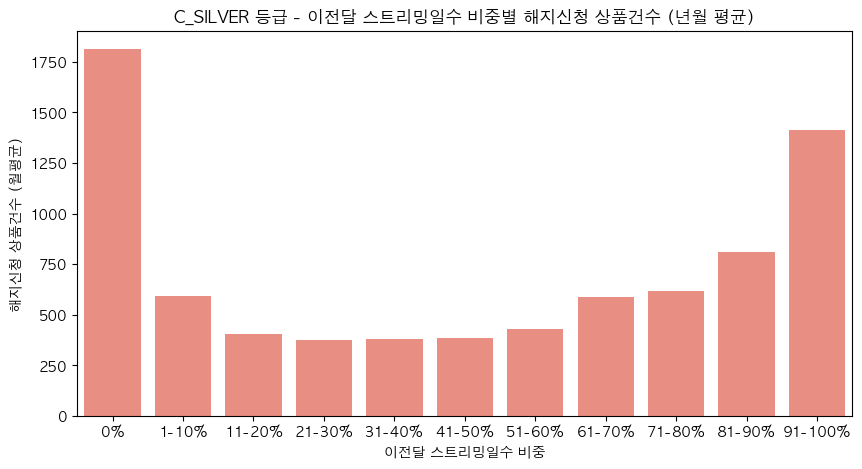

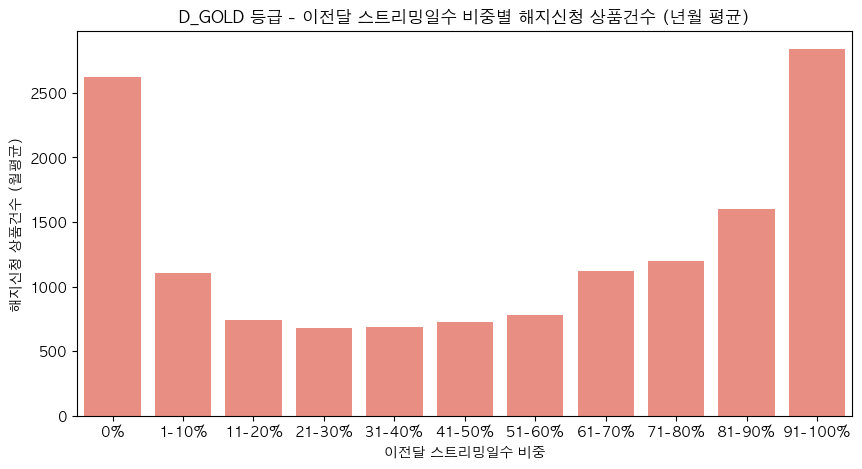

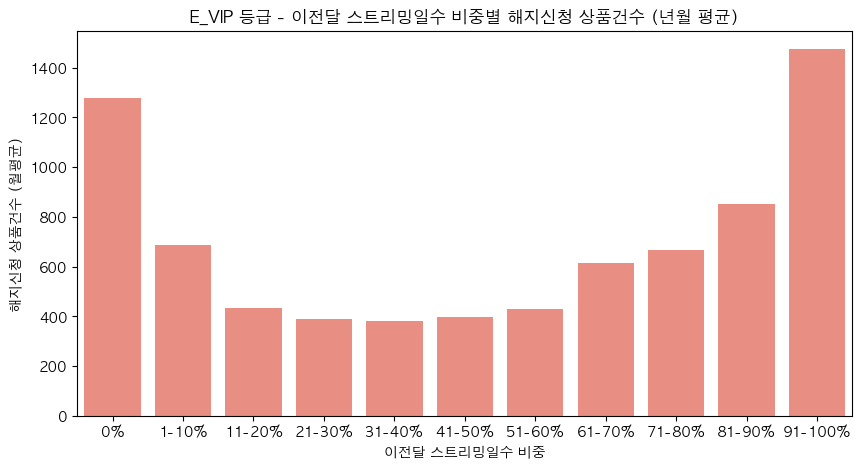

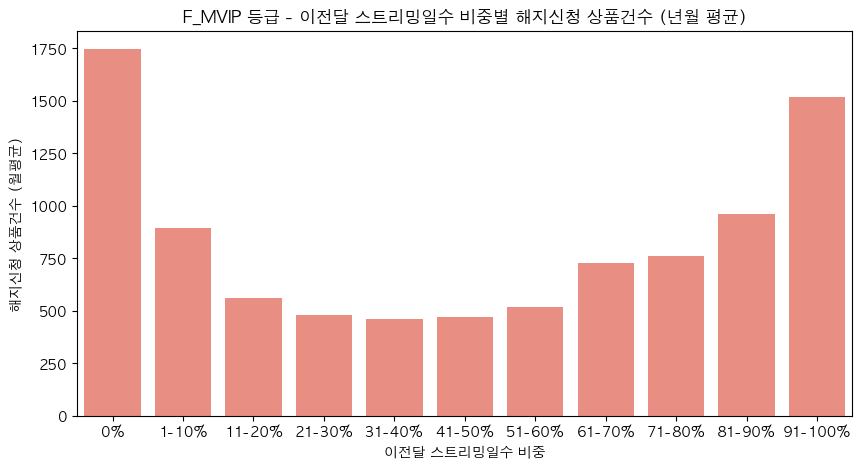

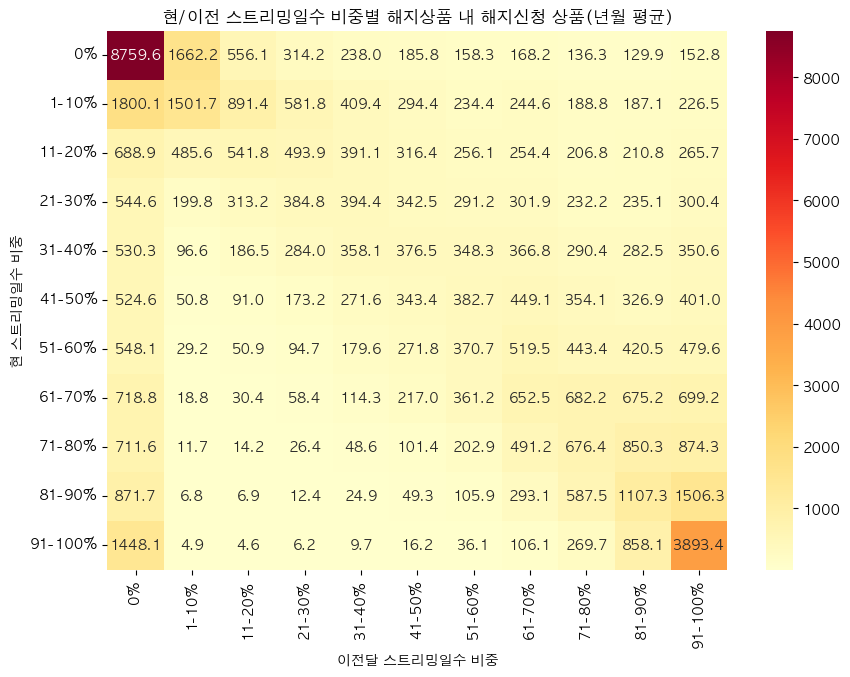

In [215]:
import matplotlib.pyplot as plt
import seaborn as sns

# (A) pre_st_day_ratio별 해지신청 상품건수 Bar Plot (년월별 평균)
monthly = cncl_req_user_df.groupby(['ym', 'pre_st_day_ratio'])['cncl_req_user_cnt'].sum().reset_index()
mean_by_pre = monthly.groupby('pre_st_day_ratio')['cncl_req_user_cnt'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(
    data=mean_by_pre,
    x='pre_st_day_ratio', y='cncl_req_user_cnt', color='skyblue'
)
plt.title('이전달 스트리밍일수 비중별 해지신청 상품건수 (년월 평균)')
plt.xlabel('이전달 스트리밍일수 비중')
plt.ylabel('해지신청 상품건수 (월평균)')
plt.show()

# (A-2) vip_grade_nm = 'A_일반' 제외한 Plot
filtered = cncl_req_user_df[cncl_req_user_df['vip_grade_nm'] != 'A_일반']
monthly_f = filtered.groupby(['ym', 'pre_st_day_ratio'])['cncl_req_user_cnt'].sum().reset_index()
mean_by_pre_f = monthly_f.groupby('pre_st_day_ratio')['cncl_req_user_cnt'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(
    data=mean_by_pre_f,
    x='pre_st_day_ratio', y='cncl_req_user_cnt', color='mediumseagreen'
)
plt.title("['A_일반' 제외] 이전달 스트리밍일수 비중별 해지신청 상품건수 (년월 평균)")
plt.xlabel('이전달 스트리밍일수 비중')
plt.ylabel('해지신청 상품건수 (월평균)')
plt.show()

# (B) 등급별로 보고 싶으면 (년월별 평균)
for grade in cncl_req_user_df['vip_grade_nm'].unique():
    sub = cncl_req_user_df[cncl_req_user_df['vip_grade_nm'] == grade]
    monthly = sub.groupby(['ym', 'pre_st_day_ratio'])['cncl_req_user_cnt'].sum().reset_index()
    mean_by_pre = monthly.groupby('pre_st_day_ratio')['cncl_req_user_cnt'].mean().reset_index()
    plt.figure(figsize=(10,5))
    sns.barplot(
        data=mean_by_pre,
        x='pre_st_day_ratio', y='cncl_req_user_cnt', color='salmon'
    )
    plt.title(f'{grade} 등급 - 이전달 스트리밍일수 비중별 해지신청 상품건수 (년월 평균)')
    plt.xlabel('이전달 스트리밍일수 비중')
    plt.ylabel('해지신청 상품건수 (월평균)')
    plt.show()

# (C) heatmap (현/이전 스트리밍일수 비중별 해지신청 상품건수, 년월별 평균)
pivot = cncl_req_user_df.groupby(['ym', 'st_day_ratio_group', 'pre_st_day_ratio'])['cncl_req_user_cnt'].sum().reset_index()
pivot_mean = pivot.groupby(['st_day_ratio_group', 'pre_st_day_ratio'])['cncl_req_user_cnt'].mean().unstack()
plt.figure(figsize=(10,7))
sns.heatmap(pivot_mean, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title('현/이전 스트리밍일수 비중별 해지상품 내 해지신청 상품(년월 평균)')
plt.xlabel('이전달 스트리밍일수 비중')
plt.ylabel('현 스트리밍일수 비중')
plt.show()

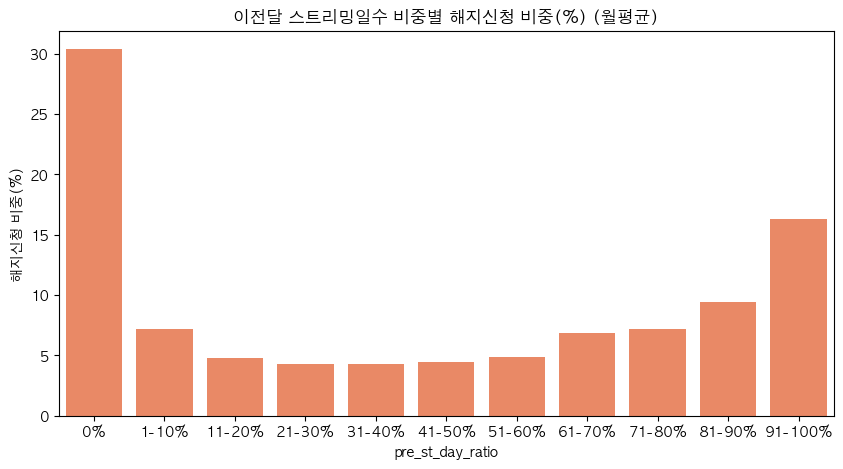

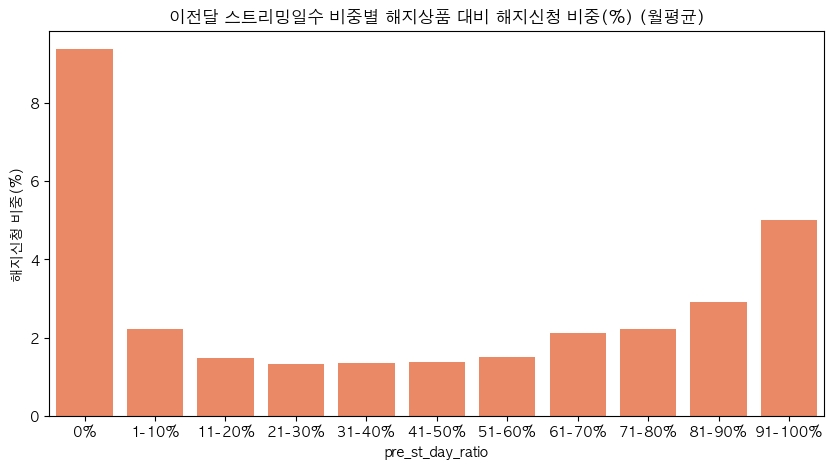

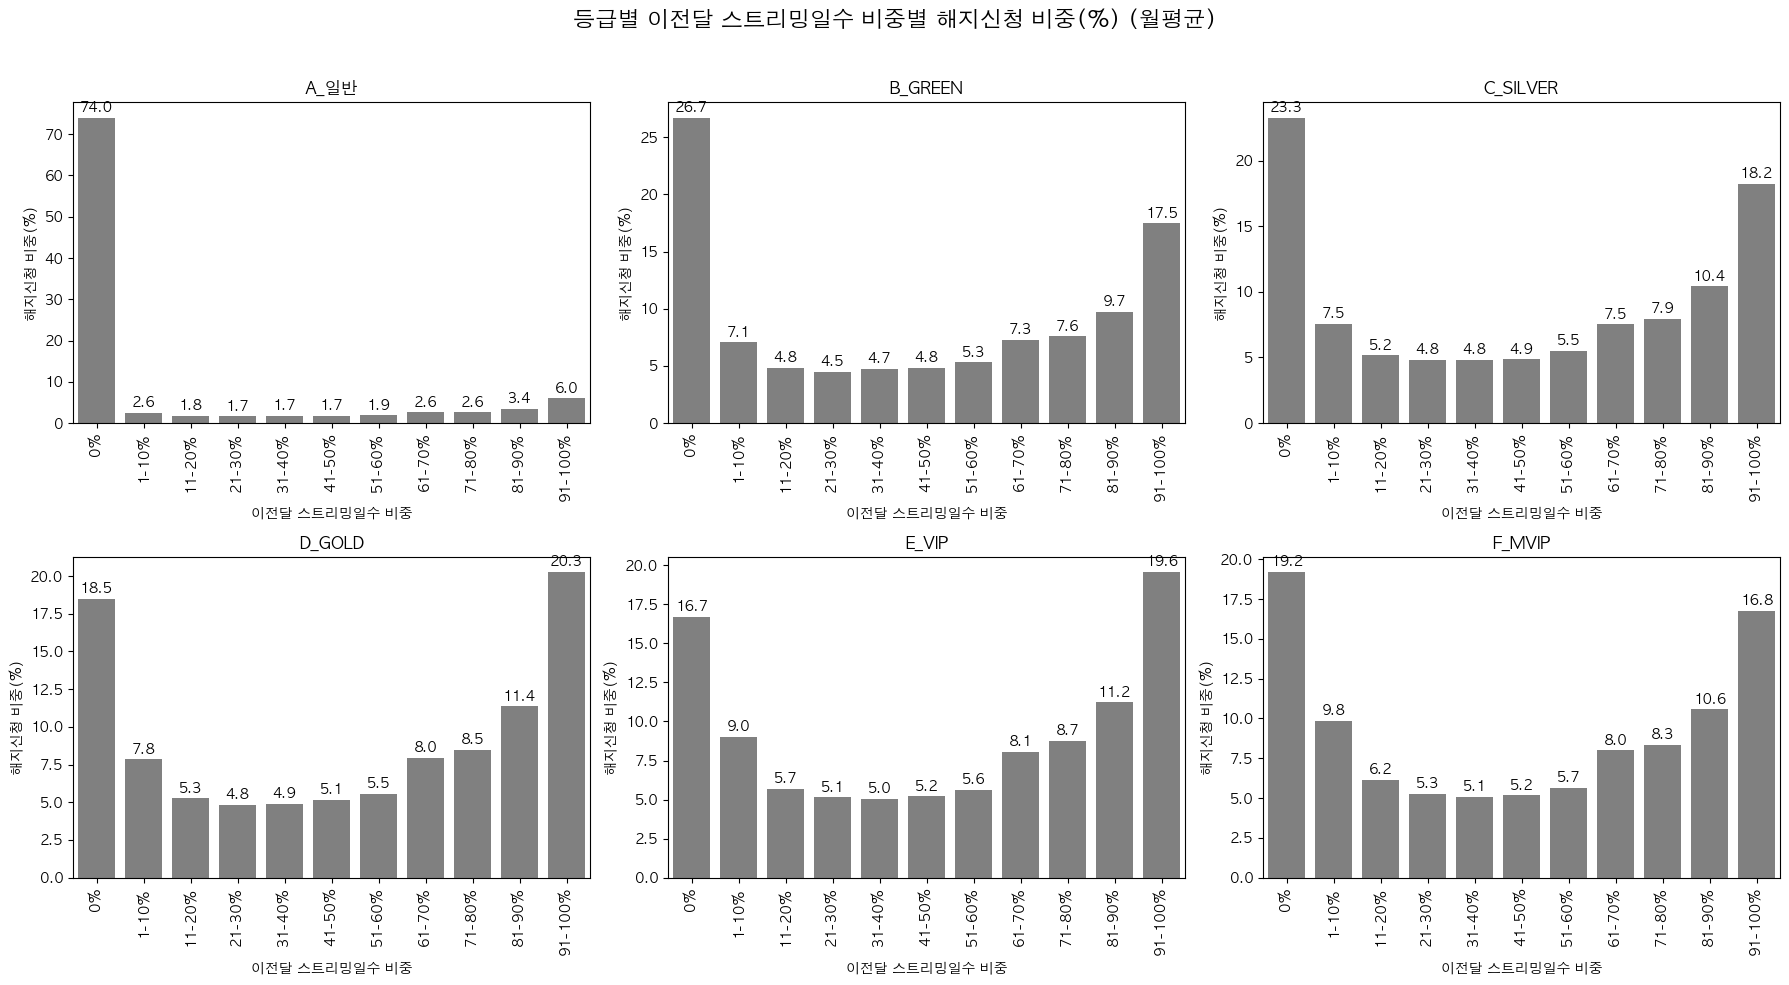

In [190]:

# 1. pre_st_day_ratio별 해지신청 비중(전체 대비)
total = cncl_req_user_df.groupby(['ym'])['cncl_req_user_cnt'].sum().reset_index().rename(columns={'cncl_req_user_cnt':'total_cnt'})
monthly = cncl_req_user_df.groupby(['ym', 'pre_st_day_ratio'])['cncl_req_user_cnt'].sum().reset_index()
monthly = monthly.merge(total, on='ym')
monthly['ratio'] = monthly['cncl_req_user_cnt'] / monthly['total_cnt'] * 100
mean_ratio = monthly.groupby('pre_st_day_ratio')['ratio'].mean().reset_index()
plt.figure(figsize=(10,5))
sns.barplot(data=mean_ratio, x='pre_st_day_ratio', y='ratio', color='coral')
plt.title('이전달 스트리밍일수 비중별 해지신청 비중(%) (월평균)')
plt.ylabel('해지신청 비중(%)')
plt.show()


# 1-1. pre_st_day_ratio별 해지신청 비중(해지상품 대비)
total = cncl_req_user_df.groupby(['ym'])['out_user_cnt'].sum().reset_index().rename(columns={'out_user_cnt':'total_cnt'})
monthly = cncl_req_user_df.groupby(['ym', 'pre_st_day_ratio'])['cncl_req_user_cnt'].sum().reset_index()
monthly = monthly.merge(total, on='ym')
monthly['ratio'] = monthly['cncl_req_user_cnt'] / monthly['total_cnt'] * 100
mean_ratio = monthly.groupby('pre_st_day_ratio')['ratio'].mean().reset_index()
plt.figure(figsize=(10,5))
sns.barplot(data=mean_ratio, x='pre_st_day_ratio', y='ratio', color='coral')
plt.title('이전달 스트리밍일수 비중별 해지상품 대비 해지신청 비중(%) (월평균)')
plt.ylabel('해지신청 비중(%)')
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns

# 2. 등급별 pre_st_day_ratio별 해지신청 비중(전체 대비) 2*3 subplot, fill 색상은 grey, y축 scale free, bar 위에 평균값 라벨링
grades = cncl_req_user_df['vip_grade_nm'].unique()
n = len(grades)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 10), sharey=False)
axes = axes.flatten()

for i, grade in enumerate(grades):
    sub = cncl_req_user_df[cncl_req_user_df['vip_grade_nm'] == grade]
    total = sub.groupby(['ym'])['cncl_req_user_cnt'].sum().reset_index().rename(columns={'cncl_req_user_cnt':'total_cnt'})
    monthly = sub.groupby(['ym', 'pre_st_day_ratio'])['cncl_req_user_cnt'].sum().reset_index()
    monthly = monthly.merge(total, on='ym')
    monthly['ratio'] = monthly['cncl_req_user_cnt'] / monthly['total_cnt'] * 100
    mean_ratio = monthly.groupby('pre_st_day_ratio')['ratio'].mean().reset_index()
    ax = axes[i]
    bar = sns.barplot(data=mean_ratio, x='pre_st_day_ratio', y='ratio', color='grey', ax=ax)
    ax.set_title(f"{grade}")
    ax.set_xlabel('이전달 스트리밍일수 비중')
    ax.set_ylabel('해지신청 비중(%)')
    ax.tick_params(axis='x', rotation=90)
    # bar 위에 평균값 라벨링
    for p in ax.patches:
        height = p.get_height()
        if not pd.isna(height):
            ax.annotate(f'{height:.1f}', 
                        (p.get_x() + p.get_width() / 2., height), 
                        ha='center', va='bottom', fontsize=10, color='black', rotation=0, xytext=(0,2), textcoords='offset points')

# 빈 subplot 숨기기
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('등급별 이전달 스트리밍일수 비중별 해지신청 비중(%) (월평균)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [196]:
cncl_req_user_df.groupby([ 'vip_grade_nm', 'pre_st_day_ratio', 'st_day_ratio_group'])['cncl_req_cncl_user_ratio_by_cncl_req_user_cnt'].mean().reset_index().describe()

,cncl_req_cncl_user_ratio_by_cncl_req_user_cnt
count,726.000000
mean,7.182899
std,7.861804
min,0.000000
25%,1.856562
50%,5.225179
75%,10.617188
max,69.985000


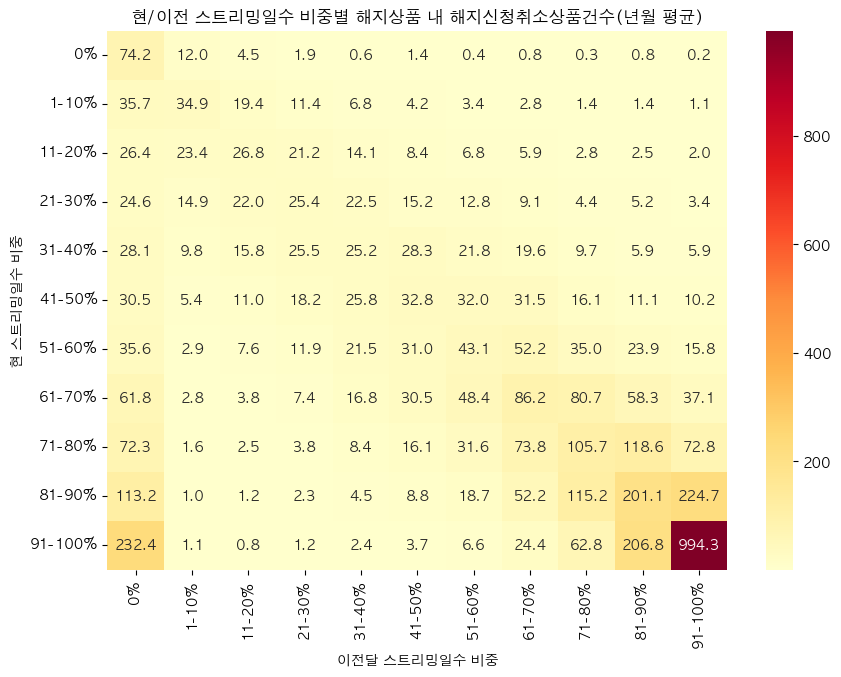

In [212]:
pivot = cncl_req_user_df.groupby(['ym', 'st_day_ratio_group', 'pre_st_day_ratio'])['cncl_req_cncl_user_cnt'].sum().reset_index()
pivot_mean = pivot.groupby(['st_day_ratio_group', 'pre_st_day_ratio'])['cncl_req_cncl_user_cnt'].mean().unstack()
plt.figure(figsize=(10,7))
sns.heatmap(pivot_mean, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title('현/이전 스트리밍일수 비중별 해지상품 내 해지신청취소상품건수(년월 평균)')
plt.xlabel('이전달 스트리밍일수 비중')
plt.ylabel('현 스트리밍일수 비중')
plt.show()



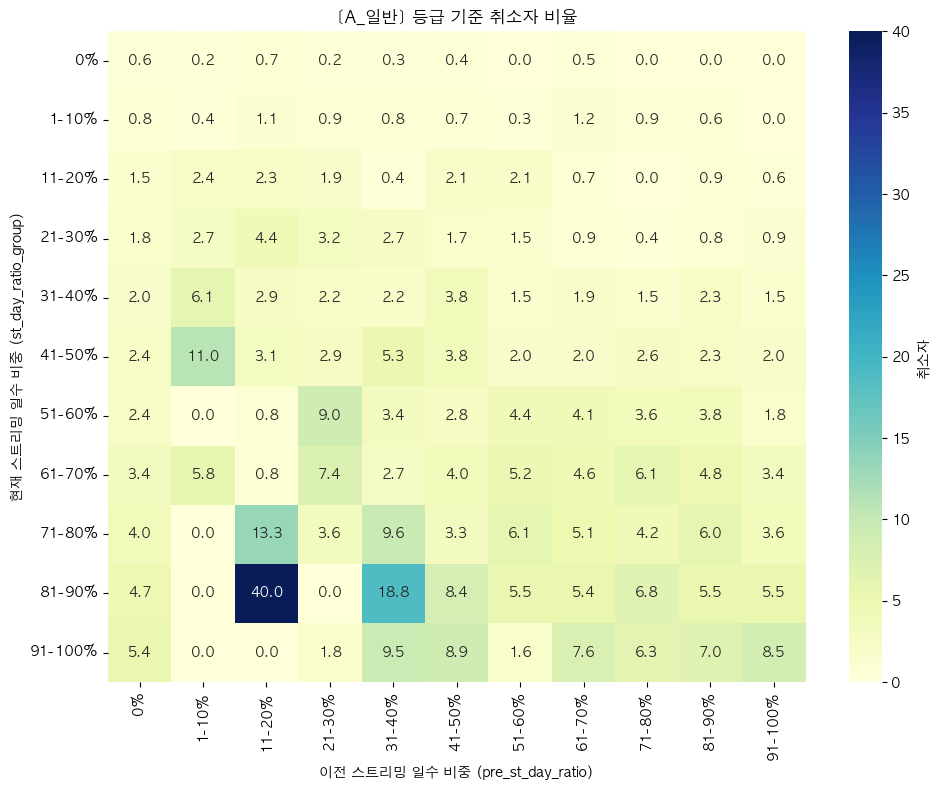

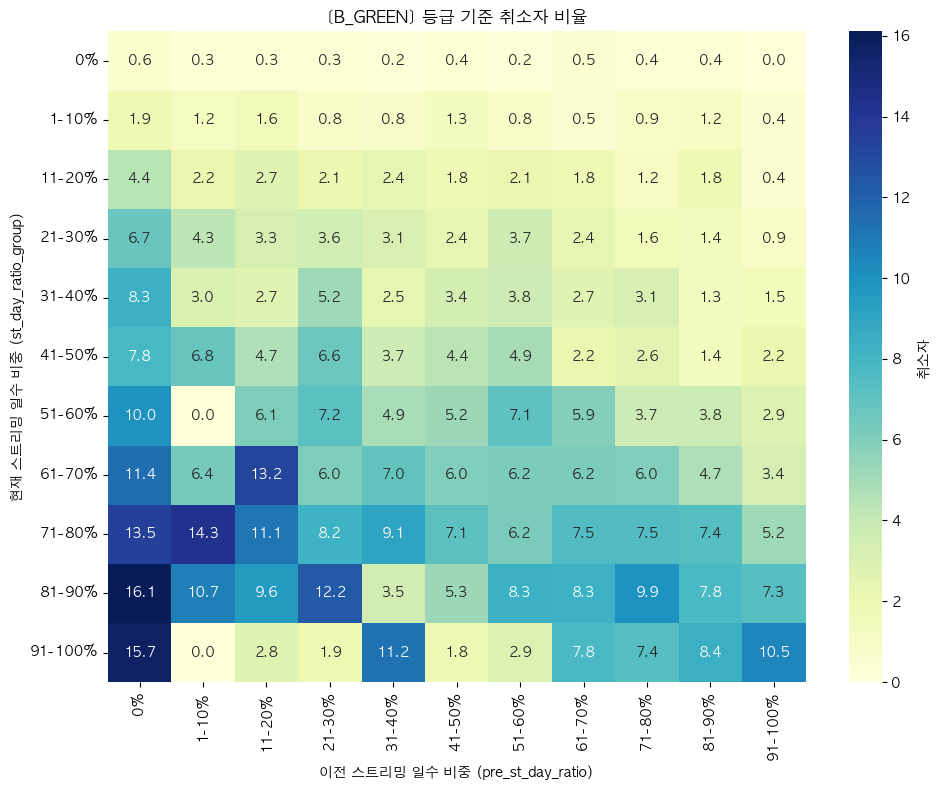

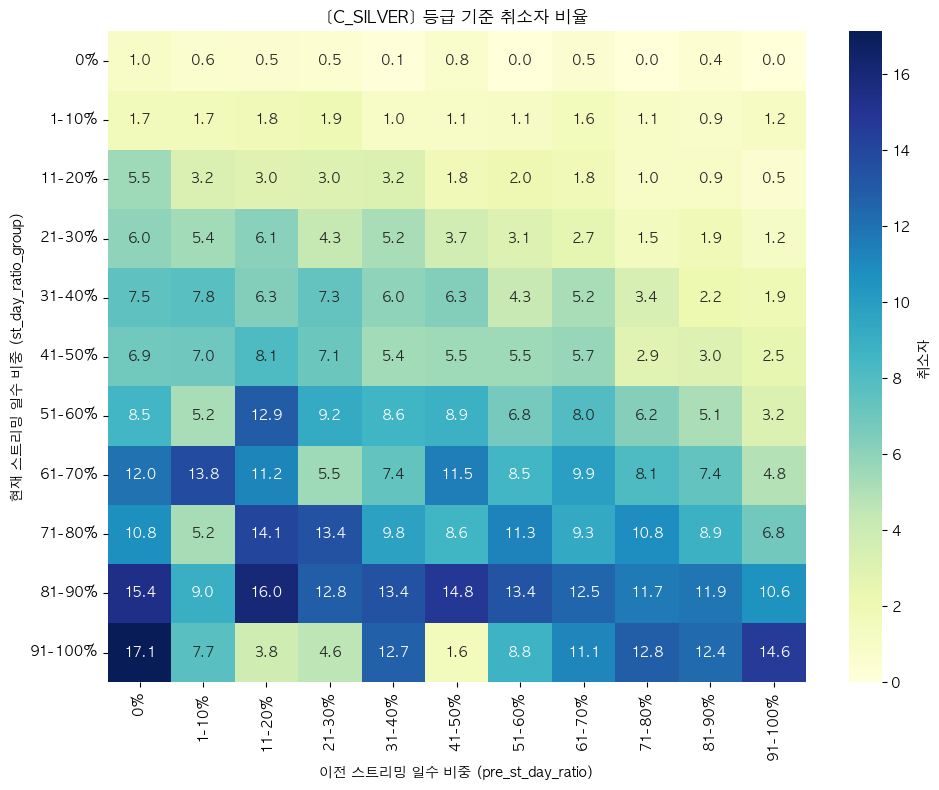

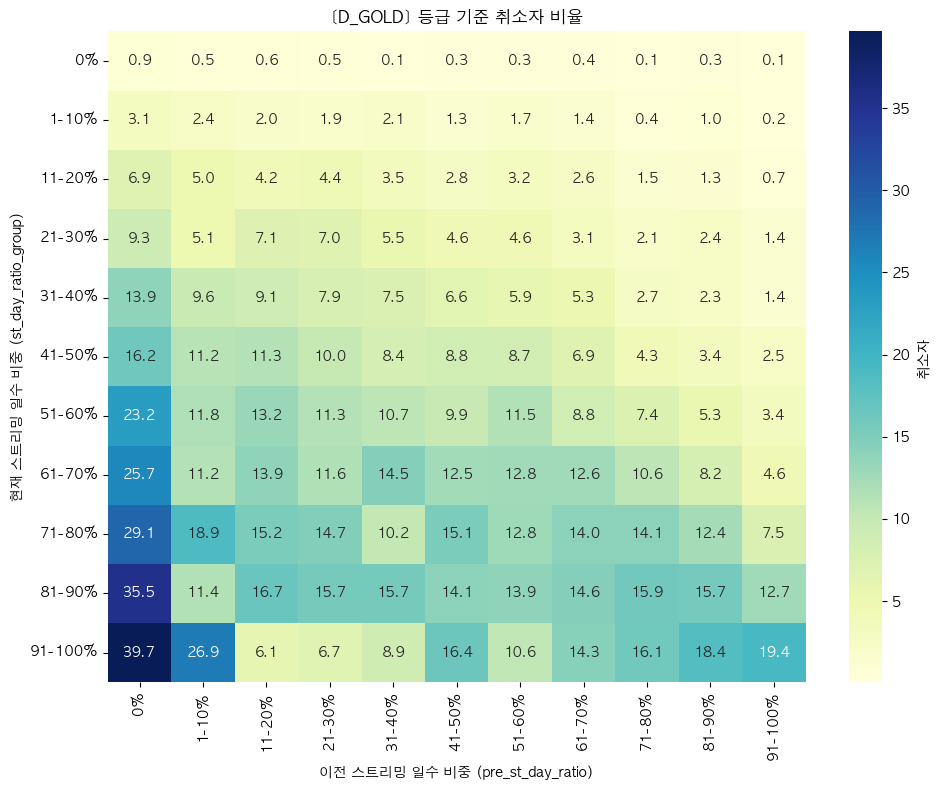

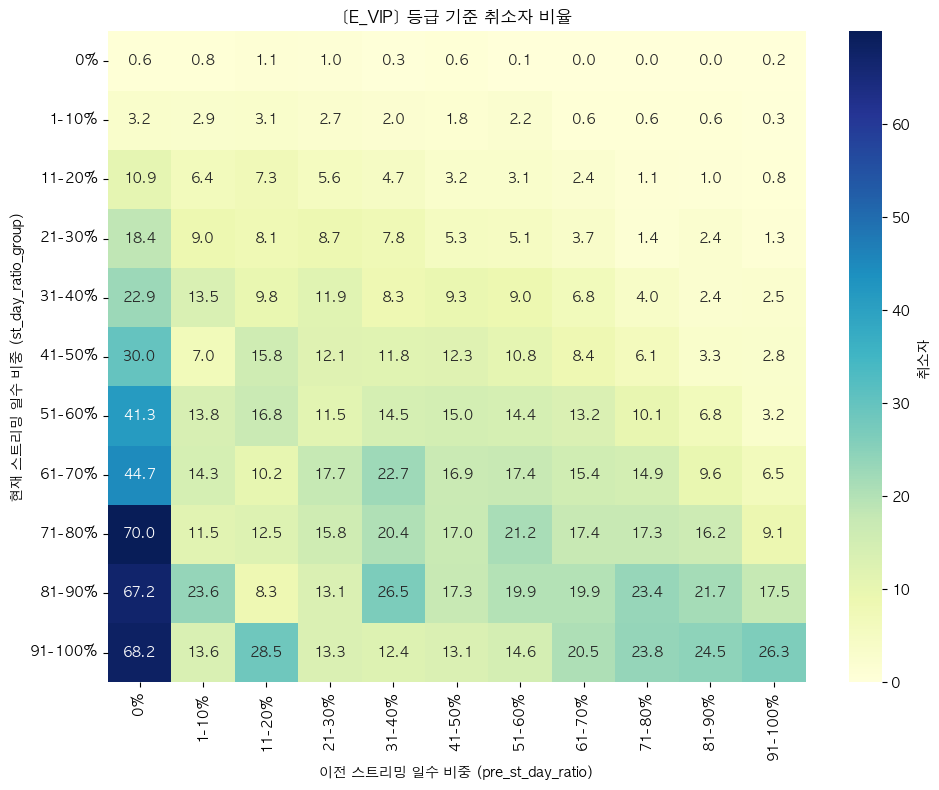

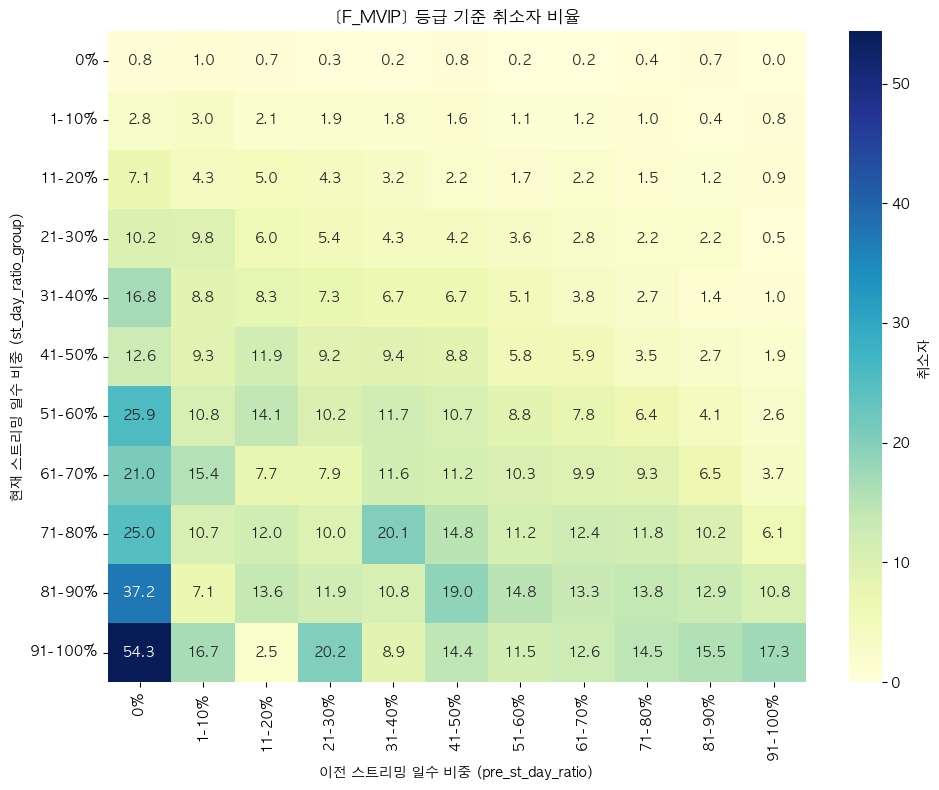

In [211]:
# 피벗 테이블용 데이터 집계
pivot_df = cncl_req_user_df.groupby([ 'vip_grade_nm', 'pre_st_day_ratio', 'st_day_ratio_group'])['cncl_req_cncl_user_ratio_by_cncl_req_user_cnt'].mean().reset_index()

# 등급별로 히트맵 시각화
unique_grades = cncl_req_user_df['vip_grade_nm'].unique()

for grade in unique_grades:
    filtered_df = pivot_df[pivot_df['vip_grade_nm'] == grade]

    # 2D 피벗 테이블로 변환
    heatmap_df = filtered_df.pivot_table(
        index='st_day_ratio_group',
        columns='pre_st_day_ratio',
        values='cncl_req_cncl_user_ratio_by_cncl_req_user_cnt'
    )

    # 히트맵 그리기
    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_df, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': '취소자'})
    plt.title(f"[{grade}] 등급 기준 취소자 비율")
    plt.ylabel("현재 스트리밍 일수 비중 (st_day_ratio_group)")
    plt.xlabel("이전 스트리밍 일수 비중 (pre_st_day_ratio)")
    plt.tight_layout()
    plt.show()

In [4]:
# pre_st_day_ratio를 숫자형으로 변환
pre_map = {'0%':0, '1-10%':5, '11-20%':15, '21-30%':25, '31-40%':35, '41-50%':45, '51-60%':55, '61-70%':65, '71-80%':75, '81-90%':85, '91-100%':95}
df = cncl_req_user_df.copy()
df = df[df['pre_st_day_ratio'].notnull() & df['cncl_req_user_ratio'].notnull()]
df['pre_st_day_ratio_num'] = df['pre_st_day_ratio'].map(pre_map)

# 전체 상관계수
corr = df[['pre_st_day_ratio_num', 'cncl_req_user_ratio']].corr().iloc[0,1]
print(f"전체 상관계수: {corr:.3f}")

# 등급별 상관계수
for grade in df['vip_grade_nm'].unique():
    sub = df[df['vip_grade_nm']==grade]
    c = sub[['pre_st_day_ratio_num', 'cncl_req_user_ratio']].corr().iloc[0,1]
    print(f"{grade} 등급 상관계수: {c:.3f}")

전체 상관계수: 0.410
A_일반 등급 상관계수: 0.338
B_GREEN 등급 상관계수: 0.429
C_SILVER 등급 상관계수: 0.457
D_GOLD 등급 상관계수: 0.478
E_VIP 등급 상관계수: 0.474
F_MVIP 등급 상관계수: 0.461


In [13]:
pre_map = {'0%':0, '1-10%':5, '11-20%':15, '21-30%':25, '31-40%':35, '41-50%':45, '51-60%':55, '61-70%':65, '71-80%':75, '81-90%':85, '91-100%':95}
df = cncl_req_user_df.copy()
df = df[df['pre_st_day_ratio'].notnull() & df['cncl_req_user_ratio'].notnull()]
df['pre_st_day_ratio_num'] = df['pre_st_day_ratio'].map(pre_map)

result = []
for grade in df['vip_grade_nm'].unique():
    for group in df['st_day_ratio_group'].unique():
        sub = df[(df['vip_grade_nm']==grade) & (df['st_day_ratio_group']==group)]
        if len(sub) > 1:  # 상관계수 계산 최소 2개
            corr = sub[['pre_st_day_ratio_num', 'cncl_req_user_ratio']].corr().iloc[0,1]
            result.append({'vip_grade_nm': grade, 'st_day_ratio_group': group, 'corr': corr})

corr_df = pd.DataFrame(result)

# corr_df를 pivot 형태로 변환 (x축: vip_grade_nm, y축: st_day_ratio_group)
pivot_corr = corr_df.pivot(index='st_day_ratio_group', columns='vip_grade_nm', values='corr')
display(pivot_corr)


vip_grade_nm,A_일반,B_GREEN,C_SILVER,D_GOLD,E_VIP,F_MVIP
st_day_ratio_group,,,,,,
0%,0.474345,0.732608,0.839520,0.951567,0.909824,0.911087
1-10%,0.764048,0.864152,0.905034,0.896820,0.875889,0.864635
11-20%,0.744385,0.807400,0.831375,0.839682,0.815597,0.797371
21-30%,0.682710,0.752102,0.761873,0.759804,0.749870,0.735161
31-40%,0.627775,0.688222,0.687685,0.694049,0.675620,0.692245
41-50%,0.527008,0.597061,0.617909,0.615966,0.619974,0.618159
51-60%,0.318171,0.531456,0.517702,0.509290,0.516496,0.542105
61-70%,0.107297,0.315906,0.300712,0.293286,0.315986,0.317030
71-80%,-0.240627,-0.049214,0.063574,-0.148174,-0.050342,-0.237530


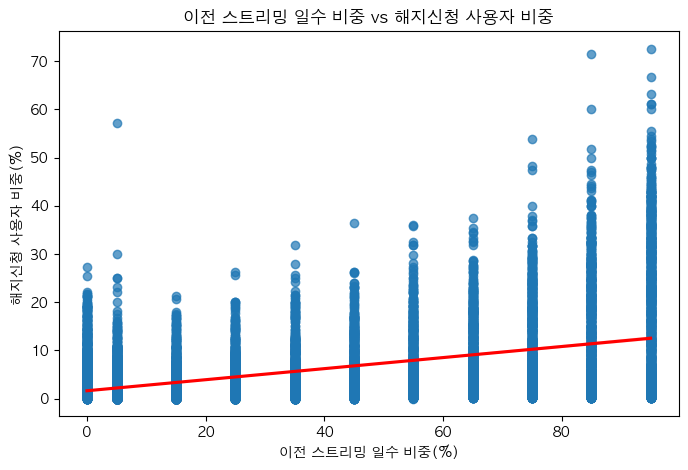

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.regplot(
    data=df,
    x='pre_st_day_ratio_num',
    y='cncl_req_user_ratio',
    scatter_kws={'alpha':0.7},
    line_kws={'color':'red'}    
)
plt.title('이전 스트리밍 일수 비중 vs 해지신청 사용자 비중')
plt.xlabel('이전 스트리밍 일수 비중(%)')
plt.ylabel('해지신청 사용자 비중(%)')
plt.show()

### 6) 해지 예측 모델
- 실제 스트리밍 일수 비중 증감이 해지에 영향을 얼마나 주는지 예측모델을 통해 featuer importance 측정
- 다른 지표들과 같이 모델링했을때 효과가 있는지 비교

In [67]:
out_user_model_query = '''
select *
from(
    select buy_no_partition
        , user_mkey
        , first_buy_no
        , buy_no
        , out_yn
        , at_buy_cnt
        , vip_grade_nm
        , remain_offer_cnt
        , normal_price_yn
        , bill_amt
        , prim_bill_mthd_bill_amt
        , if(auto_bill_staus_code = '1Q0100' or auto_bill_staus_code is null,0,1) as cncl_req_yn
        , st_avail_day_cnt
        , st_day_cnt
        , st_day_ratio
        , lag(st_day_ratio) over(partition by first_buy_no order by buy_date) as pre_st_day_ratio
        , st_day_ratio - lag(st_day_ratio) over(partition by first_buy_no order by buy_date) as diff_st_day_ratio
        , st_cnt
        , st_cnt - lag(st_cnt) over(partition by first_buy_no order by buy_date) as diff_st_cnt
        , daily_avg_st_cnt
        , daily_avg_st_cnt - lag(daily_avg_st_cnt) over(partition by first_buy_no order by buy_date) as diff_daily_avg_st_cnt
        , st_song_cnt
        , st_song_cnt - lag(st_song_cnt) over(partition by first_buy_no order by buy_date) as diff_st_song_cnt
        , exploration_ratio
        , exploration_ratio - lag(exploration_ratio) over(partition by first_buy_no order by buy_date) as diff_exploration_ratio
   from hadoop_kent.melon_sys_temp_production.samuel_prod_use_stat_dtl_tb
   where buy_no_partition between '202501' and '202502'
)
where buy_no_partition = '202502'
'''

cur.execute(out_user_model_query)

results = cur.fetchall()
colnames = [part[0] for part in cur.description]

out_user_model_df = pd.DataFrame(results, columns=colnames)

cur.cancel()
conn.close()
out_user_model_df.head()

,buy_no_partition,user_mkey,first_buy_no,buy_no,out_yn,at_buy_cnt,vip_grade_nm,remain_offer_cnt,normal_price_yn,bill_amt,...,pre_st_day_ratio,diff_st_day_ratio,st_cnt,diff_st_cnt,daily_avg_st_cnt,diff_daily_avg_st_cnt,st_song_cnt,diff_st_song_cnt,exploration_ratio,diff_exploration_ratio
0,202502,6063518,2007022735948031,2025021486071107,N,225,F_MVIP,0,1,10900,...,96.774194,3.225806,922,41.0,32.928571,3.561905,374,144.0,62.834225,5.008138
1,202502,5804035,2007030336208135,2025022087093272,N,226,F_MVIP,0,1,9000,...,0.000000,28.571429,56,56.0,7.000000,7.000000,38,38.0,60.526316,60.526316
2,202502,4507021,2007030436261526,2025021486068912,N,230,F_MVIP,0,1,10900,...,51.612903,-51.612903,0,-224.0,0.000000,-14.000000,0,-16.0,0.000000,-12.500000
3,202502,5326223,2007031536870455,2025022588022560,N,228,F_MVIP,0,1,10900,...,51.612903,-40.898618,21,-170.0,7.000000,-4.937500,21,-23.0,100.000000,90.909091
4,202502,214603,2007040803019546,2025021886718487,N,214,F_MVIP,0,1,10900,...,51.612903,9.101382,394,-16.0,23.176471,-2.448529,127,52.0,33.070866,-6.929134


In [70]:
out_user_model_df.columns

Index(['buy_no_partition', 'user_mkey', 'first_buy_no', 'buy_no', 'out_yn',
       'at_buy_cnt', 'vip_grade_nm', 'remain_offer_cnt', 'normal_price_yn',
       'bill_amt', 'prim_bill_mthd_bill_amt', 'cncl_req_yn',
       'st_avail_day_cnt', 'st_day_cnt', 'st_day_ratio', 'pre_st_day_ratio',
       'diff_st_day_ratio', 'st_cnt', 'diff_st_cnt', 'daily_avg_st_cnt',
       'diff_daily_avg_st_cnt', 'st_song_cnt', 'diff_st_song_cnt',
       'exploration_ratio', 'diff_exploration_ratio'],
      dtype='object')

/var/folders/qw/6lks7c5d14scf7qtctm8m6jh0000gn/T/ipykernel_42891/495642603.py:33: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


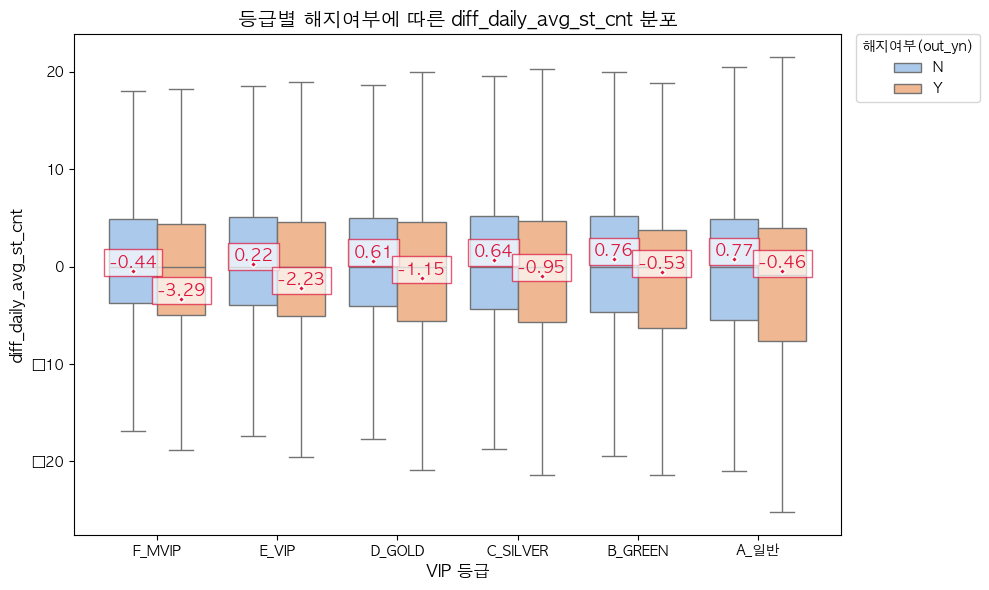

In [166]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
# 파스텔 계열 팔레트 적용
ax = sns.boxplot(
    x='vip_grade_nm',
    y='diff_daily_avg_st_cnt',
    hue='out_yn',
    data=out_user_model_df,
    showfliers=False,
    palette='pastel'
)

# 각 그룹별 평균값 산출 및 표시 (더 진한 색, 테두리, 큰 폰트)
grouped = out_user_model_df.groupby(['vip_grade_nm', 'out_yn'])['diff_daily_avg_st_cnt'].mean().reset_index()
for i, grade in enumerate(sorted(out_user_model_df['vip_grade_nm'].unique())):
    for j, out_yn in enumerate(sorted(out_user_model_df['out_yn'].unique())):
        mean_val = grouped[
            (grouped['vip_grade_nm'] == grade) & (grouped['out_yn'] == out_yn)
        ]['diff_daily_avg_st_cnt']
        if not mean_val.empty:
            # hue 순서에 따라 x좌표 조정 (hue=2개일 때 -0.2, +0.2)
            x_pos = i - 0.2 + 0.4 * j
            ax.scatter(x_pos, mean_val.values[0], color='crimson', marker='D', s=10, edgecolor='white', zorder=10)
            ax.text(x_pos, mean_val.values[0], f"{mean_val.values[0]:.2f}",
                    color='crimson', ha='center', va='bottom', fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='crimson'))

plt.title('등급별 해지여부에 따른 diff_daily_avg_st_cnt 분포', fontsize=14)
plt.xlabel('VIP 등급', fontsize=12)
plt.ylabel('diff_daily_avg_st_cnt', fontsize=12)
plt.legend(title='해지여부(out_yn)', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

t-stat: 12.972, p-value: 0.0000


/var/folders/qw/6lks7c5d14scf7qtctm8m6jh0000gn/T/ipykernel_42891/803654255.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


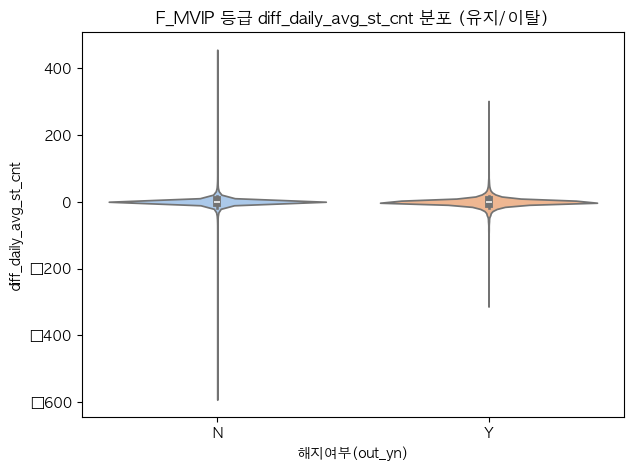

Cohen's d: 0.08


In [99]:
from scipy.stats import ttest_ind

keep = out_user_model_df[(out_user_model_df['vip_grade_nm']=='F_MVIP') & (out_user_model_df['out_yn']=='N')]['diff_daily_avg_st_cnt'].dropna()
out = out_user_model_df[(out_user_model_df['vip_grade_nm']=='F_MVIP') & (out_user_model_df['out_yn']=='Y')]['diff_daily_avg_st_cnt'].dropna()

t_stat, p_val = ttest_ind(keep, out, equal_var=False)
print(f"t-stat: {t_stat:.3f}, p-value: {p_val:.4f}")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.violinplot(
    x='out_yn', y='diff_daily_avg_st_cnt',
    data=out_user_model_df[out_user_model_df['vip_grade_nm']=='F_MVIP'],
    palette='pastel'
)
plt.title('F_MVIP 등급 diff_daily_avg_st_cnt 분포 (유지/이탈)')
plt.xlabel('해지여부(out_yn)')
plt.ylabel('diff_daily_avg_st_cnt')
plt.show()

import numpy as np

mean_diff = keep.mean() - out.mean()
pooled_std = np.sqrt((keep.std()**2 + out.std()**2) / 2)
cohen_d = mean_diff / pooled_std
print(f"Cohen's d: {cohen_d:.2f}")

In [71]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression, RidgeClassifier, Lasso
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 준비
features = [
    'at_buy_cnt', 'remain_offer_cnt', 'normal_price_yn', 'bill_amt', 'prim_bill_mthd_bill_amt', 'cncl_req_yn',
    'st_avail_day_cnt', 'st_day_cnt', 'st_day_ratio', 'pre_st_day_ratio', 'diff_st_day_ratio',
    'st_cnt', 'diff_st_cnt', 'daily_avg_st_cnt', 'diff_daily_avg_st_cnt',
    'st_song_cnt', 'diff_st_song_cnt', 'exploration_ratio', 'diff_exploration_ratio'
]
df = out_user_model_df.copy()
df = df.dropna(subset=features + ['out_yn'])
X = df[features]
y = (df['out_yn'] == 'Y').astype(int)  # 해지=1, 유지=0

# 2. 데이터 분할 및 스케일링
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42, test_size=0.2)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. 모델 학습 및 평가

# (1) Decision Tree
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
print("Decision Tree\n", classification_report(y_test, dt.predict(X_test)))

# (2) Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
print("Logistic Regression\n", classification_report(y_test, lr.predict(X_test_scaled)))

# (3) Ridge Classifier
ridge = RidgeClassifier()
ridge.fit(X_train_scaled, y_train)
print("Ridge Classifier\n", classification_report(y_test, ridge.predict(X_test_scaled)))

# (4) Random Forest (앙상블)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest\n", classification_report(y_test, rf.predict(X_test)))

# (5) Gradient Boosting (앙상블)
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
print("Gradient Boosting\n", classification_report(y_test, gb.predict(X_test)))

# 4. Feature Importance (Random Forest)
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=importances, y=importances.index)
plt.title("Random Forest Feature Importance")
plt.show()

# 5. 다른 Feature Importance 방법
# - Logistic Regression 계수 (절대값)
coef = pd.Series(abs(lr.coef_[0]), index=features).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=coef, y=coef.index)
plt.title("Logistic Regression Feature Importance (abs coef)")
plt.show()

# 6. 딥러닝 모델 (예시: Keras)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import plot_model

model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

# 딥러닝 feature importance는 SHAP, permutation importance 등 활용 가능
# 예시: SHAP
# import shap
# explainer = shap.KernelExplainer(model.predict, X_train_scaled)
# shap_values = explainer.shap_values(X_test_scaled)
# shap.summary_plot(shap_values, X_test, feature_names=features)

# 추천: permutation importance, SHAP, LIME 등도 활용 가능

Decision Tree
               precision    recall  f1-score   support

           0       0.95      1.00      0.97    596766
           1       0.97      0.49      0.65     61666

    accuracy                           0.95    658432
   macro avg       0.96      0.74      0.81    658432
weighted avg       0.95      0.95      0.94    658432

Logistic Regression
               precision    recall  f1-score   support

           0       0.95      1.00      0.97    596766
           1       0.99      0.48      0.65     61666

    accuracy                           0.95    658432
   macro avg       0.97      0.74      0.81    658432
weighted avg       0.95      0.95      0.94    658432

Ridge Classifier
               precision    recall  f1-score   support

           0       0.95      1.00      0.97    596766
           1       1.00      0.46      0.63     61666

    accuracy                           0.95    658432
   macro avg       0.97      0.73      0.80    658432
weighted avg       0

KeyboardInterrupt: 

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

features = [
    'at_buy_cnt', 'remain_offer_cnt', 'normal_price_yn', 'bill_amt', 'prim_bill_mthd_bill_amt', 'cncl_req_yn',
    'st_avail_day_cnt', 'st_day_cnt', 'st_day_ratio', 'pre_st_day_ratio', 'diff_st_day_ratio',
    'st_cnt', 'diff_st_cnt', 'daily_avg_st_cnt', 'diff_daily_avg_st_cnt',
    'st_song_cnt', 'diff_st_song_cnt', 'exploration_ratio', 'diff_exploration_ratio'
]

df = out_user_model_df.copy()
df = df.dropna(subset=features + ['out_yn', 'vip_grade_nm'])

for grade in df['vip_grade_nm'].unique():
    sub = df[df['vip_grade_nm'] == grade]
    X = sub[features]
    y = (sub['out_yn'] == 'Y').astype(int)
    if y.sum() == 0 or y.sum() == len(y):
        print(f"{grade}: 해지/유지 한쪽만 존재, 분석 불가")
        continue
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X, y)
    importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
    plt.figure(figsize=(8,5))
    sns.barplot(x=importances, y=importances.index)
    plt.title(f"[{grade}] Random Forest Feature Importance")
    plt.show()

KeyboardInterrupt: 